## Setup

### Imports

In [ ]:
import os

import polars as pl
from scipy import stats
from matplotlib import pyplot as plt, rcParams
import synapseclient

# set max font size 
rcParams["font.size"] = 7

### Constants

In [17]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITD-WT.arrow": "syn74776638",
    "B_FLT3-ITD-WT.csv": "syn74776648",
    "B_FLT3-ITD-WT_mut-cols.txt": "syn74776635",
    "B_FLT3-ITD-WT_wt-cols.txt": "syn74776634",
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITD-WT.arrow": "syn74776654",
    "W_FLT3-ITD-WT.csv": "syn74776655",
    "W_FLT3-ITD-WT_mut-cols.txt": "syn74776647",
    "W_FLT3-ITD-WT_wt-cols.txt": "syn74776646",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache"
)
# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "volcano"
)
# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

In [3]:
# ensure diffex and figure directories exist
os.makedirs(DIFFEX_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

### Synapse login

In [4]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.12.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.12.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [15]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    print("=" * 20 + f"{subset_id=} {block=}" + "=" * 20)
    # load subset sample columns
    with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:
        wt_cols = wtf.read().split("\n")
    with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:
        mut_cols = mutf.read().split("\n")

    # load subset omics data
    omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # add the ∆z and t-test p-value columns
        .with_columns(
            (
                pl.concat_list(wt_cols)
                .list.drop_nulls()
                .alias("wt")
            ),
            (
                pl.concat_list(mut_cols)
                .list.drop_nulls()
                .alias("mut")
            ),
        )
        .filter(
            (pl.col("wt").list.len() >= 5)
            & (pl.col("mut").list.len() >= 5)
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        )
        .drop(
            "wt",
            "mut"
        )
        # correct p-values for multiple comparisons
        # Benjamini-Hochberg
        .with_columns(
            pl.col("ttest_p")
            .map_batches(
                lambda s: pl.Series(stats.false_discovery_control(s.to_numpy()))
            )
            .alias("ttest_p_adj")
        )
    )

#### Load data for all comparisons

In [18]:
comps = {}
for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    for block in [
        "Acetylomics",
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        comps[(subset_id, block)] = load_data_add_delta_z_and_ttest_p(subset_id, block)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23698/1399119242.py:11: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:



====================subset_id='B_NPM1-WT' block='Acetylomics'====================
[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23698/1399119242.py:13: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23698/1399119242.py:17: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)



...

====================subset_id='W_FLT3-ITDxNPM1-WT' block='Metabolomics'====================
[syn74776653:W_FLT3-ITDxNPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/675/172720675/W_FLT3-ITDxNPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23698/1399119242.py:13: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:



[syn74776650:W_FLT3-ITDxNPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/671/172720671/W_FLT3-ITDxNPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_23698/1399119242.py:17: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  omics_subset = pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)



[syn74776658:W_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/683/172720683/W_FLT3-ITDxNPM1-WT.arrow, skipping download.


## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [19]:
def volcano_plot(
    df: pl.DataFrame, 
    min_abs_delta_z: float, 
    max_p_value: float, 
    adjusted_p: bool,
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # helper: colors
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", p_col).iter_rows()
    ]
    ax.scatter(df["delta_z"], df[p_col], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [20]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    adjusted_p=False,
    label_top_n=10,
    export_top_n=250
) : 
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        adjusted_p=adjusted_p,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    for df, up_or_down in [(top_up, "up"), (top_down, "down")]:
        if len(df) > 0:
            # write just the identified features
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .select("Feature")
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.txt"
                    ),
                    include_header=False
                )
            )
            # write the full table
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.csv"
                    ),
                )
            )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### Make the volcano plots for selected comparisons

============ B_NPM1-WT ============
Transcriptomics


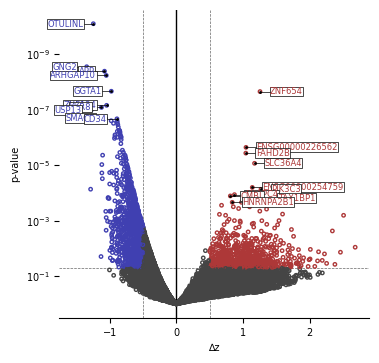

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NDUFAF7""",null,-0.991452,0.157166,-0.39828,-1.577523,null,0.801231,-0.176396,null,0.492625,null,-0.582581,2.307229,0.534452,1.080005,-0.888015,2.362524,-0.82611,-0.641577,-0.456211,-1.135177,0.847847,-0.49372,3.478906,null,0.169659,null,null,null,null,-0.400863,-0.008583,0.212686,-0.162229,-0.813427,null,…,1.376892,-1.540403,null,-0.735934,-0.566203,null,null,null,-0.863286,-1.082135,0.021798,1.004956,-1.060726,0.751889,-1.158407,null,-0.34889,-0.809343,0.450062,-0.311723,null,null,null,null,0.64548,null,null,0.900462,0.448179,1.214005,0.715825,-0.183455,null,null,0.699753,0.013672,0.238555
"""CDC27""",null,-0.338022,-0.614552,0.031607,2.124105,null,-0.326796,-0.977349,null,0.848493,null,-0.865608,0.519405,-0.600539,0.439431,-0.452783,0.499281,-0.555965,-0.479958,-0.992307,-0.5546,0.761849,0.00615,0.918521,null,-0.883708,null,null,null,null,0.102051,2.947986,0.102414,-1.14312,-0.843376,null,…,1.486753,-1.699659,null,-1.080974,-0.987708,null,null,null,-1.158744,-0.797053,0.370174,0.491629,-0.294349,0.001706,-1.668135,null,0.119981,-0.667602,0.207104,-0.265646,null,null,null,null,2.342513,null,null,1.590578,0.5696,0.849817,0.375145,-0.309402,null,null,1.013618,0.04501,0.402064
"""HCCS""",null,-0.772143,-0.725042,1.010386,2.34866,null,-0.564979,-1.196396,null,0.289525,null,-1.484304,2.343301,0.030755,-0.032876,-1.081535,1.446702,-0.932042,-0.624957,-0.689741,-0.922616,0.937524,1.055565,-0.944395,null,2.053895,null,null,null,null,1.487549,0.48571,-0.195521,-1.34371,-1.116575,null,…,0.220414,-2.077954,null,-0.78966,-1.235693,null,null,null,0.093068,-0.402302,0.7226,1.668673,0.389616,0.609229,0.386763,null,-1.306028,-0.424145,0.253205,-0.787658,null,null,null,null,0.715234,null,null,0.943328,-0.2121,0.326452,1.043539,0.223908,null,null,0.568775,0.039324,0.381109
"""LIG3""",null,-0.858955,1.082478,-0.83223,1.49741,null,-0.042283,-0.220525,null,-0.809619,null,0.095043,-0.313443,-0.80052,-0.142034,-0.602785,-0.004272,0.163768,0.528489,-0.568984,-0.856607,-0.780595,-0.760036,4.6196,null,-0.591193,null,null,null,null,0.29377,0.625549,0.457509,-0.510842,0.080536,null,…,-0.408918,-1.145312,null,0.221976,0.378397,null,null,null,-0.438718,-0.656282,-0.252398,-0.608064,-0.340609,0.006535,-1.231182,null,-0.790063,-0.472591,-0.192446,0.250755,null,null,null,null,1.43985,null,null,1.016292,1.510311,3.04187,0.5441,0.306138,null,null,1.470139,0.012205,0.225757
"""CIAPIN1""",null,-1.331903,-0.356113,-0.617588,-3.261082,null,-0.682191,-0.493065,null,0.1086,null,-0.189866,-0.220423,1.218123,1.097111,0.552251,0.944151,-0.551103,-0.392622,0.22191,1.492654,0.576238,0.530052,1.476962,null,1.337851,null,null,null,null,0.023015,-0.110306,-0.762627,1.437077,-0.778789,null,…,0.953077,-2.485786,null,-0.102764,-0.625107,null,null,null,1.4751,0.004367,-0.694318,-0.668446,-0.181383,0.083619,-0.612846,null,-1.09612,0.142106,0.274133,-1.542712,null,null,null,null,1.219109,null,null,0.605661,0.857691,1.013262,0.054221,0.238478,null,null,0.746133,0.0076

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""KLHL13""",null,-0.64954,0.379956,-0.188343,-0.668779,null,0.018899,0.109502,null,1.924571,null,-0.506758,-0.111719,-0.592535,-0.578996,-0.29082,1.790347,-0.02126,0.177387,0.52679,-0.244269,-0.031734,-0.558153,-0.275459,null,-0.216483,null,null,null,null,-0.082339,3.985946,1.054098,0.327145,-0.214218,null,…,-0.284565,-0.662704,null,-0.637722,0.569714,null,null,null,-0.038326,-0.640416,-0.569403,-0.616235,-0.563693,-0.598521,-0.535928,null,-0.504364,-0.653042,1.14192,-0.184069,null,null,null,null,-0.41421,null,null,-0.578531,-0.597618,-0.270831,-0.554052,-0.482023,null,null,-0.542005,0.001247,0.063683
"""CD38""",null,-0.830895,-0.252257,-0.037754,-0.303425,null,-0.761319,0.727811,null,1.053701,null,0.14829,-0.674078,0.035512,-0.560487,0.526957,1.495515,-0.345326,0.844852,0.347989,0.182776,-0.486335,-0.658368,-0.542382,null,3.32825,null,null,null,null,-0.706347,3.34373,-0.857765,0.866552,-0.104443,null,…,-0.873489,-0.821791,null,-0.468579,-0.576041,null,null,null,-0.656721,-0.08748,-0.657872,-0.473148,-0.56563,0.378498,-0.896695,null,-0.793929,-0.849318,1.166878,0.180314,null,null,null,null,-0.903443,null,null,0.143792,-0.744126,-0.809862,-0.103459,-0.319456,null,null,-0.511941,0.042392,0.394385
"""MCUB""",null,1.075373,-0.40303,-0.232042,-0.648507,null,-1.230942,0.498585,null,0.621986,null,-0.635484,0.741006,0.232768,0.033473,-0.932434,2.65925,0.896884,0.174384,2.595694,0.065138,0.317266,-1.113719,-0.982483,null,-0.446565,null,null,null,null,-1.125249,-0.986798,-0.803019,1.891153,-0.063466,null,…,1.405517,-1.270388,null,-0.582573,-0.76616,null,null,null,-0.598469,0.872959,0.115344,-0.867693,1.826864,-0.293962,1.817799,null,0.553454,1.020501,1.24296,-1.136007,null,null,null,null,-0.728918,null,null,-0.479651,-0.828339,-1.366932,-0.596471,-0.499248,null,null,-0.841754,0.00039,0.033726
"""THSD7A""",null,-0.457245,1.769,-0.518364,0.629519,null,-0.511058,-0.241597,null,-0.511033,null,2.983351,-0.516523,0.127556,-0.444405,5.39141,-0.510236,0.319819,0.641092,-0.516406,-0.192151,-0.515345,0.616932,-0.513349,null,0.846195,null,null,null,null,0.410399,-0.508999,-0.506602,1.406929,-0.413719,null,…,-0.47722,-0.517822,null,-0.513929,0.824683,null,null,null,-0.513005,0.102581,-0.466422,0.288129,-0.210775,-0.514184,-0.515518,null,-0.514696,-0.514151,-0.431717,-0.258834,null,null,null,null,-0.399097,null,null,-0.515142,-0.516549,-0.518364,-0.496683,-0.518364,null,null,-0.554527,0.000627,0.044747
"""GCFC2""",null,-1.168314,0.782821,0.157229,4.675775,null,-0.059765,-0.847088,null,1.294381,null,-0.202836,-1.300436,-0.051768,0.615037,-0.098233,1.885541,0.750511,-0.081345,-0.747687,0.092407,0.05468,-0.717767,0.561565,null,-0.930194,null,null,null,null,0.979458,0.686169,0.706462,0.220897,0.42804,null,…,0.106709,-1.195559,null,-0.246419,1.002571,null,null,null,-0.732633,-0.620295,-0.624988,0.122148,-0.813738,-0.587868,-0.700979,null,-0.377075,-1.045749,1.237991,-1.037707,null,null,null,null,-1.212503,null,null,0.278062,-1.148799,-0.7343,-0

Proteomics


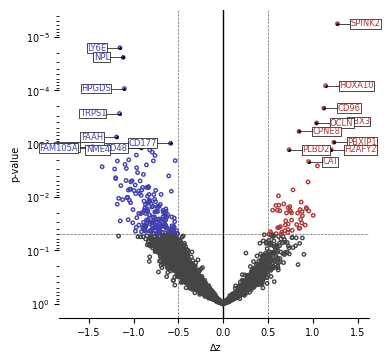

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH5A1""",-1.636885,-1.685539,-0.520642,-0.617834,null,null,null,null,null,null,-1.055934,0.295147,0.027569,0.497498,-0.471951,-0.357757,1.000938,-1.570717,0.914959,-0.403026,-0.267776,-0.934058,0.371211,0.972956,0.272329,-0.710898,-1.198361,0.223153,0.554236,0.073548,0.403825,1.186309,1.537115,1.625774,-0.063956,-0.265909,…,0.388004,-0.509326,2.077739,-0.489341,0.178698,-1.809202,-1.281635,-0.131939,-0.515776,-1.042803,0.079512,0.491136,-1.184134,-0.996292,-0.119448,-0.654951,-1.99034,-1.490546,0.998856,-2.43985,2.218574,-0.243718,-0.074936,0.70023,null,null,-0.069435,-0.540156,1.106514,1.976467,1.13383,-0.340791,1.488114,0.641198,0.694735,0.033394,0.999855
"""ARSA""",0.032506,0.781203,-0.745059,0.524555,null,null,null,null,null,null,0.567754,0.629336,0.062353,1.824556,-1.356563,-0.350023,-1.413901,-2.147134,-2.056281,-0.751503,-0.160018,-0.787671,1.210461,0.650755,0.759602,-0.14174,-0.083161,-1.017337,-0.202118,-0.529639,-1.385965,0.54382,-0.330215,-0.534694,0.032385,1.08745,…,-0.702438,-0.983544,0.43603,-1.117548,-2.274589,0.315208,-0.549148,0.589382,0.206795,0.747261,2.192836,-0.947574,-1.061391,0.690121,0.439093,-0.413738,0.472079,-0.808587,-1.034359,-0.139117,-0.194979,-0.672937,-0.011101,0.862634,null,null,-0.150123,0.553751,0.722815,0.220764,0.705577,1.503662,-0.247767,2.451226,0.762858,0.01973,0.999855
"""ATP8B4""",-0.82754,1.191326,-0.580083,-0.031687,null,null,null,null,null,null,-1.644191,-1.002383,-1.761926,-1.259805,-0.814558,-1.718367,-1.236569,-2.551685,-0.182197,-0.79815,1.03107,-1.070946,-0.310645,-0.272563,0.363773,0.53989,-0.998695,-0.930064,0.424567,-0.500973,-2.171013,0.952665,-0.151611,0.28517,-0.522613,1.499142,…,-2.797841,-1.12422,0.267145,0.11061,-1.140175,0.524447,0.066189,1.911065,0.223933,1.145049,0.606927,0.423116,1.101346,-0.350735,0.449943,0.872374,-0.457761,0.840368,-0.319348,0.141629,1.389604,-1.172613,0.127639,0.69232,null,null,0.279617,0.220311,0.262749,2.144563,1.239107,0.899336,-0.216925,1.107627,0.779578,0.007322,0.999855
"""BAHCC1""",-0.262754,-0.531515,null,0.440557,null,null,null,null,null,null,-1.128795,-1.201001,-2.830161,-1.628183,-1.622899,-1.62877,0.65424,-1.102399,-1.065292,-0.281965,-0.861467,-0.113136,-0.448313,0.17752,-0.529111,-0.102937,-1.560273,-1.013206,-0.106594,-0.207385,0.510036,1.328747,0.090256,-0.141892,0.0858,-2.099997,…,-0.165477,1.395153,1.267892,-0.313169,-0.958267,-0.137041,-0.450997,1.486779,1.285272,1.427608,0.818838,-0.190803,-0.071963,-0.373496,0.706285,1.797683,0.5578,1.378678,1.428042,-0.651474,0.470509,-1.518853,0.415498,null,null,null,-0.002395,0.163885,-0.200666,1.206952,0.522402,0.814861,1.216118,0.22385,0.552633,0.017652,0.999855
"""CAT""",-0.131117,0.131812,-0.973319,1.025617,null,null,null,null,null,null,-2.03785,-1.56646,-0.286758,-1.96826,-1.461018,-0.311323,-0.62125,-2.207095,-1.317326,0.769584,-0.439878,-1.447926,-0.820189,0.486788,-0.323553,-0.593299,-0.963967,-1.32495,0.267318,-0.721893,-0.83708,0.360413,-1.157816,2.009841,-1.3184

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABAT""",0.908251,1.18767,null,null,null,null,null,null,null,null,-1.536492,0.268764,-0.208044,1.560516,0.071137,-1.191214,-1.213074,-0.758474,-1.854291,-0.921256,1.028928,0.7821,-0.452642,-1.310555,0.218175,1.008145,-0.288884,0.141115,-1.032421,1.433645,0.17353,0.052259,-1.295965,3.699362,1.629181,-0.036783,…,0.36033,-0.067336,-1.516726,-0.458912,-0.155553,0.752693,-0.388651,-0.39409,0.694024,1.37565,-0.121348,-0.53583,1.120275,-0.58758,0.849934,-0.157022,-0.529227,-0.503317,0.588029,-0.98903,1.149821,-0.89727,-1.481292,null,null,null,-2.28603,-0.353005,-1.145287,0.079779,0.623472,0.051155,-1.232254,-0.125274,-0.745236,0.048531,0.999855
"""ABCB1""",-0.849585,0.015547,-0.395564,-0.898192,null,null,null,null,null,null,-1.679824,-0.251665,0.193138,0.915544,-0.325995,-1.877693,1.327621,-0.847815,1.530777,-0.304214,-0.370946,-0.109135,-0.789633,-0.247103,0.838534,-0.834072,-0.802034,0.756583,-1.008619,0.152007,0.052055,1.088148,1.975611,0.637032,0.377247,0.325839,…,-0.002425,1.142121,2.15251,-0.873016,1.682252,-0.403075,1.339757,-0.042884,0.085292,0.680726,-0.804107,1.711031,0.135673,-0.828339,0.670911,-0.076736,-0.512542,-0.119378,0.691289,-1.521658,1.756305,0.288305,null,-0.073318,null,null,-1.838972,-0.37782,-3.008472,-0.455561,-0.632119,-0.599097,-1.474883,-0.563545,-1.141471,0.006104,0.999855
"""ALOX12""",null,2.43145,null,null,null,null,null,null,null,null,0.432565,0.416826,0.30262,1.363449,0.23977,0.429405,0.034235,-1.463945,-0.58965,1.546862,0.117842,1.52446,1.416487,-0.925613,-0.874908,-0.784071,-0.74623,0.055452,-2.500077,-0.153398,0.222196,-0.913833,1.070116,0.11177,1.937788,0.171355,…,-0.012345,-1.181325,0.960681,0.156305,2.843787,0.472139,-1.264747,-0.184636,-0.100116,0.447489,0.278213,0.050608,-0.208966,-1.205727,0.435118,0.017107,-0.380598,0.077911,-0.79605,-0.460335,0.219084,-0.915812,null,-0.234821,null,null,-1.828784,-1.177702,-0.967485,-0.942971,-0.976509,-0.083319,-0.581378,0.066208,-0.855914,0.002498,0.648893
"""ALOX5""",0.761181,1.280557,-0.555611,1.421964,null,null,null,null,null,null,0.55159,0.462426,-0.656798,-0.464008,0.227109,-1.372554,-1.365004,0.402498,-2.203394,0.673513,1.30237,0.045252,0.79841,-2.028813,0.653021,0.427148,0.440023,-0.255696,-0.539198,0.850824,-0.42299,-0.484289,-1.18039,-0.021081,1.368059,1.870523,…,-1.520767,0.592453,-1.470272,0.242557,0.401072,1.172974,-0.261982,0.578108,1.520512,0.391173,-0.152606,-0.177279,0.62544,-1.401579,0.849598,1.056506,0.902332,1.419148,-1.288494,-0.379355,-1.146939,-0.833295,-0.499819,0.182759,null,null,-2.411655,0.295928,-1.592178,-0.064295,0.151558,0.245596,-2.190603,-0.822271,-0.773651,0.048666,0.999855
"""ANPEP""",0.630306,0.338042,0.997687,0.387941,null,null,null,null,null,null,-2.325397,-1.232857,-1.352032,-2.03428,0.65666,-2.200388,-0.608131,0.569372,-0.196663,-1.500468,-0.251232,0.220313,-1.039174,-1.525449,0.113158,0.33866,0.464311,0.869011,-0.327172,1.149979,-0.230176,-0.092191,0.011338,0.026219,2.225789,1.862844,…,-1.109672,-0.11734,-0

Phosphoproteomics


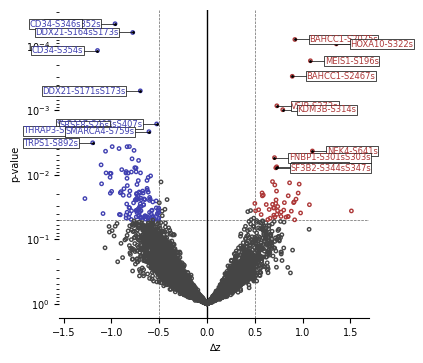

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARID1B-S1542s""",-0.868959,1.159554,0.476302,-1.042698,null,null,null,null,null,null,-1.015762,-1.466849,-2.438259,-1.032799,-1.585168,-1.707226,1.284633,0.203502,1.620326,-0.433527,-1.76411,-0.385366,-1.031319,0.204357,-1.019384,-0.846112,0.047225,-0.107984,-0.995333,-0.025167,0.92514,0.803573,0.727226,-0.170831,1.728356,-0.418099,…,-1.229327,-0.073547,2.283613,0.393908,-0.656827,-0.591228,-0.002776,1.011684,1.278005,0.142829,0.511004,0.417348,0.060325,0.109754,0.080353,0.495814,-0.43597,0.111562,1.687185,-1.941557,-3.018192,-0.567561,0.413854,-0.570316,null,null,1.504189,0.190279,0.312726,0.302233,0.531716,0.511008,1.358507,0.43857,0.576088,0.019141,0.9999
"""ARID1B-S1710sS1715s""",null,-1.57626,0.269483,null,null,null,null,null,null,null,-1.455307,null,-2.802197,-1.005885,-0.370485,-1.321494,0.534297,null,0.660709,-0.595593,-1.671692,-0.432719,0.872924,null,0.55091,-0.31543,-0.137038,null,-0.821548,null,1.36952,0.20874,null,null,null,null,…,null,-0.535301,1.52568,null,-0.076755,-0.952352,-0.308687,null,0.770545,null,0.996993,0.780279,null,-1.239478,0.282259,-0.850094,-0.551376,null,1.208431,-1.730646,null,0.29583,0.232811,1.732515,null,null,1.53489,null,null,0.733762,0.826135,-0.157157,null,null,0.931181,0.023906,0.9999
"""BAHCC1-S2075s""",null,-0.58789,0.11932,0.242958,null,null,null,null,null,null,-1.504016,null,-2.014588,-1.780984,-0.613034,-1.912709,0.61726,-0.803893,-0.613718,-0.189799,-0.887435,-0.970822,-0.124342,-0.13121,-0.96563,0.387523,-1.507917,-1.108506,0.364823,null,1.26166,1.581598,null,0.728934,-0.736349,null,…,null,-0.119811,1.506884,-0.516223,-1.121959,0.112989,-0.114056,1.437317,0.150892,null,0.821911,-0.350268,null,-0.707768,0.014628,0.236822,-0.871159,null,1.375658,-1.322976,1.98492,-0.921086,0.865073,0.437001,null,null,0.640923,0.442551,null,1.158711,0.562104,0.567005,1.746793,0.671337,0.919268,0.00008,0.155535
"""BAHCC1-S2467s""",-1.673905,null,null,0.115639,null,null,null,null,null,null,-0.608553,0.271333,-2.09602,null,-1.711241,-1.216738,0.822056,-0.484808,-0.34288,0.880922,null,-0.892753,0.207428,-0.103979,-0.993905,null,-1.6395,-0.417913,0.461338,-0.612037,null,1.526063,0.702183,0.610008,0.014548,-2.061676,…,-0.168338,0.151275,null,-1.281223,-1.149027,-0.679175,0.163815,0.956333,-0.37828,-0.127769,0.802121,-0.964425,1.0312,-0.936144,0.170895,null,-0.545553,-0.177366,1.773592,-0.549172,-0.326648,null,1.094408,1.136995,null,null,null,0.610634,-0.030686,0.730374,0.97953,null,0.427897,1.265628,0.891936,0.000297,0.309044
"""CTSD-S359s""",-1.34327,-0.680464,-0.282922,-0.60878,null,null,null,null,null,null,-1.166514,-0.535018,null,null,-0.974751,-0.719,-0.309946,-1.529801,0.263434,-0.252181,null,-2.679967,0.022816,1.629379,0.69646,null,-0.716513,-0.071072,0.581823,-0.76419,null,1.47806,-0.857833,-0.329114,-0.133959,1.571915,…,-0.597044,-0.645998,null,-0.45743,-1.079416,-0.263102,-0.460048,1.206874,0.204888,0.109863,0.867143,0.820144,-1.137834,-0.315008,-0.437387,null,-0.284566,-1.20641,-0.108

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AKNA-S997s""",null,0.206186,0.311829,null,null,null,null,null,null,null,null,-1.234736,-2.643,0.776028,null,null,null,-0.37643,-0.110973,null,-1.950341,0.068781,null,0.274946,-1.360975,0.186214,null,-0.325547,null,0.360363,1.484786,0.557275,0.017389,1.416285,1.404402,-0.022988,…,0.733307,null,1.518316,-0.925533,null,null,-0.576778,0.605569,null,1.464341,0.402349,null,1.720882,null,0.223333,1.193532,null,0.442847,null,-1.548755,0.000036,0.544847,-0.346285,-0.783457,null,null,-1.230675,-0.734348,-1.776831,0.197333,-0.069099,-0.695161,0.252818,0.328897,-0.601319,0.038321,0.9999
"""ANK1-S856s""",null,0.07654,null,null,null,null,null,null,null,null,-2.931432,-1.037881,-1.072333,-1.277982,-0.669521,-0.225492,-1.206764,-0.700961,-0.318649,-0.379743,-0.169197,-0.169612,-0.568872,-0.680365,0.018828,-0.335581,-0.766511,0.270514,-0.127725,0.148375,1.503725,2.290998,-0.792573,-0.241906,-0.157678,2.021847,…,-0.807096,-0.370263,0.396823,-0.897426,0.522731,-0.434921,-0.132236,1.766617,0.277416,1.148879,-0.213992,0.018634,0.161662,-0.095997,-0.043778,2.503034,-0.155354,0.434236,0.941317,-1.014191,0.48267,-0.607444,-0.422065,-0.259271,null,null,-1.371527,0.220791,-1.970918,-0.202992,0.159892,-0.482401,-2.009961,0.213411,-0.711295,0.03397,0.9999
"""ANXA2-S26s""",-0.081824,-0.884722,1.860987,-0.577806,null,null,null,null,null,null,-0.420036,-0.857682,-1.484371,-0.171234,-1.092629,-1.514279,-0.860931,0.106896,-0.86644,-1.138894,0.050632,-0.350113,-0.549726,-0.659232,-1.440322,0.009025,-0.367962,0.412424,-1.197959,0.020887,1.529421,-0.258081,-0.909883,0.896671,2.438888,-0.442671,…,0.841811,0.202968,-0.349598,-1.017568,-0.123612,1.781337,-0.044324,1.121914,1.368319,1.708346,-0.193324,1.557757,1.864785,0.245134,1.215203,1.429861,-0.34843,1.573426,1.38133,-1.211554,-0.849517,0.301034,-0.35084,-0.062175,null,null,-2.425815,-0.578941,-1.52029,-0.123047,0.065516,0.508862,-1.264492,-0.347787,-0.703732,0.037782,0.9999
"""ARID4A-S147s""",-1.33144,-0.959047,null,0.173085,null,null,null,null,null,null,-0.426541,-1.173717,null,0.572367,-0.237356,-1.444448,-0.393398,-0.501269,0.587005,1.056436,0.810427,0.805116,0.672004,0.74105,-0.773416,1.520762,-0.38096,0.687472,0.512012,1.964526,1.96802,1.200897,0.972129,0.730527,0.209087,-0.066847,…,1.408006,-0.494647,0.774714,0.133334,-0.991443,0.131595,-0.349909,0.676394,-0.44932,-0.13494,0.515976,-0.122538,0.358405,-1.203856,-0.8122,-0.97095,-0.533879,-2.164895,-0.422599,-1.932578,-3.214115,-0.154581,null,null,null,null,-1.272217,-0.586527,-1.129857,-0.901564,-0.178718,-0.510936,0.354928,-0.228492,-0.627362,0.016271,0.9999
"""ATAD5-S356s""",-1.518198,0.269186,-0.571606,null,null,null,null,null,null,null,null,-1.299127,-1.424508,null,-0.431507,-2.430218,0.83649,0.458639,-0.057294,-0.309408,null,-0.394063,-0.209983,0.433052,-0.948803,null,null,0.426919,null,1.059603,null,1.435663,-0.753003,-0.227173,0.592618,0.252375,…,-0.627036,-0.547463,null,-0.091617,null,0.267991,-0.568251,2.917167,null,0.774259,0.210848,n

Acetylomics


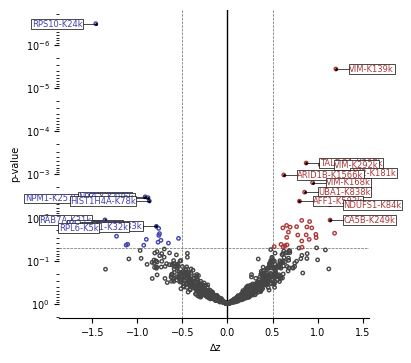

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",null,null,-0.558571,-1.446914,null,null,null,null,null,null,0.366006,0.244718,0.293471,1.422577,-0.079951,-1.91651,-0.886565,-1.047041,0.562909,-0.975941,0.174007,0.46546,0.707448,0.543218,0.318328,0.958388,-0.204386,-0.399425,0.395759,-0.00752,0.092212,-0.706294,0.504962,1.254531,-0.516901,-1.462531,…,0.329567,0.598718,-1.225687,-0.093939,-0.113427,-0.856787,-1.891903,-0.748777,-0.445648,-0.827466,1.615464,0.685283,-0.449116,0.281045,0.328865,-1.000903,-0.926497,-0.089373,1.630105,-2.37135,1.407588,0.704384,-1.446914,1.983679,null,null,0.080571,0.894905,0.975936,0.545286,0.695717,0.315873,1.948119,1.546314,0.873623,0.025421,0.653733
"""AFF1-K582k""",0.370778,null,1.344913,1.269822,null,null,null,null,null,null,-1.226366,-0.622428,null,-0.276548,0.569096,-0.21576,-1.17436,0.585976,-0.406008,0.104296,-0.788378,-0.266133,-0.417087,0.664092,-1.621137,-0.883658,0.532529,-0.253741,-0.384698,0.043109,0.403737,-0.111706,0.46968,0.017484,1.30474,-2.094513,…,0.035064,-1.605444,0.971317,0.157912,0.065308,0.21857,0.549936,0.929233,0.843183,0.665819,0.694846,0.764781,0.922932,0.416489,0.30287,-1.385447,0.180432,-0.01287,1.061572,-0.866482,-2.996234,1.826926,null,null,null,null,0.517194,0.491279,0.798617,0.967516,-0.247408,0.898369,0.532963,1.712071,0.798835,0.004203,0.291291
"""AK2-K181k""",-0.557482,-0.777492,0.564708,null,null,null,null,null,null,null,-0.386948,-0.968084,-3.396061,0.199957,0.096749,-0.175031,-0.396669,-1.117557,0.244363,-0.225252,-0.039226,0.12187,1.133976,1.884882,0.297831,0.925052,-0.157751,-0.381382,0.499187,-0.575541,-0.736357,1.27909,-0.185122,0.120403,-0.273114,-0.288184,…,-0.786493,-0.552273,1.411012,0.881598,0.160986,0.669604,-0.750883,-1.14253,-0.847489,-0.980398,0.705638,0.77122,1.356134,1.35926,1.268824,-1.790954,-0.961531,-1.736324,-0.958142,-1.075589,-1.172594,0.546664,null,2.288813,null,null,0.234252,0.154374,0.932538,1.078301,1.575486,0.248783,1.27096,1.840408,1.219697,0.000948,0.156674
"""ARID1B-K1566k""",null,null,2.741034,0.538009,null,null,null,null,null,null,0.178414,-0.718831,null,null,0.539944,-0.738847,0.080173,0.538825,null,-0.049291,null,null,1.038277,-0.390835,null,null,-0.246043,-0.400144,1.055226,-0.188021,null,null,1.403142,0.08457,0.323999,-0.684583,…,0.365591,-0.926312,null,-0.331379,0.462882,-0.932231,null,2.423499,-0.606213,-1.964566,null,0.243851,-1.690628,-1.059002,null,null,-0.754649,0.24061,0.310901,null,-0.826762,null,0.840802,null,null,null,null,0.453946,0.514087,null,null,null,0.406541,0.584424,0.625072,0.001043,0.156674
"""CA5B-K249k""",null,null,0.333966,null,null,null,null,null,null,null,-0.112636,0.576445,-0.754029,-0.252424,-0.465374,0.218639,-1.242142,-0.174479,-0.277932,-1.730394,-0.281373,-0.913114,1.555721,-0.373882,0.553658,1.09441,-0.678739,-0.312877,0.216482,-0.420225,0.116541,0.229124,-0.330446,-0.477018,0.969148,-2.066543,…,0.731196,-2.149122,0.201688,1.1823,0.062203,-0.325891,0.336685,0.141649,0.392448,-0.15601,2.263548,1.115771,-0.585486

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACOT8-K52k""",null,0.907459,0.255254,null,null,null,null,null,null,null,-0.572861,null,-1.204041,-1.371107,null,null,null,1.58106,-0.577175,null,0.308931,-1.186283,-0.109124,-1.306874,-0.690068,-0.179167,-0.075082,-0.958942,0.124029,-0.385549,-3.420031,-0.26125,null,-0.686884,0.262831,0.726482,…,-1.380388,null,0.560031,-0.821217,1.188158,null,0.423531,0.391681,0.894237,-0.177253,-0.085566,-0.556535,-0.113264,-0.07799,0.677275,1.192764,1.22455,0.86058,null,3.125266,1.171316,-0.917325,null,null,null,null,-0.509972,-1.8311,null,-1.074118,0.242672,-0.578618,-0.083054,-0.889268,-0.762251,0.02612,0.653733
"""ANXA6-K299k""",-0.33181,null,-1.170909,1.519068,null,null,null,null,null,null,-0.56821,1.284269,1.53785,0.337355,1.911232,-0.590139,0.267341,0.492639,0.105828,0.556754,1.659559,1.918436,0.955252,-1.247347,2.380349,1.670231,1.26651,-0.54508,-0.576343,1.411202,-0.385545,-1.446047,-1.790954,-0.709695,2.188123,-0.562815,…,-0.920148,0.803138,-0.16931,-0.167559,0.226226,-0.877721,-0.255052,-0.028102,-0.606498,0.270102,-1.279633,0.20658,0.459504,-0.95132,-0.39313,-0.238034,0.566348,1.102397,-1.144913,-1.850415,-0.19679,-0.48664,null,0.464771,null,null,null,-1.432279,-0.562959,-0.692263,0.082313,-0.23364,-1.630663,-0.657606,-0.65564,0.039341,0.770568
"""BLVRA-K269k""",1.178042,-0.776423,1.394786,3.562225,null,null,null,null,null,null,1.120851,null,0.331827,0.33379,0.351155,0.896968,-0.495853,0.887229,-0.56112,0.362552,0.309786,-0.327075,1.179005,-1.194402,1.944582,-0.680502,0.249302,0.324864,-1.446943,0.319782,-0.899752,-0.0599,0.098598,0.320938,0.466876,0.775078,…,-0.754778,-0.486032,-1.535567,0.202735,1.179819,1.435134,1.275015,-0.866586,-0.789093,-0.64519,-0.61722,-0.695995,0.176838,-0.472287,0.897366,0.964546,-0.575234,0.857048,-1.189865,0.142533,-0.104169,-1.192661,-2.534875,-0.522926,null,null,-2.041233,-0.316211,-2.266113,-1.334435,-0.856759,1.110695,0.579033,0.143237,-0.929577,0.044148,0.779953
"""CANX-K170k""",null,0.61352,null,2.010855,null,null,null,null,null,null,null,null,null,-0.909638,-1.098486,-0.092816,-0.330105,0.304551,null,0.808617,0.768438,null,-0.573383,-0.913009,null,0.728913,null,-0.516109,null,-1.239436,-0.310983,null,0.311151,-0.958305,0.240408,0.449167,…,0.751996,-0.248067,0.407882,0.27762,null,-0.341393,null,2.713797,null,-0.618843,null,null,-0.149003,0.859034,null,-0.43838,null,-0.733098,-1.697754,null,-1.034335,-1.553452,null,-1.633463,null,null,-0.348627,-0.468691,0.556063,null,null,-0.589943,-1.524533,-0.597694,-0.77049,0.037447,0.74978
"""HIST1H4A-K78k""",null,-1.260672,null,null,null,null,null,null,null,null,0.105123,-0.624438,null,2.784274,-0.049631,-2.270404,0.227094,null,null,0.232347,null,null,0.536755,0.549662,null,null,1.085493,-1.259423,-0.330654,0.182156,-0.664696,null,1.147353,0.418978,0.517366,0.671055,…,0.52906,0.222058,0.083652,1.574015,-0.240453,-0.125351,null,-0.590864,0.771211,-0.310973,null,2.261559,1.291026,-1.233973,null,null,-1.256553,-1.730192,0.206048,null,1.643496,1.156

Lipidomics


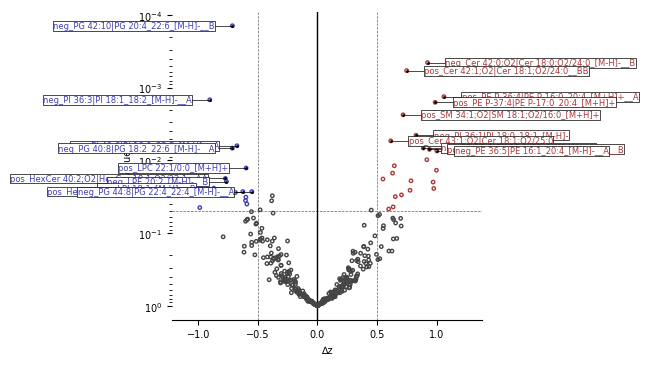

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.18435,null,0.852677,null,-2.468666,-1.980475,-0.90299,-0.459218,-0.874813,0.323036,-0.073667,0.852171,-0.815738,1.202509,-0.364585,-1.142606,-0.890606,-0.799543,-0.46435,-0.265044,-1.114378,-1.288024,0.074244,-0.059613,1.402354,0.446002,-0.516637,-0.956535,-0.839891,-0.528721,0.854735,0.279864,-0.387571,-0.322311,0.04359,0.0595,…,1.103042,0.112821,0.596856,-0.612459,-1.389322,-0.278186,1.210277,-1.359954,0.924322,-1.08676,2.478824,0.512053,0.188655,0.302156,0.245364,-1.0144,0.000409,-1.475517,0.481712,0.032386,2.25479,null,null,null,-0.887282,0.798565,1.858192,-0.635687,1.508183,1.271814,0.349975,0.427862,0.784573,1.298375,0.777083,0.025741,0.31623
"""neg_PG 34:1|PG 16:0_18:1_[M-H]…",-0.187739,null,0.050242,null,-1.819144,-3.05387,-0.912789,0.623155,-0.83366,0.893929,-1.106345,-0.399988,-0.79824,0.060949,0.416028,-0.26987,1.819228,-0.08059,0.648336,0.210139,-0.096195,-0.78182,0.276939,1.131143,-1.318946,0.058516,-0.384283,-0.271766,-0.345697,-0.298216,0.490249,0.811857,0.0232,-0.115382,-0.328059,-2.055953,…,0.721722,-0.698045,1.388893,0.66785,-2.253895,0.130198,-1.575813,0.022791,0.416943,-0.945085,-0.231697,0.63961,0.261862,2.045512,-0.29049,-0.031893,-0.281114,-0.473914,0.59292,-0.817331,1.596201,null,null,null,-0.849663,1.393401,2.009224,0.403648,-0.05107,-0.161836,1.056758,1.453125,2.392807,1.059018,0.998562,0.013647,0.260052
"""neg_PE 36:5|PE 16:1_20:4_[M-H]…",-1.702495,null,-0.51313,null,1.599926,0.745456,0.63223,1.80622,1.717921,1.583855,-1.436696,0.81537,-0.294098,-0.613113,-0.077921,0.978469,-0.609248,0.500334,0.738179,-0.104674,0.366812,-0.412246,0.179018,0.964931,-0.333065,0.557087,-0.300976,0.672258,1.960123,-0.730473,-0.038119,1.98644,0.825583,0.907777,-0.88732,-1.592258,…,0.196595,-0.435159,-1.624861,0.202881,-1.454633,-1.437103,-0.501322,0.254172,-1.956822,-1.040536,-1.300072,0.013157,0.329224,-0.123096,-0.745103,-0.159885,-1.842501,-0.816732,-1.160815,-0.76651,-0.268898,null,null,null,1.569649,0.671835,0.548935,0.127679,1.195339,1.451339,1.403485,-0.45927,2.47954,-0.256666,1.001596,0.007405,0.181416
"""neg_PI 38:3|PI 18:0_20:3_[M-H]…",-0.042631,null,0.540329,null,-0.939721,-1.505726,0.713462,1.37226,-1.62888,2.187071,-0.848309,0.377104,-0.47445,-0.422751,-1.023594,-0.642314,-0.218642,0.252588,1.834913,-0.295508,-0.721621,-0.427381,0.631919,0.286996,-0.918877,-0.863445,0.93951,0.251182,0.717813,0.061175,-0.025792,1.283179,1.101532,0.714568,0.6409,-0.650697,…,-0.640652,-0.212128,1.428308,-0.535864,-1.341177,-0.197767,1.024189,0.236703,0.170339,-1.072263,2.078754,0.586053,-0.351079,0.599148,0.022823,-1.938687,-1.800841,-1.6168,-0.383615,-1.973951,-0.673483,null,null,null,0.230399,2.46773,2.828171,0.79733,0.314964,1.082635,0.723882,0.054321,0.647602,-0.688208,0.970277,0.019869,0.283961
"""neg_PI 36:1|PI 18:0_18:1_[M-H]…",-0.092944,null,1.025883,null,-2.758405,-0.531446,-0.26754,0.377088,-1.111072,-0.975627,0.900877,-0.038665,1.069213,-1.093574,-0.125252,0.549391,1.873

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 18:1_[M-H]-__B""",-0.192176,null,-0.679443,null,null,null,-1.9456,-1.096782,null,null,0.856665,-0.808455,-0.707475,-1.430288,-2.889455,1.172899,-1.363523,-0.846031,-0.232566,-1.395245,0.399035,-0.234046,0.042062,0.137127,0.488433,0.467383,-1.364006,1.07489,0.578572,0.17519,-0.665203,0.494587,0.155608,-0.751223,-0.779181,0.832775,…,0.832828,1.959945,1.072255,-0.458636,0.178202,-0.646816,0.289428,1.064493,1.049533,0.364768,0.191905,0.787427,-1.62434,-1.297221,0.309149,1.070416,2.010791,0.351884,1.616026,0.500546,0.469841,null,null,null,null,-2.863016,-0.574443,-0.671826,-0.582348,0.305228,0.102668,-1.16893,-1.085664,-0.328055,-0.870219,0.02412,0.31623
"""neg_LPE 20:2_[M-H]-__B""",0.149748,null,-0.618175,null,-1.256569,1.70372,-1.01578,0.331478,0.521106,-0.741867,-0.423374,-0.554895,1.653012,-0.074595,-0.666409,0.602429,0.178388,-0.126344,0.552815,-0.328857,-0.265861,-0.358219,-1.371938,-0.209975,-0.773876,0.787041,-0.471227,-0.936926,-0.530202,0.348069,-0.245326,1.598047,0.239504,-0.600951,-1.262712,-0.574292,…,-1.245616,0.56514,0.360629,1.131789,1.755441,-0.307985,0.646669,-0.635749,0.222452,1.119198,-0.763462,-1.300445,-0.862817,-1.285094,-0.543449,-0.020171,1.018323,0.709875,3.793831,-0.199767,0.884547,null,null,null,0.878495,-1.930045,-1.054398,-0.387597,-0.04625,-0.666851,-1.686385,-0.16519,-0.491049,-1.108334,-0.763666,0.019509,0.283961
"""neg_PG 42:10|PG 20:4_22:6_[M-H…",0.347396,null,0.749373,null,0.512516,0.171182,-0.508622,0.030227,0.215251,-0.113265,2.378351,0.584806,null,1.587046,-0.125514,0.127634,-1.517862,1.413877,-1.734428,0.999647,0.891677,2.258667,1.458434,0.329331,2.423573,1.184204,0.197438,1.410817,0.475015,0.437931,1.056838,-0.035828,-1.01379,-1.253043,-0.118926,-0.437401,…,-1.598975,-0.435748,-1.159376,-1.196571,0.037028,-0.530015,-0.987321,-0.269791,-0.065467,-1.740659,-0.659661,0.824577,-0.593259,-1.364343,0.975402,-0.12695,0.560102,-1.803746,-0.596681,0.239507,-0.899428,null,null,null,-0.622988,-0.155464,-0.651791,-1.083093,-0.414178,-0.598413,-0.375554,-1.327171,-0.639646,-0.33922,-0.713401,0.00014,0.048112
"""neg_PG 40:8|PG 18:2_22:6_[M-H]…",0.674639,null,1.485179,null,-0.205839,-1.610096,-2.253761,0.345164,-0.441882,0.357441,1.907526,1.165508,null,1.245419,-0.653333,1.000217,-0.526787,0.496068,-1.547836,0.668242,1.34418,0.769587,0.946994,0.942137,0.418195,1.493066,0.214527,0.844432,0.218116,0.482469,2.113315,0.770184,-1.668108,0.842629,-0.386468,-0.11268,…,-1.685259,-1.734981,0.037512,-0.237844,1.178024,0.26557,-1.375861,0.562966,-0.716655,-0.615687,-0.998913,1.526568,-0.129734,-0.621713,0.332903,0.296087,0.793129,-2.245335,0.652585,0.698017,-1.487843,null,null,null,-1.386625,-0.384525,-0.598371,0.408415,-0.317421,-1.709052,-0.943006,-0.040918,-0.767048,-0.474804,-0.714072,0.006786,0.181416
"""neg_PI 36:4|PI 18:2_18:2_[M-H]…",-1.248855,null,0.362043,null,-1.479671,-0.78242,0.7346,-0.578647,0.315918,-0.840731,1.184269,0.511013,-0.322395,-0.378252,0.424764,0.699567,0.079483,0.125722,

Metabolomics


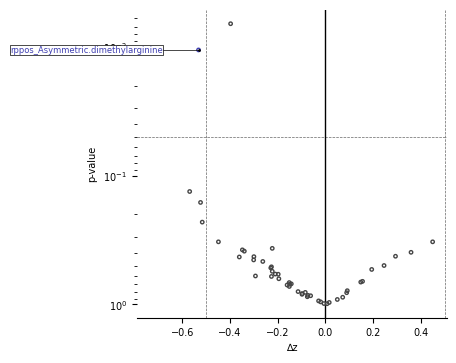

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Asymmetric.dimethylargin…",-0.748212,null,2.329708,null,-1.070975,0.439137,-1.487901,-0.447447,-0.452977,0.566629,0.616603,0.768408,1.336114,-0.458948,-0.580273,0.26682,-0.597199,1.482295,0.493616,0.582129,-0.000548,-1.3204,1.816296,-0.766258,-0.321119,-0.822305,1.701702,-0.084615,-0.052229,0.302268,-0.235249,1.484934,-2.098618,1.931128,0.42029,-1.74585,…,1.179569,1.383112,0.994241,-0.136369,-0.141225,0.54685,-2.180024,0.089168,1.037896,-0.162531,0.721014,-0.367629,-0.188123,-2.198667,-1.645721,-0.253575,-1.098217,-0.225697,1.419581,-1.310104,0.31882,null,null,null,-0.825228,-0.821697,-0.607922,-0.030656,-0.54919,-0.642668,-1.070979,0.382523,-0.563206,0.087988,-0.532354,0.010581,0.259236


============ W_NPM1-WT ============
Transcriptomics


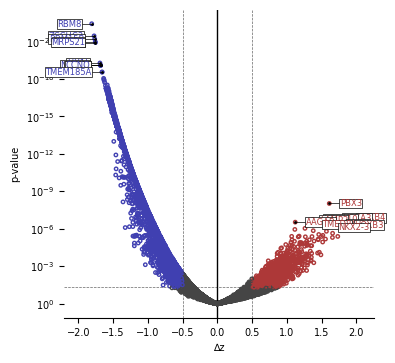

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FUCA2""",null,0.180284,-0.817958,0.034953,-0.997174,null,-1.567578,-0.536698,null,-1.919794,null,-0.859515,-1.604976,-1.438382,-1.188414,-0.90544,-1.270035,1.468242,0.131208,0.760565,1.122559,-0.440666,-0.817543,-1.228599,null,0.15472,null,null,null,null,-0.077669,0.002426,-0.828852,0.257408,0.857923,null,…,2.1995,0.689811,1.117932,null,2.036833,0.664689,-1.136358,-0.674324,null,null,null,1.439312,0.837735,0.53029,-0.093315,-0.095185,0.791237,-1.433533,0.213838,0.596786,null,null,-0.51674,null,-0.288466,null,0.390307,0.36684,0.761476,0.226422,1.117277,-0.101116,2.674269,0.123246,0.550769,0.029213,0.113372
"""NIPAL3""",null,-1.447297,0.211195,0.282378,0.179771,null,-1.249505,-0.234893,null,0.113899,null,-0.850812,-0.592203,0.215034,-0.628414,-1.239125,4.02221,-1.243914,-0.409089,-0.679428,-1.23259,-0.025143,-0.95002,0.295042,null,-0.528005,null,null,null,null,-1.278101,1.461899,1.30945,0.010991,0.224389,null,…,-0.405363,0.459614,-0.400912,null,-1.342146,-0.551223,1.129322,-0.574436,null,null,null,0.57587,1.699825,0.742911,-0.413555,0.950144,1.741471,1.596539,1.011165,1.359914,null,null,2.009734,null,-1.157223,null,0.661331,0.988564,-0.103684,-0.633487,-0.793574,0.573898,0.373845,0.646562,0.864078,0.001335,0.011604
"""M6PR""",null,-1.55391,0.199858,0.628933,-1.407786,null,-1.537208,0.488863,null,-1.180422,null,-0.680432,-0.849507,1.459105,0.203321,-0.95832,-0.938274,0.487332,0.084032,-0.877971,-1.50184,0.15149,-1.43212,-0.406775,null,-0.247423,null,null,null,null,-0.115979,0.444421,0.025973,0.518465,1.337762,null,…,0.442591,-0.436447,1.347525,null,-0.774638,0.508963,0.772281,-1.108987,null,null,null,1.641128,1.384607,2.286374,-0.384837,0.981156,1.004931,1.118918,0.743359,1.672461,null,null,0.79482,null,-0.715148,null,0.000553,-0.02389,-0.790906,-1.431878,-0.67168,-0.820229,1.109472,0.822588,0.637038,0.026928,0.107717
"""NDUFAF7""",null,-1.067132,0.081403,-0.474003,-1.653161,null,0.725422,-0.252135,null,0.416838,null,-0.65829,2.231311,0.458662,1.004175,-0.963703,2.286602,-0.901802,-0.717282,-0.531929,-1.210847,0.772034,-0.569436,3.402904,null,0.093895,null,null,null,null,-0.476586,-0.084334,0.136919,-0.237969,-0.88912,null,…,-1.136401,0.676083,-1.234075,null,-0.424617,-0.885036,0.374278,-0.387452,null,null,null,-0.695468,0.535202,1.198031,0.365327,0.754785,1.12584,1.878498,0.187222,0.715734,null,null,1.53072,null,-0.816328,null,-1.038065,0.574683,-0.970102,0.358203,-0.18585,0.097206,0.654872,1.18155,0.544296,0.030478,0.116498
"""AK2""",null,-1.443234,-0.594795,0.357133,-1.287668,null,-1.205382,-0.301187,null,-0.127849,null,-1.338312,-0.695841,0.692067,-1.208848,-1.027356,0.258679,-0.602331,-0.437225,0.513911,-0.706308,-0.718162,-1.588656,-0.022241,null,0.677354,null,null,null,null,-0.164627,-0.293373,-0.262274,-0.332692,-0.461825,null,…,0.870017,0.6364,-0.665929,null,-0.773977,-0.467624,1.504105,-0.820401,null,null,null,1.00881,1.604628,2.173453,0.15698,1.21175,1.478748,1.559959,1.283694,1.166426,null,null,0.962542,null,-0.96456,null,0.

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""THSD7A""",null,-0.39513,2.024397,-0.461555,0.785986,null,-0.453615,-0.160759,null,-0.453588,null,3.344178,-0.459554,0.240443,-0.381176,5.961303,-0.452721,0.449398,0.798565,-0.459427,-0.107021,-0.458274,0.772307,-0.456105,null,1.021474,null,null,null,null,0.547843,-0.451377,-0.448772,1.630892,-0.347825,null,…,-0.127261,-0.457012,-0.458463,null,-0.457568,-0.456976,-0.367385,-0.179493,null,null,null,-0.456979,-0.460862,-0.46067,-0.457193,-0.460896,-0.461555,-0.440635,-0.457131,-0.456685,null,null,-0.457077,null,-0.421181,null,-0.455898,-0.369251,-0.461555,-0.457728,-0.461555,-0.235284,-0.46107,-0.317183,-0.599685,0.000638,0.006284
"""MPO""",null,-0.627055,-0.007249,0.211136,-0.4622,null,-0.578643,0.419386,null,-0.62549,null,1.14321,-0.752255,-0.350185,-0.643401,5.400485,-0.615757,0.390165,0.330562,0.597258,0.217007,-0.372855,-0.268569,-0.691591,null,1.505886,null,null,null,null,-0.559718,1.191277,-0.716599,-0.752917,1.207773,null,…,-0.674554,-0.722201,-0.724044,null,-0.237081,-0.753638,-0.701705,1.774385,null,null,null,-0.715476,-0.632621,-0.722536,-0.448162,-0.664624,-0.663161,0.113184,0.029769,-0.394558,null,null,-0.400111,null,0.275043,null,-0.550584,0.235412,-0.647677,-0.390222,-0.700614,-0.73953,-0.738063,0.179038,-0.553312,0.003461,0.024602
"""TMEM132A""",null,-0.721899,1.532552,-0.507465,-0.721899,null,-0.549432,-0.598621,null,-0.598293,null,0.090785,-0.504575,-0.614818,0.296576,-0.565774,-0.562004,1.826462,-0.578141,-0.606363,-0.47348,-0.009302,-0.333474,-0.42597,null,-0.355419,null,null,null,null,-0.437889,-0.563992,-0.325225,-0.604028,0.249599,null,…,1.639517,0.100383,2.748564,null,1.87588,2.427631,-0.44548,-0.211332,null,null,null,-0.324297,-0.646613,-0.721899,-0.721899,-0.435705,-0.650629,-0.721899,-0.337508,-0.325199,null,null,-0.154564,null,-0.666394,null,-0.721899,1.535952,-0.372093,-0.721899,-0.64812,-0.721899,-0.721899,-0.400261,-0.619284,0.002471,0.018951
"""TTC22""",null,-0.205966,-0.513882,0.611242,3.496612,null,-0.034016,-0.16986,null,-0.439295,null,0.218932,-0.532222,0.739195,0.08278,-0.352469,-0.345392,-0.645543,-0.285731,-0.585298,0.390735,0.382476,0.407657,-0.306065,null,-0.244242,null,null,null,null,-0.527069,-0.629075,1.133281,-0.350525,-0.486334,null,…,-0.276145,3.281962,0.358505,null,-0.058561,-0.420811,-0.097831,2.362829,null,null,null,-0.583346,-0.103793,-0.435118,-0.480847,0.055847,-0.021204,-0.591385,-0.555347,-0.293892,null,null,-0.349715,null,-0.39664,null,-0.549443,-0.476009,-0.25034,-0.479392,-0.537823,-0.514375,-0.519222,-0.578458,-0.559521,0.001725,0.014313
"""TBXA2R""",null,0.017522,0.915831,-0.586303,-0.671779,null,0.233393,-0.434269,null,-0.671779,null,0.656393,-0.281954,2.365892,-0.517122,1.423412,0.231149,1.559004,-0.471216,-0.334049,-0.044635,-0.158914,-0.491144,5.835719,null,-0.282225,null,null,null,null,2.903759,-0.231173,0.922583,0.73776,0.287124,null,…,-0.661974,-0.595299,-0.024722,null,-0.527959,-0.440514,0.081142,-0.078187,null,null,null,-0.671779,0.368573,-0.505813,-0.367517,-0.339045,

Proteomics


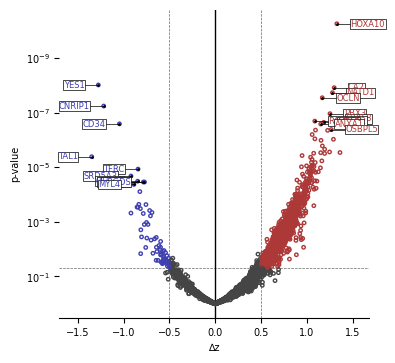

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AACS""",-0.115917,0.708366,-0.117003,0.086242,null,null,null,null,null,null,-2.160972,-2.049098,0.420987,-0.08873,-1.313238,-1.939276,-1.057427,-0.584456,-1.906274,-0.682759,-1.201439,0.354289,-0.835226,0.348831,0.445567,0.487166,-0.292648,-0.335979,-0.896534,-0.038963,-0.432051,-1.035434,-1.203951,-2.846979,0.022058,-0.217027,…,0.859283,0.367879,0.731933,1.499221,-0.254574,0.669372,-0.508191,-0.465008,1.202194,-2.03309,-0.392371,2.211042,1.252195,1.544204,-0.244762,0.971871,0.152272,0.032144,0.950945,1.85518,0.343594,0.321381,-1.18873,1.924192,-1.381156,-0.10162,1.01463,1.55857,0.240986,1.376036,1.248257,0.562235,1.605265,0.165416,0.914063,0.000221,0.011434
"""AAK1""",-0.318538,0.74783,-0.130809,-0.167792,null,null,null,null,null,null,-1.60213,-1.904955,-1.931827,-0.842126,-0.497268,-2.188973,-1.347873,-1.26832,-1.2308,-0.229441,-0.970278,-0.490707,-0.82044,0.972685,-0.07407,-1.181542,-0.014018,-0.286022,-0.782301,0.369473,-0.453974,-0.24335,-0.906397,-0.70096,-0.278485,-0.032745,…,1.994238,0.371809,0.340699,1.612818,0.353762,0.532016,1.264507,-1.243056,-0.464205,-1.244858,0.007802,2.304674,1.07333,2.057744,-0.342817,1.253302,0.171008,0.604681,0.422376,1.320688,-0.047405,0.822858,-1.3399,1.75982,-1.717422,-1.176648,0.858638,1.631268,-0.049788,2.364561,1.468863,1.000918,1.483054,-0.252495,0.894513,0.00115,0.026265
"""AAMDC""",-0.28393,-0.793259,0.704721,-0.135892,null,null,null,null,null,null,-1.113877,-2.013889,-1.421677,-0.111762,-1.205229,-1.688953,-1.428101,-0.46879,-1.710116,0.258402,-1.787668,-0.133171,-0.463529,0.593701,0.494113,0.580137,-1.615125,-0.735986,-0.226001,-0.382064,0.311887,-0.049266,-0.823247,-2.497727,0.807084,-0.6883,…,1.305163,0.01427,0.539337,1.751743,-0.901117,0.567792,0.015594,-0.938559,1.12704,-1.731882,0.846257,0.985559,1.299771,1.677151,1.712338,-0.273167,-0.190054,0.522576,1.299949,0.724698,0.315633,1.159556,0.070437,0.743189,-1.611451,-1.725813,1.084497,1.706625,0.027365,0.292747,0.933953,1.241735,0.881033,-0.076511,0.77864,0.000985,0.02442
"""AAMP""",-0.7049,-1.100476,0.985355,-0.742452,null,null,null,null,null,null,-2.33096,-2.221475,0.808983,-1.267381,-1.004456,-1.944584,-1.291347,-0.390853,-1.728755,0.721852,-0.806928,-0.521839,-0.250138,1.004121,-0.983712,-0.689714,-0.053171,-0.04568,-0.532982,0.548132,-0.028161,0.896915,-0.21978,-1.728429,0.288011,-0.512112,…,1.634589,-0.434972,0.667882,1.558655,0.127957,0.463001,0.511935,-1.923101,-0.00611,-1.432491,0.328692,1.768308,1.36479,1.065878,0.31875,0.024932,-0.025218,0.80407,0.971718,1.02183,-0.990028,0.455912,-0.538727,1.692021,-2.085987,-1.653846,1.338146,1.455286,0.240878,0.106966,0.866369,0.262054,0.41841,0.00112,0.525575,0.029766,0.129933
"""ABCD4""",-1.303768,null,-0.100442,-1.129821,null,null,null,null,null,null,-1.848828,-1.512669,-0.683225,-1.129266,null,null,null,-1.565912,-0.656645,null,-2.078394,0.14577,null,-0.806232,-0.805418,-0.654234,-0.527338,-0.034552,-1.248315,-0.010867,0.528657,0.51595,-1.060462,0.771969,0.164795,-0.323434,…,0.470397

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",-0.844435,0.08843,-0.354868,-0.896848,null,null,null,null,null,null,-1.739674,-0.199703,0.279924,1.058888,-0.279852,-1.953034,1.503226,-0.842526,1.722288,-0.256366,-0.328322,-0.046014,-0.779789,-0.194784,0.975849,-0.827708,-0.793161,0.887481,-1.015919,0.235572,0.127795,1.245005,2.201948,0.758571,0.478447,0.423015,…,0.21796,-0.821525,0.795102,-0.011079,-0.481004,-0.057059,0.817076,-1.569125,1.965473,0.382542,-1.046159,0.432891,-0.019435,-0.238372,-0.699338,-0.967592,-0.699605,-0.731688,-0.333273,-0.446215,-1.303761,-1.263687,-1.710787,0.328964,-2.196013,-1.253735,null,-0.381168,0.219175,-0.322238,0.37051,-0.780509,-0.90236,-0.444096,-0.846948,0.000032,0.003883
"""ANK1""",-1.174583,0.353382,-1.919548,-0.799418,null,null,null,null,null,null,-2.38611,-0.765206,2.335776,-1.046974,1.176571,0.011245,-0.079981,-0.125334,-1.072073,-0.944974,0.670274,-0.290961,-0.226376,-0.574167,1.392602,-0.540636,-0.666118,1.107542,0.859232,0.06911,1.008422,1.547533,-0.982402,-0.737594,-0.312074,1.419465,…,-0.242488,-0.324976,-0.797734,1.124837,-0.032605,1.847049,-0.606377,1.417733,0.164453,-1.936063,-1.235782,0.33417,0.417798,0.009556,-1.053073,0.014633,-1.412405,-1.141066,-0.49684,-0.542589,0.102997,-0.935191,-0.621984,-0.123327,-0.826108,-1.691112,-0.437993,-0.552492,-0.084174,0.994169,0.100729,-0.939759,-0.777578,-1.213836,-0.690963,0.000452,0.015848
"""APP""",-0.370142,1.526053,-0.570788,0.450891,null,null,null,null,null,null,-2.037314,-0.098753,-0.03921,0.236568,-0.303678,-0.232076,1.715923,0.871294,-0.432542,2.287567,-0.289227,1.080135,0.166308,0.208101,-0.175397,0.04108,0.072141,0.640529,-2.416889,1.058152,0.537267,-0.31418,0.770101,0.816978,1.235099,1.222132,…,-0.895767,-2.267733,1.146552,-0.867322,0.204871,-0.511296,1.014611,0.055292,-0.657158,-0.586215,-0.833553,0.622715,0.598088,0.610138,-1.234882,-1.407975,-1.567941,-2.045137,-0.438474,-0.825876,-1.052928,-1.289054,-1.612238,0.092792,-0.373141,-0.996235,0.356517,0.273208,0.431454,0.46584,0.550757,-1.21683,-0.864582,-1.396259,-0.75043,0.001052,0.025165
"""ASS1""",-1.641003,0.916556,-0.096762,-0.126154,null,null,null,null,null,null,-1.583735,-0.194098,-0.557567,0.012641,-0.577554,2.478013,0.968861,-1.140636,-0.95494,-0.205409,0.129564,-0.141128,0.837202,-0.73374,0.64963,-0.298714,-0.589422,0.998885,-0.142361,0.803589,2.739958,0.776415,-0.508684,0.457125,0.09993,0.048936,…,0.143216,-0.926828,0.037956,0.506079,0.98224,-0.143324,0.061523,0.514049,1.280199,-0.048435,-0.646404,-0.077353,0.833184,0.182182,-0.607738,-0.38115,-1.107557,-1.503888,-0.760569,-0.150435,-0.782772,-0.282292,-2.299914,2.036667,-2.248707,-2.085579,0.240575,-1.155029,-0.03598,-0.474305,0.796137,-0.333352,-0.535814,-0.904945,-0.700877,0.004662,0.050907
"""BCAT1""",-0.891931,-0.311376,0.13114,0.568746,null,null,null,null,null,null,-1.612136,-1.540993,-1.383174,-0.734007,-0.570704,-0.374478,-0.226318,1.411381,-0.402563,0.87146,-0.176987,0.025148,0.52149,-0.972638,0.808441,-1.068452,0.70827,1.056853,-1.310615,1.405113,1.26779

Phosphoproteomics


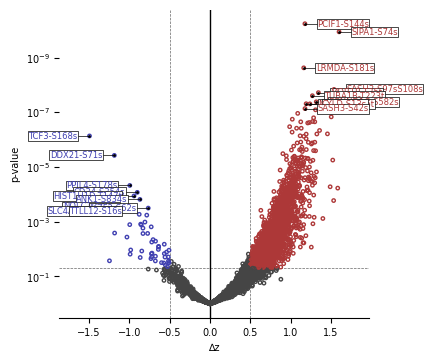

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",-0.243537,0.833556,-0.768972,null,null,null,null,null,null,null,-1.599733,null,-2.606507,-0.632284,-0.796575,-1.323066,-1.156489,null,-0.533798,-0.617895,-1.150407,-1.199663,-0.61009,null,-0.305596,-0.11195,-1.070687,null,-0.436663,null,-0.328334,0.018969,null,null,null,null,…,null,0.423019,1.104721,2.266013,0.241517,null,2.180104,-0.934358,null,-1.392919,-0.326609,2.664431,0.64576,1.306858,-0.622664,0.297314,0.398244,0.710259,0.311591,1.255836,-0.154571,0.661597,-0.885102,0.621091,-2.040903,-0.573466,0.082795,0.585682,-0.304028,-0.169692,0.870238,1.400736,1.537379,null,0.547704,0.034613,0.102767
"""AAK1-S637s""",0.057464,-0.024228,0.185716,-2.093757,null,null,null,null,null,null,-1.873266,-1.040904,-2.069591,-0.133673,-1.168898,-0.320613,null,-0.634525,-0.801228,-1.122109,-1.62258,-0.364644,-0.749034,0.193668,-1.022973,-1.201866,0.401556,-0.585514,-0.742927,-0.343609,-0.228869,-0.066276,-1.03808,0.337751,0.280057,-0.218713,…,1.698517,0.526731,-0.009548,1.554959,0.394712,0.322749,-0.361496,-0.89029,-0.721096,-0.994052,0.091812,2.432745,0.352919,1.043448,0.306416,1.069575,0.198951,0.569757,-0.000455,1.663413,1.327523,1.008929,-2.044611,1.806254,-2.334927,-0.275171,1.136695,1.483069,-0.67396,-0.338157,1.16589,1.590891,1.50501,-0.329521,0.734005,0.00804,0.042803
"""AAK1-S678s""",-0.489016,null,0.162571,null,null,null,null,null,null,null,-1.57529,-1.487668,null,null,0.09082,-2.101653,-1.828023,-0.543856,-0.436165,-0.386691,null,-0.465721,-1.043945,0.493062,null,null,0.660847,-0.840696,-0.642758,0.412455,null,-0.624763,-1.511564,-0.278936,-0.238179,0.586154,…,2.257565,0.812629,-0.107603,null,0.956133,0.340524,1.211234,-1.943326,-2.714134,null,0.00186,1.311395,0.428751,2.411091,-0.118769,1.139563,0.706515,-0.047338,0.378929,0.335835,-0.376595,1.231569,null,null,-1.713282,0.249567,0.502906,1.752765,0.516066,-0.137553,1.535107,0.814626,null,null,0.756208,0.003308,0.02503
"""AAK1-T606t""",-0.38575,0.018611,0.677149,0.018116,null,null,null,null,null,null,-1.794141,-1.448007,-2.233286,-0.815429,-0.655492,-1.951939,-1.457433,-0.905242,-0.610764,0.027066,-0.871747,-0.469208,-0.842442,1.118301,-0.70987,-1.7094,0.215306,-1.28825,-1.158235,0.211104,-0.254047,-0.408394,-1.358923,0.172435,0.605746,0.328555,…,2.066917,0.909129,0.276924,2.053215,0.695506,0.807907,1.526088,-1.264371,-0.937776,-0.937924,-0.76792,2.883818,1.370773,1.717931,-0.246557,0.422578,-0.838292,0.608214,0.622727,0.975778,-0.286361,0.901934,-1.002311,1.347487,-1.372339,null,1.021083,1.050677,0.289813,0.888367,1.014941,0.961201,1.187949,-0.909067,0.697079,0.006952,0.038752
"""AAK1-T620t""",-0.123353,0.477544,0.865843,0.100379,null,null,null,null,null,null,-0.954901,-1.128095,-3.118385,0.089468,0.195286,-1.866886,-1.92463,-0.497093,-1.043494,0.28857,-0.89632,-0.195906,-1.045531,0.261735,-0.370092,-0.75819,0.277381,-0.623927,-0.754409,0.333861,-0.65432,-0.292285,-1.341925,-1.23568,-0.036778,-0.243475,…,1.850812,-0.023342,0.295784,1.729554,-0.388857,0.900441,0.172287,-1.1572

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",null,-1.84622,-0.580758,-2.696351,null,null,null,null,null,null,-0.517461,-0.204506,-3.438532,0.634025,-0.21446,-1.416581,0.764863,0.101262,-0.235222,0.119161,-0.549053,0.162021,0.554278,0.425712,0.334487,0.984573,0.596217,0.746223,-0.255308,1.013559,1.66563,0.791363,0.833575,1.111557,0.294746,0.751494,…,0.671795,-0.103218,0.618884,0.611411,-0.237283,0.432984,1.115904,-1.182347,1.073165,0.565346,0.596901,-0.386071,-2.092823,-2.42379,0.279107,-0.645653,-0.723528,0.332971,0.50754,-0.730018,-0.957152,-0.145958,null,0.268075,null,-2.306978,0.531681,0.101943,-2.118781,-2.878059,-0.366603,0.20902,0.094804,-0.762465,-0.831649,0.002718,0.022591
"""ANK1-S834s""",-1.662373,0.151198,-0.774852,-0.132921,null,null,null,null,null,null,-1.516826,-0.439696,2.825876,-0.602973,1.54627,0.08023,0.551826,0.214903,-0.72646,-0.604728,0.641354,0.41933,0.223637,-0.134752,0.282501,0.154853,-0.400363,1.211317,1.035353,0.56769,1.301801,1.308429,-1.269146,-0.415784,0.113092,1.88585,…,0.281272,-0.276589,-0.134026,-0.470611,0.037564,0.778514,-1.212402,-0.149803,-1.38325,-1.459866,-1.705467,-0.216635,0.283146,-0.121575,-1.097972,0.103879,null,-0.754921,-0.856344,-1.46467,0.076739,-1.965636,-0.430831,-0.705433,0.34584,-2.658074,-0.212275,-0.484943,0.556985,-0.025042,0.000504,-1.463284,-0.528908,-1.445573,-0.869434,0.000154,0.004488
"""BEND3-S93s""",null,-1.226245,null,null,null,null,null,null,null,null,-1.489905,null,null,null,-0.110908,-0.02819,1.044682,-0.489372,null,-1.033224,null,null,1.008167,0.348025,null,null,0.44255,0.415397,0.031612,null,null,null,null,2.178761,0.863663,null,…,null,-0.144259,null,null,0.150816,null,2.261218,null,-0.708791,null,-0.853434,null,1.219524,-1.629246,-0.746343,-0.992659,-0.683155,-0.315141,0.46382,0.714817,null,0.100139,null,-0.547426,-2.081238,null,0.728566,null,null,null,-1.350362,null,-1.513458,null,-0.732965,0.022438,0.078342
"""BOD1L1-S2203s""",null,null,null,null,null,null,null,null,null,null,null,null,-2.486874,0.768236,0.015493,-1.598311,1.003367,-0.263598,-0.550241,0.428646,-0.400923,-0.635289,0.073994,0.586004,-0.1599,0.249749,null,-0.029901,null,null,1.545023,1.064651,null,1.421699,1.052168,null,…,null,-0.133335,0.337991,1.12599,null,null,1.126407,-0.952381,0.103861,-0.222394,0.005466,0.055105,-0.560422,-0.485963,null,-0.007771,-1.321558,0.621655,-0.461144,null,null,null,null,null,null,-4.109633,-0.676247,0.156866,-2.124061,null,-0.874805,null,null,null,-0.991099,0.015433,0.062192
"""CCAR1-S685s""",null,null,-0.707905,null,null,null,null,null,null,null,-0.881872,-1.678126,-2.018299,-0.307594,-0.228542,-1.100534,0.272201,-0.568071,-0.627087,0.71053,-2.165542,-0.09136,0.635351,1.23088,-0.943515,1.04876,-0.369098,1.040857,-0.053402,1.033356,1.21838,0.419924,0.158051,1.266605,0.877507,0.806708,…,1.240373,-0.749767,1.197288,0.633375,-0.427254,0.45325,1.060555,-0.585959,-1.208317,-0.744705,-0.937603,0.907666,1.407285,-0.276326,null,-1.332967,0.142934,-1.553241,-0.357927,-0.394028,-1.940972,0.138664,null,null,-0.

Acetylomics


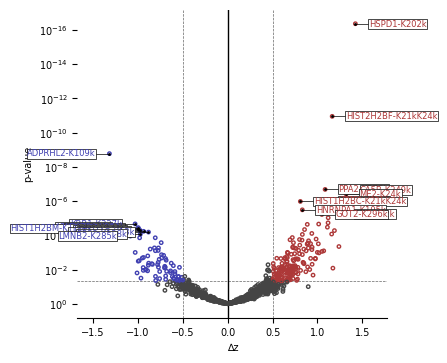

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAT1-K190k""",null,-0.780131,null,-1.0448,null,null,null,null,null,null,-0.329011,-0.833418,-1.31984,-0.037524,-0.376297,-1.15632,-2.733088,-1.043356,-1.435963,-0.677197,0.982638,-0.740533,0.495011,-0.653182,0.305024,0.721749,-0.744014,-0.541634,-0.550399,-0.979922,-0.058176,0.056499,-0.876915,-0.9852,-0.0278,-1.44958,…,-0.842563,-0.275706,1.148299,-1.20782,0.835998,0.013334,1.046954,-0.857907,0.856055,-1.160038,2.503714,1.315648,1.179393,null,2.454701,2.552727,1.155867,0.812779,1.876353,0.632412,null,null,null,0.634373,null,null,0.670642,null,0.109938,-0.721316,1.552869,null,0.495373,-1.407493,1.239703,0.000453,0.009007
"""ACAT1-K202k""",null,-1.037825,-0.385503,-1.612142,null,null,null,null,null,null,0.031044,-0.029934,-0.224937,-0.047879,-0.740151,-1.115096,-1.073283,-0.958493,-0.758225,-0.801077,1.008534,-1.90927,0.4488,-0.547771,0.445705,0.244581,-1.277988,-0.510948,-0.187329,-1.041421,0.35067,0.729825,-1.288472,-0.553553,0.199405,-1.121578,…,-0.645617,-0.157972,0.840165,-1.582061,0.779786,-0.036993,1.171567,-1.690783,1.176362,null,2.099491,1.09315,1.004859,1.225157,2.656664,1.850906,1.988056,1.568033,2.090919,0.709129,0.200815,null,-1.860727,0.333705,null,null,0.943141,0.255161,0.019948,-0.677805,0.228245,-1.1064,0.485402,-0.60923,0.924259,0.002229,0.024521
"""ACLY-K468k""",null,0.53612,0.326339,0.102741,null,null,null,null,null,null,null,-1.343159,null,-0.599499,-0.358532,-1.522684,-0.923167,-0.515881,null,0.245045,-0.419003,null,0.279142,0.280826,null,0.208809,null,0.078844,null,-0.103777,-0.307586,null,-0.316665,2.173899,-0.967521,-0.381883,…,1.122796,0.72828,null,0.910904,null,-0.759781,0.111367,null,-0.966213,-1.401646,0.669274,-0.354505,3.101219,1.6315,0.242176,null,0.832576,null,null,1.593815,null,2.347517,null,null,null,null,-0.629606,-0.271598,null,1.107677,null,null,null,null,1.172479,0.008314,0.055927
"""AFF1-K582k""",0.26565,null,1.19134,1.119983,null,null,null,null,null,null,-1.252064,-0.678161,null,-0.349483,0.454105,-0.291718,-1.202644,0.470146,-0.472504,0.012422,-0.835858,-0.339586,-0.483032,0.544378,-1.627202,-0.9264,0.419358,-0.32781,-0.452254,-0.045723,0.29697,-0.192839,0.359634,-0.070073,1.153165,-2.077036,…,0.790345,0.309088,0.20112,-1.403234,0.084771,-0.098918,0.92209,-0.910078,-2.933913,1.649381,null,-0.197684,1.621439,-0.329646,0.818913,0.033006,null,0.621459,0.180608,0.860946,0.930348,1.631214,1.416164,1.11705,0.616572,2.794435,null,0.795453,-1.408803,-0.352128,-0.71478,-0.048127,null,0.463495,0.714718,0.006362,0.049158
"""AHNAK-K1191k""",null,null,null,null,null,null,null,null,null,null,-0.608139,-0.655376,null,-1.306549,-0.336461,-1.397389,null,0.531013,-0.69624,-1.698265,0.142374,0.136031,0.592606,-0.824028,-1.932641,-1.078777,0.106654,-0.779713,-0.524195,1.027049,-0.265407,-1.393109,-1.041033,-0.988225,0.277569,-0.174499,…,1.110406,1.064269,0.089626,1.58353,0.387979,0.79995,0.069231,null,-1.715897,-0.426858,null,0.06867,0.447703,2.156612,null,-0.160427,null,0.160867,-0.062642,0.361093,null,null,nul

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADPRHL2-K109k""",null,-1.099486,-0.459232,-0.650771,null,null,null,null,null,null,null,null,0.200278,1.968264,null,null,0.563835,-1.081951,1.4904,0.485926,1.561297,null,1.017386,0.635038,1.375021,1.732624,null,0.066192,null,null,0.085537,0.298842,null,1.923498,0.420529,null,…,null,null,1.279908,-1.32839,null,null,0.445049,0.533679,-0.639696,1.308956,-1.315774,-1.827977,-0.362387,null,-0.223576,-0.155784,null,-0.768814,-0.985424,-0.635706,-0.278455,-1.113475,-0.832075,-1.733284,-0.695965,null,-0.995109,null,0.07772,-0.805723,-0.978968,-1.440596,-1.283492,-1.226461,-1.318599,1.6802e-9,5.2365e-7
"""AFF4-K759k""",0.701412,1.274248,-0.019999,-0.558168,null,null,null,null,null,null,null,null,-0.57113,0.871525,0.324508,null,1.328111,2.14034,-0.598591,-0.125978,-0.072862,0.449319,-1.52819,null,-0.895046,1.025545,null,0.115251,null,null,1.79001,-0.180902,null,0.479021,0.350071,null,…,null,0.503437,1.152559,-2.424206,null,null,1.00988,null,null,0.920369,0.103813,0.308516,null,-1.310944,0.592457,-0.96262,-0.889983,-0.865221,0.080702,-1.814445,-1.565171,-0.094286,null,0.272197,null,null,0.27715,-0.918047,-0.914746,-1.147512,-0.0233,0.745984,0.19791,0.072448,-0.589132,0.017499,0.087966
"""ANXA11-K408k""",0.21871,0.42971,null,-0.200962,null,null,null,null,null,null,0.232046,-0.57232,null,1.018001,-0.154374,0.013341,-1.801912,null,null,-0.74134,1.25576,null,-0.513968,null,null,0.126972,0.631454,null,-1.476294,-0.143928,0.140344,null,0.714254,null,null,2.449651,…,-1.0522,-0.920504,null,-0.194448,1.560353,0.074943,-1.251407,null,null,0.537275,-1.680291,-0.130386,-0.224187,-0.510332,-0.779539,-0.033035,-1.172435,-0.829015,0.032447,-0.943973,null,-1.664284,null,0.314751,1.187855,null,-1.184077,-1.517311,null,0.292923,-0.428842,null,-0.423022,null,-0.763899,0.002533,0.025471
"""ANXA6-K299k""",-0.24852,null,-1.060195,1.541864,null,null,null,null,null,null,-0.477194,1.314739,1.560032,0.398773,1.92121,-0.498406,0.331048,0.548982,0.174814,0.611002,1.677763,1.928178,0.996475,-1.134134,2.374995,1.688086,1.29756,-0.454819,-0.485061,1.437523,-0.300499,-1.32634,-1.659974,-0.614055,2.189051,-0.471975,…,0.51693,-0.847782,-0.307836,-0.157809,0.620283,1.138811,-1.035048,-1.717492,-0.117913,-0.39829,-1.710709,0.302739,-1.332991,-0.26279,-1.196593,0.786428,-0.498863,-0.684575,null,-0.360891,-0.862942,null,-0.545029,0.576584,null,null,-2.329747,-1.332991,null,0.479007,0.880857,null,null,-1.053899,-0.680936,0.012709,0.070042
"""ANXA6-K314k""",0.438947,-0.866449,null,0.466997,null,null,null,null,null,null,0.788735,0.120049,0.693251,0.587574,1.274139,1.246543,-0.215322,1.311581,-0.498454,-0.064875,1.41741,1.641824,0.463416,null,1.784334,0.459145,1.400742,0.53414,-0.434555,0.227113,0.627703,-1.728775,-0.351541,-0.311737,0.880677,1.177253,…,0.488094,-0.042382,0.236774,-2.897965,0.596916,-1.002795,0.349925,-0.781944,null,0.550319,null,null,-1.997074,0.108822,-0.582714,-0.96786,null,-0.563295,-4.036081,0.235046,null,null,-1.118898,0.348325,null,null,null,-0.18678,0.143345,-0.

Lipidomics


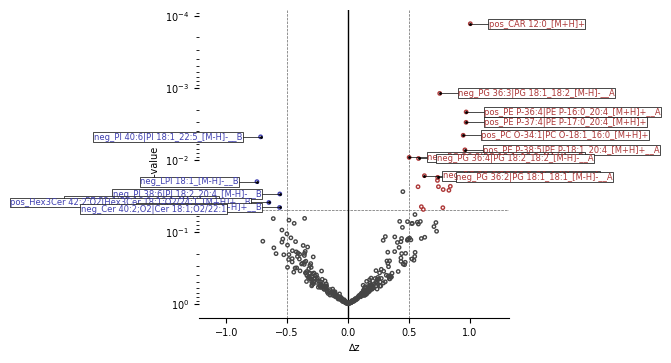

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-0.252981,null,-1.122951,null,-0.765425,-0.398121,-0.7248,0.189961,0.240135,-0.680867,-0.283508,1.22827,-5.743621,1.1262,1.184797,0.764834,0.218094,-0.609598,-1.024785,0.433659,0.290816,0.660444,1.405235,-0.620278,0.59362,0.230368,-0.181538,-0.420191,0.224847,-1.05963,0.208745,-1.132541,-0.49523,0.248579,-0.440289,-0.124307,…,0.492761,0.631629,0.33137,0.687794,-0.195127,-0.622597,-1.661541,0.667941,-1.36951,null,-0.658919,0.600387,1.014586,0.908228,-0.10574,0.075479,1.568828,0.603641,0.893183,0.574967,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.627973,0.016584,0.49875
"""neg_PG 36:4|PG 18:2_18:2_[M-H]…",0.543967,null,-0.634229,null,-0.448326,-0.662837,-1.739557,-0.061624,-0.085087,-0.972053,0.847763,1.447975,-5.950947,0.671118,0.419207,1.393838,0.563307,-0.911115,-1.024077,-0.080679,1.048202,-0.531745,0.868696,-0.243265,0.318314,0.551654,-0.704468,-0.124982,0.252174,-1.110371,0.682773,-0.320328,-0.560964,0.553006,-1.010924,0.287088,…,0.13061,0.460751,-0.40139,0.80934,0.059857,-1.007497,-0.90291,0.875697,-0.87021,null,0.303021,1.689264,0.898252,0.060647,0.036189,0.263376,0.831197,0.164234,0.48723,0.320595,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.579724,0.00957,0.364724
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",0.01127,null,-1.435718,null,-0.173574,-0.26255,-0.997187,0.00182,-0.102823,-1.596753,-0.022973,1.236675,-5.005927,1.230839,0.760984,0.930224,-0.579679,0.068545,-0.52339,0.191045,0.415892,0.523862,1.543681,-0.052111,0.900088,0.851624,-0.222405,-0.095929,0.402153,-1.064415,0.268696,-1.4767,-0.148016,-0.004043,-0.258276,-0.443062,…,1.04072,0.567392,0.826367,1.031962,-0.201125,-0.613535,-2.035794,0.634137,-1.207439,null,-0.620542,0.29928,0.942391,0.736745,-0.284234,0.408265,1.483443,0.536995,1.045987,0.470113,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.575645,0.023613,0.49875
"""neg_PG 38:5|PG 18:2_20:3_[M-H]…",0.885467,null,0.488524,null,null,null,null,-1.947902,-2.613927,-0.290414,-1.176371,1.098056,null,-0.803572,-0.739004,-0.113341,0.729917,-1.549878,-1.929455,-1.200156,1.045609,-0.935167,-0.328179,-0.321824,-0.065732,1.252771,0.137796,0.525084,0.274067,-0.979665,1.823583,1.083383,0.020004,-0.043241,-0.311434,-0.002732,…,-0.565702,0.987032,-0.125935,1.847283,0.01372,-0.099897,-0.128332,-1.08144,-0.233929,null,-0.922407,1.705844,0.881807,0.981375,-0.174111,-0.407538,1.261912,0.412843,0.946274,0.666383,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.618869,0.048774,0.619612
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.530546,null,-1.281459,null,-1.976608,-0.660018,-1.269323,0.144972,-0.714831,-0.870543,-0.683189,0.885114,-4.634128,0.643205,0.467883,0.00449,-0.206092,-0.441338,-0.025271,0.117197,-0.217424,0.088622,0.935979,-0.513005,0.211451,0.332307,0.03883,-0.465497,0.138625,-0.717454,-0.659475,-1.320454,-0.49207,-0.173537,0.101689,-0.391796,…,1.572616,1.145653,1.079833,1.278731,-0.172274,-0.014688,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 18:1_[M-H]-__B""",-0.205999,null,-0.705655,null,null,null,-2.004004,-1.133605,null,null,0.869508,-0.837947,-0.7344,-1.47559,-2.971856,1.193782,-1.407128,-0.876479,-0.247417,-1.439656,0.400243,-0.248934,0.034194,0.131676,0.491914,0.470329,-1.407623,1.093282,0.584345,0.170706,-0.691053,0.498225,0.150627,-0.77926,-0.807929,0.84501,…,-1.674575,-1.33914,0.308071,1.088694,2.052977,0.351893,1.648176,0.504335,0.472849,null,0.948115,-1.858196,-1.026105,-1.156629,-0.588363,-0.790739,-0.498775,-0.288858,-1.404561,0.195142,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.747975,0.020071,0.49875
"""neg_PI 38:6|PI 18:2_20:4_[M-H]…",-0.650188,null,-0.508241,null,-1.382843,-1.995459,-0.054055,-0.796981,-0.064398,0.691061,0.08711,-0.840761,-2.651825,0.595501,-0.599499,-0.861687,-0.89762,0.452509,-0.442268,0.313631,-0.982868,-0.507983,0.959005,1.778713,0.811692,0.094603,1.095206,0.292566,-0.075394,0.310389,0.961286,-0.302268,-1.031494,0.371306,1.01202,-0.071326,…,-1.320462,-0.666153,-0.464694,1.511834,0.85178,1.218486,1.611991,-0.846733,0.222389,null,-0.424365,-0.49774,0.16966,-1.707129,-0.802199,0.088719,-0.81447,-0.102084,0.30432,-1.100623,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.560443,0.029757,0.510327
"""neg_PI 40:6|PI 18:1_22:5_[M-H]…",-1.18337,null,1.006789,null,-2.408316,-3.625297,-0.243495,0.209182,-1.26071,1.114092,1.069912,-0.457108,-0.860221,-0.746651,-1.24435,-0.706476,-0.004072,1.212049,0.727629,0.327253,-0.817395,-1.585489,-0.278391,0.925326,-1.21679,0.350495,0.575692,0.239684,0.096469,1.40947,0.426664,0.896426,-0.115045,0.105452,1.312669,0.107091,…,-0.774506,-0.344818,0.500947,0.821424,0.651602,0.858465,1.096954,-1.726198,-0.09324,null,-0.205487,-0.767385,0.232837,-1.250268,-0.052519,-0.748113,-1.152514,-0.389987,-0.296767,-1.631504,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.718255,0.00479,0.273848
"""neg_PE 32:1|PE 16:0_16:1_[M-H]…",-0.744667,null,-1.419649,null,0.819877,1.29017,1.431417,2.196072,1.046273,-0.447429,-2.657668,-0.712539,0.727115,-0.536418,-0.609141,0.556765,-0.453207,0.066479,1.065673,0.139383,-0.133018,-0.85005,-0.574619,-0.404669,0.052265,-0.105525,-0.902499,-0.579582,0.765549,-0.327375,-0.309248,-0.29572,0.742015,-0.587361,-0.206285,-1.029086,…,0.499813,1.562726,1.095958,2.171327,-0.043262,1.808933,0.237925,0.574929,1.913916,null,-1.432831,0.297925,-2.180376,-1.596761,0.512062,-1.403678,-1.603814,0.545675,-1.809647,0.7307,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.91085,0.037055,0.605233
"""neg_Cer 40:2;O2|Cer 18:1;O2/22…",0.325911,null,-0.543454,null,-0.031831,-0.867103,-1.06449,-0.126722,-0.600514,-2.569063,0.609726,-0.570276,0.013161,-0.271166,-0.011365,-0.619756,-1.019754,-1.319977,-0.398173,0.053905,0.439808,1.576296,1.163727,-0.03209,-1.057262,0.299942,-0.152501,-0.105064,-0.567663,-0.995482,1.990632,0.705761,-0.290236,2.088459,0.879642,-0.329323,…,-0.590789,0.295854,0.212365,-0.08571,0.95

Metabolomics


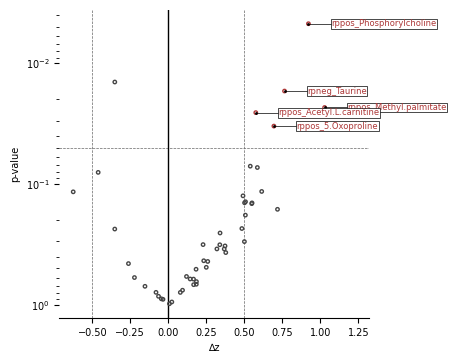

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_5.Oxoproline""",0.491023,null,-0.286614,null,-1.311169,-1.908373,-0.689764,0.316919,-0.358297,0.148213,0.728149,0.471395,-0.817674,-0.741974,0.253592,0.704193,-1.30777,-0.369153,0.737671,0.30179,0.072137,-1.439994,1.460674,-1.424925,1.16709,-1.518937,-0.360283,-0.098604,-0.346371,-0.050312,-0.407445,-0.289078,-3.390268,-0.455248,1.270998,-1.428298,…,1.501273,-0.517747,0.174655,-0.513894,-1.727128,0.481098,0.072275,-1.650543,-0.742202,null,1.370128,0.424091,-0.144884,0.873838,0.107092,-0.863575,1.578045,0.038762,0.920162,1.745651,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.693892,0.033233,0.271407
"""rppos_Acetyl.L.carnitine""",1.714172,null,-1.220078,null,-2.823441,-0.68525,-1.345283,1.345795,-0.702689,0.252563,0.462705,0.482352,-0.420855,-0.280851,-1.375025,-0.206783,-1.632323,0.15615,0.402999,0.509769,0.090077,-2.21705,1.271068,-0.107394,1.867438,-1.681873,-0.669248,-0.455498,0.71426,-0.074215,-0.117817,0.120233,-2.666905,-0.685625,1.600741,-1.894651,…,0.370628,-1.052467,-0.331758,0.50016,-1.069728,0.905018,0.298585,-1.559727,0.400572,null,0.836222,0.335183,-0.329396,0.834036,-0.407156,1.651857,0.305482,0.284462,1.119576,0.380958,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.574817,0.025689,0.251748
"""rppos_Phosphorylcholine""",0.911043,null,0.272502,null,-2.273592,-0.865468,-0.499987,-0.037025,0.015326,0.423205,0.477213,0.57454,-0.53872,-0.23594,-0.495533,-0.052802,-1.449434,0.993607,-0.547246,0.228748,-0.135313,-2.538984,1.418551,-0.748715,0.834644,-1.012236,1.486771,-0.542331,0.06542,-0.343052,-0.678735,0.936155,-2.815241,0.452819,1.186604,-1.090406,…,-0.708131,-1.396067,-0.76447,-0.801249,-2.104169,-0.110225,0.800628,-1.1169,-0.903536,null,1.49651,1.863172,0.260809,0.309097,0.725555,0.40504,0.800994,-0.623952,1.835983,0.956404,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.921044,0.004714,0.230992
"""rppos_Methyl.palmitate""",-1.539198,null,3.80203,null,-0.427832,-0.714859,-0.410162,-0.973815,-1.151243,-0.709288,-0.626901,-0.51932,-0.590882,-0.593824,-0.918627,-1.44358,-0.809854,-0.740056,0.068737,-1.593231,-1.165754,0.043723,-1.13716,0.566887,0.630162,-0.97334,1.274465,0.605296,-0.171984,-1.127686,-1.134121,-0.73404,0.532681,1.369018,0.319318,0.471105,…,0.507301,0.227584,0.420645,-0.46564,0.790477,1.559357,0.532148,-0.681571,-0.228087,null,1.587401,1.867115,1.228117,0.662394,1.125913,1.831979,1.233674,1.591262,-1.950038,-0.221221,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.027374,0.023304,0.251748
"""rpneg_Taurine""",0.622264,null,-0.783323,null,-2.177944,0.341467,-0.59861,-0.432845,-0.305968,-0.466906,-0.193768,0.808307,-0.103973,0.615232,-0.191498,-0.852625,-1.665583,0.689241,-1.265153,1.094384,-0.37962,-1.567948,0.685291,-0.639814,0.47145,-1.263574,0.454539,-1.135373,-1.046208,-0.843584,-0.381227,-0.247713,-1.825436,-0.388053,1.71095,-0.649971,…,0.667951,-0.749992,-0.867995,0.24861,-1.074155,1.607625,0.02588,-0.

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITD-WT ============
Transcriptomics


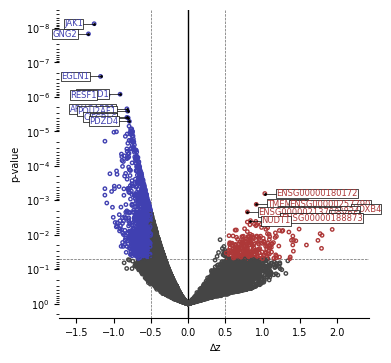

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""WDR54""",null,-1.052432,-0.438112,0.061917,-1.894626,null,-0.509965,1.482147,null,0.895704,null,-0.804622,0.794418,0.269823,-1.234979,0.420595,1.427968,-1.073409,0.332252,1.030009,-0.040962,-0.256816,-1.270928,-0.832465,null,-0.146552,null,null,null,null,0.278264,-0.91024,0.671882,2.491906,-0.033181,null,…,-1.320453,null,-0.27552,-0.24129,null,null,null,-0.26676,-0.643612,-1.32965,-0.610116,-1.267315,0.202394,-0.202769,null,-1.281203,0.203419,0.559597,-0.73723,null,null,3.462205,0.806437,null,null,0.995895,null,-0.48653,0.510683,1.319463,-0.263666,null,1.663205,-0.206221,1.026044,0.03817,0.446923
"""NFIX""",null,-0.842594,0.400398,-0.203715,2.075853,null,-0.237274,0.093641,null,-0.853611,null,-0.288666,-0.683287,-0.453699,-0.507309,0.12135,-0.650129,-0.020277,0.322765,-0.546427,0.176157,-0.675166,-0.031787,-0.078747,null,-0.551304,null,null,null,null,-0.195123,-0.017216,-0.196816,0.423054,-0.306655,null,…,-0.911118,null,-0.579532,0.097662,null,null,null,-0.17286,-0.847887,-0.774276,-0.322273,-0.896565,-0.634908,-0.471157,null,-0.683169,-0.623397,-0.466087,-0.027233,null,null,2.499943,2.252053,null,null,1.043426,null,0.482443,3.840886,-0.205411,3.692708,null,0.63784,-0.572759,1.798017,0.010389,0.249084
"""UQCRC1""",null,0.373525,-0.610121,0.10761,-2.108221,null,0.129405,0.164249,null,-0.035084,null,-0.54277,-0.693195,-0.458696,-0.901196,-0.434967,-0.322488,0.012998,-0.22211,1.394038,0.243657,0.414242,-1.697563,-1.133457,null,0.56929,null,null,null,null,0.174806,-0.429299,-0.796686,0.589275,0.348205,null,…,-2.263315,null,1.604573,-1.098831,null,null,null,1.383931,3.964205,-1.164085,0.142458,0.773156,-0.174314,-0.328454,null,0.457969,0.20756,-0.951445,-1.757733,null,null,1.953802,0.597425,null,null,1.05759,null,0.070688,-0.580614,0.590358,0.027245,null,-0.012517,1.234218,0.649468,0.046316,0.479554
"""LRRC23""",null,-0.881403,0.709285,-0.144571,-1.617031,null,0.749363,1.174783,null,-0.587759,null,-0.955226,3.346227,-0.296697,-0.817844,-0.02081,-0.765692,-1.258033,0.324448,-1.3713,-0.845106,0.295018,-0.776146,0.34311,null,0.537359,null,null,null,null,-0.49568,-0.109171,1.013869,2.328935,-0.515852,null,…,-1.807056,null,0.477822,0.314871,null,null,null,1.260433,-1.213851,0.617129,-0.424693,-0.659431,0.811309,-0.492669,null,-0.469353,-0.775237,2.047337,0.308479,null,null,1.120902,0.756479,null,null,0.382609,null,-0.373589,1.869116,0.35258,-0.341557,null,1.26884,0.047143,0.66845,0.037936,0.44651
"""ERCC1""",null,-1.291935,0.299444,-0.643345,-1.041674,null,0.375871,0.231883,null,0.159313,null,-0.98112,-0.127423,0.161422,-0.990988,-0.083948,2.534056,-0.633803,-0.394588,0.565434,-0.882488,-0.800391,-1.288926,-1.090957,null,-0.325921,null,null,null,null,1.043368,-0.579291,0.314218,0.416416,0.913815,null,…,-1.711218,null,0.136466,0.106601,null,null,null,2.011343,0.85051,-1.134797,-1.141162,-0.222077,-0.396796,0.301688,null,-0.834174,-0.705265,1.699987,-1.632871,null,null,1.611056,1.226344,null,null,2.333068,null,-0.62371,1.472

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NFYA""",null,-1.151035,-0.042486,-0.267834,-1.00357,null,1.091672,-0.072624,null,0.816145,null,1.82974,0.387871,-0.848053,-0.166267,-0.112172,2.941192,-0.048801,0.383866,0.070035,-0.598243,-0.756761,-0.942015,-0.891239,null,-0.770068,null,null,null,null,-0.535155,2.879025,3.273823,-1.027059,0.351248,null,…,-1.384646,null,-0.101216,0.756151,null,null,null,-0.337822,-0.601959,-0.412165,-0.4439,0.652067,-0.750435,-0.403679,null,-0.561274,-0.621906,1.592199,-0.387504,null,null,-0.655164,-0.42634,null,null,-0.472049,null,-0.972797,-0.608173,-0.141301,-0.764447,null,0.747586,-1.065161,-0.573141,0.023393,0.35903
"""ST7""",null,0.03225,-0.303084,1.198863,-0.60808,null,-1.339226,1.35495,null,-1.33663,null,-1.07622,-0.512491,-1.271845,0.937296,1.274992,-0.017568,0.9529,1.620058,1.496615,0.236236,-0.460884,-0.059822,-1.167325,null,-0.102756,null,null,null,null,0.677432,4.33137,-0.012319,-0.523145,0.431184,null,…,-0.800097,null,-0.411596,0.526776,null,null,null,-0.790624,0.572844,0.25871,0.306296,-0.754822,-0.002998,-0.411752,null,-0.011016,-0.311359,0.535254,-0.511907,null,null,-0.93493,0.184012,null,null,-0.120291,null,-1.25022,0.076615,-0.219624,-1.366994,null,-1.359481,-0.095935,-0.669019,0.021055,0.342649
"""COPZ2""",null,-0.064936,-0.611785,0.03502,-0.700114,null,-0.615649,-0.277486,null,-0.45797,null,0.016307,0.151363,-0.542785,-0.628858,-0.623652,-0.621806,-0.700114,-0.348085,-0.530363,-0.091797,-0.118457,-0.700114,-0.410251,null,0.01782,null,null,null,null,-0.630567,-0.468109,-0.602979,0.28125,-0.156353,null,…,-0.700114,null,1.094282,-0.700114,null,null,null,2.707114,0.37286,-0.260697,-0.467778,0.0227,0.105311,-0.151838,null,-0.276027,2.222482,0.247519,1.425312,null,null,-0.668225,-0.385389,null,null,-0.334563,null,-0.520579,-0.613505,-0.700114,-0.090624,null,-0.63128,-0.283232,-0.555999,0.001669,0.109964
"""MSL3""",null,-0.373164,-0.382357,0.610623,-0.880298,null,-0.713617,-1.171085,null,-1.239397,null,-0.199356,-0.139963,1.349247,1.019639,-0.96701,3.434238,-0.05459,-1.641795,-0.566202,-1.617699,0.755794,-1.056113,1.615907,null,-0.277291,null,null,null,null,0.305283,1.20675,0.506835,-0.234006,-0.366023,null,…,-1.613516,null,-0.767506,-0.886142,null,null,null,0.758352,1.299414,0.285201,-0.617121,2.04437,-0.301247,0.893206,null,1.402579,-0.66523,1.464344,-0.071794,null,null,-0.731925,-0.988446,null,null,0.277078,null,-1.338611,-0.82875,-1.231137,0.185122,null,0.004157,-0.108493,-0.626164,0.025035,0.370102
"""CREBBP""",null,0.99875,0.060735,-0.175126,1.058944,null,-0.182175,-0.491348,null,-0.70532,null,0.616474,-0.003704,-0.962207,1.480126,-0.435899,-0.540487,0.236358,-0.653401,-0.555874,0.00628,-0.30274,2.934193,4.931393,null,-0.102631,null,null,null,null,-0.390674,-0.174168,-0.277199,-0.951382,-0.540173,null,…,-1.522258,null,-0.327025,0.558576,null,null,null,-0.550957,-0.741466,2.203312,-0.041016,-0.561594,0.4377,-0.307678,null,-0.488052,0.456621,-0.304043,0.015815,null,null,-0.934781,-1.151475,null,null,-0.037867,n

Proteomics


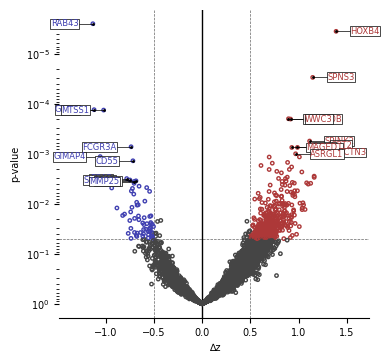

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB8""",-1.445862,0.112973,0.008697,-0.947694,null,null,null,null,null,null,-2.427172,-1.001652,-2.140759,-1.533461,-1.301862,-1.002473,-1.014477,-1.405277,-1.228186,-0.931267,-0.073886,-0.289237,0.249241,0.301607,-0.451498,-0.068058,-0.332712,0.732112,-0.49716,0.385148,0.766515,0.688441,-0.92362,0.453115,0.746895,-0.482869,…,-0.527577,0.795512,-0.370168,-1.757202,0.13967,-0.694007,1.04708,1.016636,1.050496,-0.06045,0.763946,1.592201,1.260938,-0.275848,0.333629,0.879544,0.4838,0.770952,-1.374792,0.958603,0.055175,1.195784,null,-0.448863,-0.854385,1.098889,1.12992,0.454289,2.175674,-0.547747,-0.170895,1.913146,1.319706,1.489803,0.864307,0.015518,0.665444
"""ABHD17B""",-1.036827,0.293729,-0.419048,-0.490123,null,null,null,null,null,null,-1.446795,-0.88562,-2.606136,-1.795205,-1.69122,-1.41509,-0.688364,-1.594178,-1.00848,-0.977308,0.176054,-0.460315,0.385921,0.205835,-0.083676,-0.275922,-0.639795,0.521203,-0.430814,0.210515,1.729716,0.974702,0.29364,-1.261988,0.946837,-1.478728,…,-0.618126,1.499486,-1.303097,-0.633133,-0.502784,-1.093477,1.052776,0.963728,0.714894,0.23575,1.184637,0.138406,-0.650952,0.015346,-0.103728,0.215176,0.502967,1.212219,-1.674854,1.328072,-0.529133,1.108749,null,1.0143,-0.301315,0.853434,0.632797,0.013536,-0.269929,1.483319,-0.493475,1.867337,1.134183,0.003483,0.695608,0.014086,0.665444
"""ACADVL""",-2.094354,0.485774,0.121976,-0.278192,null,null,null,null,null,null,-2.25454,-1.365735,-1.299466,-1.243973,-1.25481,-1.178931,-0.737651,-1.571397,-0.888036,-1.188466,-0.219446,-0.468275,0.306548,-0.178889,0.205028,0.24656,0.194831,0.101735,-0.680715,0.387092,0.441451,0.275445,-0.495232,1.150276,0.160607,-2.203504,…,0.298962,1.786991,-0.305544,-1.564031,-0.07958,-1.624576,0.772985,0.985126,0.815071,0.688115,0.757503,0.996295,1.030744,0.089985,0.138717,0.312842,0.977395,0.915292,-1.702825,2.530324,-0.795148,1.45967,null,0.06508,-1.275783,0.613026,1.476641,0.051886,1.534169,0.042933,-0.588138,1.026469,1.740982,0.51918,0.658065,0.041875,0.665444
"""ACY3""",-1.222216,-0.363953,1.167079,-0.023956,null,null,null,null,null,null,-1.469923,-0.693959,0.702468,-0.429699,-1.177096,-1.886609,0.38821,-0.902289,-1.097151,1.311883,-0.285838,0.682844,-0.162979,0.123891,-0.412867,0.553109,0.352855,1.316193,-0.115133,-0.072563,1.672523,0.893291,1.139936,-0.420539,1.307454,1.162832,…,0.688551,-0.760164,-1.627517,-1.577319,-0.427443,-0.440731,0.222736,0.335163,-0.196929,-1.385331,-0.437457,-0.984176,-1.192925,-0.468905,0.274864,0.547563,-0.502037,0.783219,-1.543461,-3.090115,-0.952908,1.416367,null,-0.237048,-0.43165,0.619282,-0.177406,0.707607,0.940963,1.416456,0.698127,1.965991,0.577142,-0.575363,0.683174,0.018244,0.665444
"""ACYP2""",-1.06206,0.341416,0.033563,0.515507,null,null,null,null,null,null,-1.505542,-1.035942,-1.056114,-0.702883,-1.097848,-1.840589,-1.308323,-1.403602,-1.952727,0.455338,-0.90982,-0.365298,0.876764,-0.080079,-0.735482,-0.240528,0.445621,-0.342904,-1.031861,0.853289,1.505597,-0.057979,-0.7

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALOX12""",null,2.454338,null,null,null,null,null,null,null,null,0.418164,0.402131,0.285794,1.366413,0.221772,0.414944,0.012403,-1.513726,-0.623121,1.553247,0.097569,1.530428,1.420441,-0.965351,-0.913701,-0.821169,-0.782621,0.034016,-2.569187,-0.178731,0.20387,-0.953351,1.067608,0.091384,1.951467,0.15208,…,-1.225833,0.956131,0.13675,2.874366,0.458476,-1.310812,-0.210551,-0.124454,0.433366,0.260933,0.029081,-0.235336,-1.25069,0.420765,-0.005045,-0.410169,0.056893,-0.833371,-0.491393,0.2007,-0.955367,null,null,-1.567005,-1.149624,0.699884,-0.546201,-0.692334,-0.166306,0.703981,-0.98831,-0.335138,-0.985905,-0.432102,-0.584327,0.032184,0.665444
"""ARHGAP12""",-0.195948,1.350022,0.505483,0.013669,null,null,null,null,null,null,-2.220444,-1.6594,-1.394344,-0.796608,0.42708,-1.562165,-0.806493,0.101817,-1.073163,-0.357691,-0.947157,0.36911,-0.924198,0.560299,-0.78721,-1.167406,0.721616,0.536605,-1.159154,0.901701,0.828782,-0.800143,-0.808066,-0.680324,0.601222,0.220434,…,-0.836272,-0.393548,0.27891,-0.257261,2.311767,0.453769,0.296022,1.326951,1.884532,0.059875,-0.202499,2.431798,-0.021701,1.190868,2.566253,0.900245,1.229804,1.362248,-0.871635,0.854671,-0.824433,-0.863357,null,-1.218939,-1.079752,0.168297,0.30121,-1.209646,-0.704791,-0.63224,-1.178021,-0.077125,0.387867,0.796,-0.524241,0.044031,0.665444
"""C5AR1""",0.418535,1.334816,-0.654137,1.052652,null,null,null,null,null,null,-1.113809,0.475083,-0.423874,-1.301431,0.567798,0.099669,-1.259062,0.34768,-3.141868,-1.346645,0.988541,0.683857,-0.425738,-1.819638,0.668196,0.43036,0.427694,0.132679,-0.495184,0.072377,-0.832036,-0.255813,-1.258324,-1.669007,1.017252,1.267025,…,-1.33266,-1.6392,0.594548,0.74187,1.771684,0.252244,0.435339,1.370126,0.869896,0.188029,0.067483,0.726355,0.334072,0.536376,1.498624,0.712515,0.884621,-1.277002,0.915617,-1.483191,-1.108827,-0.303077,null,-1.601777,-0.507391,-0.297446,-0.830543,0.571013,-0.934075,-0.242541,0.23904,-0.504031,-1.001899,-0.601047,-0.593667,0.008798,0.665444
"""CAMK2D""",0.219702,0.465219,-0.461914,0.08128,null,null,null,null,null,null,-1.799474,-0.57248,1.01143,0.703368,-0.14254,-2.333171,-0.454381,-1.232114,-0.135476,-0.660224,-1.332424,-0.066271,-0.88862,-0.882734,0.433136,-0.937471,0.415807,-0.341281,-0.711237,-0.833691,1.597198,-0.139011,0.596305,0.532387,0.390828,0.133821,…,1.182778,-1.192497,-0.474474,0.586247,2.071923,0.209114,-0.163483,0.382628,1.924293,-0.159184,-0.165665,0.877385,0.308544,1.719643,1.728364,1.273315,1.247684,0.645245,-0.515618,2.75443,-1.011452,-0.460796,null,-1.49881,-2.311044,0.835727,0.693455,-1.958153,-0.352325,-0.954738,-1.157837,-0.493751,-1.221049,1.117027,-0.766278,0.038941,0.665444
"""CD55""",-0.438655,1.310277,-0.571798,-0.393137,null,null,null,null,null,null,-1.753114,-1.051443,0.240109,0.364309,-1.13201,-1.569323,-1.040861,-0.248841,-1.298057,0.047525,0.112315,0.74241,-0.311619,-2.878853,0.080723,-0.032238,0.040884,-0.394894,-1.236266,-0.125674,-1.121636,-0.880952,-1.345117,0.338045,1.

Phosphoproteomics


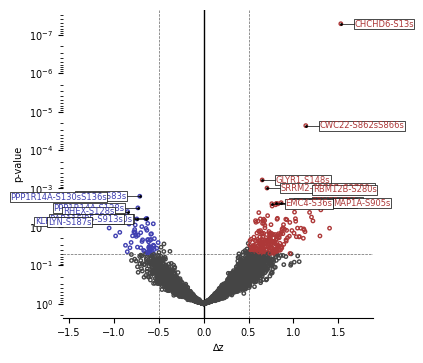

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADNP-S415s""",-0.453605,-0.491106,1.202209,null,null,null,null,null,null,null,-0.556783,-0.598557,-2.750404,0.077379,-0.995858,-1.794818,0.666392,null,-1.408664,-0.347842,-0.870487,-0.069985,-0.112092,null,-0.020843,-0.435868,-1.440847,null,-0.940883,-0.054033,2.228751,0.007371,0.192415,null,null,-0.599489,…,1.039704,0.182195,null,-0.633514,-1.117487,0.140214,null,-0.280987,0.527286,0.405735,-0.050654,1.081078,0.106317,0.431825,0.632491,-0.869007,1.314882,2.113571,-0.98961,null,-0.802136,1.192013,null,-0.163331,-1.170738,1.078778,1.227482,null,0.567555,1.17497,null,1.566415,1.560568,0.276878,0.86644,0.013575,0.997127
"""ANK1-T1378t""",-1.94472,-0.761142,-1.278617,-0.353938,null,null,null,null,null,null,-2.52058,-0.280871,1.944302,-1.181878,0.613246,-0.26733,-0.130285,-0.132268,-0.898145,-0.617239,-0.238065,-0.128775,-0.727798,-0.777545,0.25325,-0.537492,-0.716608,1.003076,0.076036,0.083071,1.508534,1.598033,-0.370351,-0.95499,-0.402412,1.387363,…,0.332151,-0.065907,-0.863561,0.490009,-0.212588,-0.794709,0.161482,-0.072652,0.421347,-0.115423,-0.265583,-0.025749,-0.93358,-0.581722,0.605402,-0.656517,1.090369,-0.536044,-1.630934,-0.483612,-1.609684,null,null,0.025284,1.968783,0.584407,-0.026945,1.226572,1.680353,1.434806,-1.574515,0.023813,0.284722,1.976888,0.808275,0.037636,0.997127
"""ANKZF1-S56s""",null,-1.417056,1.159908,-0.400019,null,null,null,null,null,null,-1.812174,-1.59701,-0.636571,0.052559,-0.080213,-2.369074,-1.107936,-0.402833,-0.349291,0.288822,-0.591931,0.25888,-0.397326,0.361462,-1.050852,-1.444108,0.466174,-0.483162,-0.604286,1.121998,0.449552,1.425625,-0.919456,0.823878,0.075817,0.306048,…,-0.836218,-0.298644,-0.277123,-0.896433,0.734967,-0.24693,0.867953,-0.036862,1.706342,0.111257,-1.150191,2.350598,0.419528,0.599018,0.003794,0.198489,-0.448116,1.297784,-2.518086,-2.949281,-0.290507,1.465918,null,-0.631348,0.667828,0.733573,0.800328,0.142676,1.283649,0.108173,-0.57824,0.551358,1.159758,1.1874,0.681929,0.009095,0.997127
"""ARGLU1-S77s""",-1.905707,-1.418846,0.805915,-1.537333,null,null,null,null,null,null,-1.271377,-0.743349,-3.044555,-0.589062,-1.037642,-2.162759,0.516303,-0.457538,-0.047703,0.290034,-0.929447,0.223331,0.25026,0.420538,-0.031151,0.638319,0.541887,0.51712,0.19415,1.44855,1.69619,0.704848,0.645781,1.609877,1.1101,0.015528,…,0.754212,0.550096,-1.23365,-2.064832,-1.212875,0.042739,-0.591462,-0.008567,-0.456607,0.44424,-0.429915,1.482703,-0.10563,1.038875,-0.405859,-0.647984,-1.419975,1.155085,-1.875284,-0.522936,-0.231871,0.7557,null,0.016428,-0.238174,1.102784,1.216383,-0.491836,1.283582,0.731932,-0.711963,0.768539,0.565403,0.075139,0.500887,0.043657,0.997127
"""ATAD2-T1245t""",-1.393218,null,0.513164,-0.009996,null,null,null,null,null,null,-1.436322,-1.290366,null,-1.648115,-0.454177,0.098083,-1.338229,-0.254454,-2.208102,-0.323362,0.488764,-1.043397,-2.100384,-0.18109,-0.486028,0.700455,-1.033845,-0.193208,-0.68874,0.327791,0.342567,1.00408,-1.447717,-1.270944,-0.08016,-0.339319,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADAM10-S740s""",null,2.384576,null,0.110112,null,null,null,null,null,null,-0.276448,-0.305911,-1.517582,0.33564,0.041079,-1.132842,-0.292501,-0.482653,-0.508803,-0.014454,-0.920106,1.34234,-1.031474,-1.539894,-0.618006,-0.213228,-0.725665,-0.255584,-0.787977,-0.048246,0.706962,0.061648,-0.826169,-0.529593,1.746151,0.241816,…,-0.595879,0.388352,0.038119,2.705736,1.331804,0.571578,0.857248,-0.549635,1.56552,-0.551713,-0.987671,2.061585,1.110887,1.152986,2.162282,-0.771982,1.510965,-0.171235,-1.326476,-1.814754,-0.817469,null,null,-1.325478,-0.422464,0.754459,-0.040425,-1.30022,-0.774751,-1.076303,-0.271467,0.011603,-0.467563,0.019984,-0.522445,0.035967,0.997127
"""ARHGAP30-S291s""",0.03264,1.796118,0.782238,null,null,null,null,null,null,null,null,-0.389863,-1.455548,0.533116,null,null,null,0.509521,-0.735725,null,0.119932,0.500792,null,0.081179,-0.209159,-0.127272,null,-0.37958,null,0.043575,0.230219,0.137082,-3.508699,null,0.852545,-0.230212,…,null,-1.927879,null,null,null,0.647123,1.085959,null,0.813825,-0.248531,null,1.039325,null,0.582019,2.013657,null,1.220147,null,-0.860396,-1.853687,0.836419,null,null,-0.979831,null,null,null,-1.384694,-0.92742,null,-1.021918,-0.737721,0.347254,-0.262926,-0.83076,0.008446,0.997127
"""ARHGAP6-T821t""",-1.027282,2.434764,-0.009913,-0.146106,null,null,null,null,null,null,0.347062,0.396951,null,1.606099,0.352075,-1.212809,0.089049,-0.779362,null,2.509144,-0.610616,null,0.062529,-0.280698,null,-0.545727,-0.850511,-0.067195,-0.877393,-0.311009,0.528391,null,-0.644347,0.061827,1.868161,1.811002,…,-1.087392,0.737949,-0.668185,3.22817,0.414895,null,0.342711,-0.604454,-0.713128,null,-0.510721,0.492286,-0.64959,null,1.09801,-0.865444,0.974799,0.378998,null,-0.235362,-1.084825,null,null,-1.705185,-0.101963,-0.898618,-0.59307,-0.685667,0.215651,0.519361,-1.016549,null,-0.330369,-0.611046,-0.61718,0.021419,0.997127
"""BIN2-S462sS476s""",0.923808,0.923581,null,0.099686,null,null,null,null,null,null,-1.339298,-0.831983,null,0.859468,0.038303,-1.490079,-0.458411,0.027725,null,0.419682,-0.073805,null,-0.675114,0.548031,null,-0.93714,-0.737568,-0.019735,-0.952789,0.142472,0.08674,null,-0.742638,-0.859345,2.240378,1.792352,…,-1.703785,-0.401839,-0.885188,0.906248,1.901063,null,0.12029,1.247999,2.279002,null,0.469626,1.186632,1.503405,null,1.66253,0.394388,1.168043,-0.032601,null,-1.99949,-1.405995,0.988129,null,-1.157388,-1.043867,0.016807,-0.111109,-0.850459,-1.510348,-0.818899,-0.446001,null,0.364674,-0.991933,-0.610404,0.03353,0.997127
"""BNIP2-T237t""",-0.322796,-0.136139,1.100396,null,null,null,null,null,null,null,-2.07559,-1.771262,null,-0.234354,-0.253807,-0.987451,-0.284614,0.11555,-0.784544,0.176659,-0.314096,0.104937,-0.242022,-0.343699,-1.329434,0.466779,-0.979794,0.404487,-1.175418,0.361801,0.133098,-0.183706,-0.335768,-0.719044,1.454784,0.76458,…,-1.668578,-0.315032,-0.124961,0.648582,1.887172,0.105152,0.435086,1.928871,0.309622,-0.006385,0.909478,0.457274,-0.354791,1.479507,1.9303

Acetylomics


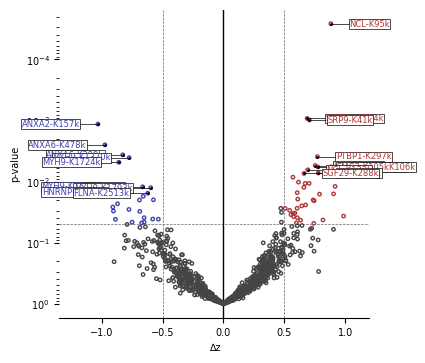

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",null,null,-0.571502,-1.435405,null,null,null,null,null,null,0.327638,0.209687,0.257099,1.355141,-0.106049,-1.892081,-0.890472,-1.046532,0.519124,-0.977388,0.140921,0.424356,0.659687,0.499975,0.281272,0.903723,-0.227061,-0.416734,0.356573,-0.035611,0.061377,-0.71516,0.462771,1.191718,-0.530978,-1.450591,…,0.553948,-1.220264,-0.119653,-0.138604,-0.861513,-1.868151,-0.756475,-0.461686,-0.832999,1.542721,0.638131,-0.465058,0.245015,0.291519,-1.001664,-0.929305,-0.115212,1.556959,-2.334407,1.340564,0.656707,0.251664,null,2.342539,0.188364,-0.07537,1.908212,-1.062734,2.124438,0.841959,-0.315262,0.824621,1.752055,0.334349,0.90425,0.015884,0.516646
"""ACLY-K468k""",null,0.895967,0.627986,0.342354,null,null,null,null,null,null,null,-1.504687,null,-0.55471,-0.246891,-1.734019,-0.968175,-0.447893,null,0.524138,-0.324139,null,0.567695,0.569846,null,0.47785,null,0.311827,null,0.078542,-0.181811,null,-0.193409,2.988121,-1.024834,-0.276721,…,-1.385977,-0.836678,-1.170068,null,1.662733,null,-0.540128,null,0.929714,null,null,1.645407,1.141439,null,1.374729,null,-0.75946,0.353374,null,-1.023163,-1.579401,null,null,0.290764,null,0.992812,null,0.462312,0.289947,null,-0.047671,null,1.284919,0.768497,0.671359,0.010716,0.491235
"""C19orf53-K25k""",null,null,0.926868,0.599331,null,null,null,null,null,null,-2.179671,-0.915337,null,0.908351,0.222192,-3.484106,0.778312,0.29682,0.462329,0.381424,-0.091617,0.62748,0.419983,0.341886,null,0.606206,0.248457,-0.144539,-0.23573,0.682264,1.31457,-0.249315,-0.105344,0.750261,-0.387944,-0.61933,…,0.586411,-0.149151,0.237174,null,-0.305281,-0.409025,-0.561821,0.675125,-0.928491,-0.696762,-0.152639,1.426855,0.064841,1.464887,-2.033007,-1.774162,-1.836127,0.942415,-2.206217,-2.789895,0.145254,null,null,0.585747,0.318508,0.934357,1.383036,-0.606442,0.144027,-0.090128,0.789268,0.895186,0.177325,0.168352,0.506851,0.02751,0.597551
"""CLYBL-K57k""",null,-0.047146,1.018559,-3.777735,null,null,null,null,null,null,0.191067,0.16385,1.457353,0.756006,-0.054624,0.720396,0.6432,-0.832126,1.295447,-0.304517,null,0.403232,-0.961849,0.2501,-0.486839,-0.56477,-0.220222,0.281094,-0.712861,0.592326,0.907997,-0.023429,0.58287,1.060654,-1.373029,0.865245,…,0.708677,-1.082245,-0.520092,-0.562722,-0.720241,-1.395143,-1.342648,-0.087014,-0.438004,-1.198624,-0.14945,0.324702,-1.572087,-0.614403,-1.143098,-0.446911,-0.631438,1.102806,-1.326876,1.549791,1.01766,0.496898,null,-0.06288,1.087541,-0.024298,1.068165,null,2.225425,-0.139153,-0.388127,0.912541,0.623518,0.195422,0.643284,0.025019,0.597551
"""FH-K292k""",null,0.680339,-0.330202,-2.830589,null,null,null,null,null,null,0.679668,1.331405,1.017069,1.085208,0.167561,-2.24353,0.068025,0.106746,2.41131,-1.410817,0.107799,0.227153,0.113311,1.247972,-0.990103,0.838416,-0.199205,1.840303,0.459892,-0.194749,-0.36801,null,0.481188,-0.080584,-0.46163,-0.158157,…,0.516326,-0.96932,0.346576,-1.46401,-0.726508,null,-0.224316,-0.726294,-1.247583,-0.642616,-0.112254,-0.94

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACTA1-K193k""",1.151633,1.607819,-0.336804,-0.789807,null,null,null,null,null,null,0.098297,-0.045064,-0.895211,0.200841,0.034,-1.56414,-1.369342,0.167136,-0.418544,0.669515,0.5518,0.98401,0.530473,-0.755259,1.004771,0.230808,0.866882,0.202548,-0.052651,1.982329,0.050626,-1.006883,0.676273,-0.965751,-0.690437,0.438422,…,0.16552,-0.496834,-0.517302,2.027019,1.740206,1.023056,-0.862925,0.516384,0.955497,-1.075279,-0.661716,0.499711,-0.026848,-0.286618,1.226458,0.178598,-0.08516,-1.409882,0.568064,-0.420685,-1.4875,-3.664835,null,-1.472229,0.460322,-0.22584,-1.712662,0.87908,-0.335165,-0.725998,0.406197,-1.418306,-1.112752,-0.230068,-0.903492,0.030371,0.611972
"""ANXA2-K157k""",null,null,1.07822,1.424044,null,null,null,null,null,null,-0.240137,-0.52316,null,0.399092,-0.309362,0.240176,-1.705626,-0.351122,null,-1.096675,0.355502,1.098601,0.200067,null,0.200884,0.059901,1.62027,-0.348928,-0.687483,0.374766,-0.8403,null,-1.635897,-1.298276,0.637385,-0.470149,…,-0.869765,-1.628987,0.961246,-0.100955,2.234968,null,0.56156,1.459666,1.004888,-0.055953,1.195935,1.656176,1.263201,0.711612,1.411694,1.090997,1.769584,0.417022,null,0.788132,0.347996,0.095201,null,-0.818381,-0.78641,-0.579435,-1.233588,-1.540408,-2.383265,null,-0.064334,-1.547846,-0.628085,0.008585,-1.030883,0.001145,0.267415
"""ANXA5-K97k""",0.768473,0.764017,0.241693,1.929886,null,null,null,null,null,null,-0.737879,0.165528,-0.286956,-0.206335,null,null,null,-0.815836,-0.595382,null,0.207541,0.806839,-1.025623,-2.366113,0.006747,0.30047,1.170739,0.417137,-1.557267,0.858908,-2.155714,-2.567859,0.424172,-0.54065,0.580699,0.44203,…,null,-0.654604,0.31317,1.137604,1.479558,-0.007685,-0.260822,1.454535,1.044977,0.595533,0.453592,0.731867,-0.405483,1.140796,1.606795,0.901611,1.605902,-0.144891,0.630584,-0.674456,-0.664887,null,null,-1.927827,-0.286614,null,-1.029223,-1.248413,-0.749189,null,0.842278,-0.535451,-1.318972,-0.189376,-0.823245,0.01669,0.519612
"""ANXA6-K299k""",-0.266229,null,-1.088952,1.548525,null,null,null,null,null,null,-0.498015,1.318309,1.56694,0.389875,1.933035,-0.519516,0.321228,0.542129,0.162867,0.604993,1.686274,1.940098,0.995713,-1.163898,2.392997,1.696738,1.300896,-0.475337,-0.50599,1.442764,-0.318916,-1.35872,-1.696896,-0.636739,2.204522,-0.492726,…,0.846568,-0.106901,-0.105184,0.280915,-0.801486,-0.19097,0.031551,-0.535556,0.323936,-1.195553,0.261653,0.50964,-0.873648,-0.326353,-0.174283,0.6144,1.139986,-1.063463,-1.755196,-0.133844,-0.418038,-0.619949,null,-0.567034,-0.075122,-0.156584,-0.699586,-1.491302,-0.840119,-1.27142,0.200082,0.568598,-1.507467,-1.894125,-0.826701,0.003654,0.447568
"""ANXA6-K478k""",1.164593,-0.197061,0.49214,1.668289,null,null,null,null,null,null,-0.253066,0.952052,null,0.175466,-0.737312,2.108807,null,0.893778,null,null,0.924292,null,null,-1.483979,null,-0.242477,-0.056836,-0.282171,-1.081796,1.301815,-1.565225,null,-1.756854,-0.779126,1.096918,-1.061558,…,-0.558033,-0.662744,0.193087,0.924728,1.111532,null,0.0437

Lipidomics


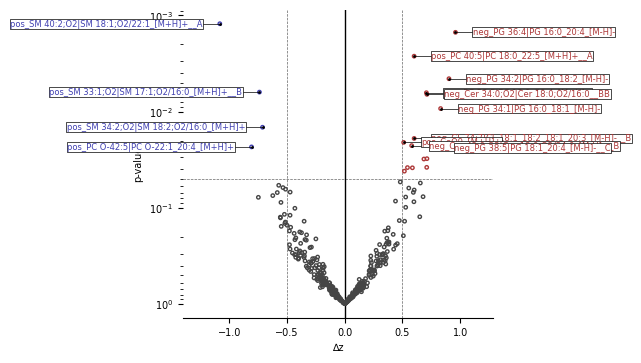

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-1.026088,null,-0.117171,null,-1.456102,-1.695909,-0.666708,-1.43029,-0.247797,-0.193849,-0.469651,0.955736,0.357302,1.52066,0.260954,-0.610372,-0.865169,-1.239476,-1.643506,-0.499413,-0.804387,-0.717376,0.41998,-0.015566,1.633892,0.439267,-0.722465,-0.404761,-0.500751,-0.864926,1.717083,-0.177731,-0.922053,-0.296107,-0.585334,0.28702,…,-0.077692,0.031548,-0.914923,-0.258494,-0.654589,0.460993,-1.400365,0.660105,-1.135166,2.309031,0.687791,-0.684941,-0.144148,-0.064927,-0.832699,0.409253,0.147075,0.381762,-0.095872,2.137214,null,null,1.737035,0.944677,-0.125704,1.122952,0.613295,-0.841942,2.390645,0.004682,-1.065086,0.434039,0.950928,1.076928,0.710044,0.038041,0.694047
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.340335,null,0.218527,null,-1.932322,-2.406405,-0.68671,-0.571188,-0.919682,0.759857,-1.572058,0.960614,-0.119528,2.181545,0.169754,-1.92751,-0.011521,0.430112,-0.226195,0.765619,-1.613844,-0.5874,-0.474094,-0.155141,-1.071227,-0.053454,-0.338196,0.494564,-0.106739,0.382773,0.760043,1.031869,-1.114737,0.564197,0.826685,-1.914357,…,-0.152852,1.22022,0.821289,-1.637335,-0.028234,-0.979288,-0.498128,0.511179,-1.515896,0.658523,0.918499,0.438067,0.714617,0.105111,-0.269862,-0.935576,-0.814874,0.330286,-0.636788,0.94519,null,null,0.685042,1.021064,-0.160527,0.791535,0.917158,0.080528,1.255364,0.154534,1.222365,1.526971,2.502309,-0.212387,0.959211,0.001498,0.256949
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.201948,null,0.807437,null,-2.425376,-1.950197,-0.901433,-0.469489,-0.874007,0.291913,-0.094215,0.806944,-0.816506,1.147944,-0.377379,-1.134662,-0.889379,-0.800744,-0.474485,-0.280492,-1.107187,-1.276204,0.049753,-0.080536,1.342462,0.411602,-0.525378,-0.953551,-0.840016,-0.53714,0.80944,0.249893,-0.399752,-0.336232,0.019916,0.035402,…,0.087302,0.558435,-0.618646,-1.374801,-0.293283,1.155505,-1.346216,0.877172,-1.080304,2.390239,0.475893,0.161114,0.27159,0.216312,-1.009873,-0.022114,-1.458699,0.44636,0.009011,2.172177,null,null,1.524705,1.441831,-0.314636,1.469702,0.440681,-0.948954,2.636316,0.011458,-0.250176,0.833936,1.209136,0.070808,0.79655,0.024037,0.5889
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.860827,null,0.214143,null,-2.285054,-2.733674,-0.90161,0.149202,-0.69581,-0.138814,-0.744371,-0.498259,0.258655,1.043455,0.897362,0.484119,0.832347,-0.810865,1.019337,0.205088,0.09749,-0.059863,0.137274,1.425652,-0.762361,0.035546,-0.94593,-0.801565,-1.078435,-0.614504,0.666295,0.998967,-0.568409,-0.499817,-0.770458,-0.77007,…,-0.251847,1.884311,0.477229,-1.345769,0.173794,-1.647833,-0.431287,-0.272515,-1.373416,0.148059,-0.188654,0.510904,2.020612,-0.363926,-0.360044,-0.220717,-0.113946,0.804216,0.075392,2.515141,null,null,0.124661,0.144209,0.32372,-0.721573,1.534172,0.068811,1.330544,0.230418,0.910563,2.071497,1.864777,1.325967,0.902722,0.004551,0.32433
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",0.649278,null,0.700724,null,-2.122897,null,-0.379281,-1.054205,-0.325795,0.26149,-0.439199,0.322172,2.76

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""pos_SM 34:2;O2|SM 18:2;O2/16:0…",-0.937639,null,-1.081971,null,0.55091,1.094313,-0.544383,0.088746,1.10462,-0.350267,-0.877878,-1.765617,2.502524,0.556313,0.029076,-2.007571,-0.158079,-0.11448,0.290828,1.105793,-0.70794,-0.215718,-0.538314,0.945664,-1.611254,-1.878051,-0.883852,-1.140067,-0.84647,-0.934947,0.295353,0.093994,-1.07946,1.554317,0.791486,0.192729,…,0.544783,0.621257,0.270435,1.848861,1.043835,0.744117,-1.301189,-0.397645,0.201695,1.253746,-0.627496,1.002989,0.559709,0.330906,-0.229451,1.379897,1.650492,1.183369,-0.822692,-0.770238,null,null,-2.207772,-1.488786,-0.584517,0.095584,-1.130708,-0.257467,0.815421,-0.94943,-0.541291,-0.076978,-0.968027,0.021187,-0.713018,0.014554,0.554658
"""pos_SM 33:1;O2|SM 17:1;O2/16:0…",0.937661,null,-1.447156,null,1.548402,1.395582,0.525834,0.171584,1.767521,-0.237558,-0.773187,-1.972775,2.274442,1.596801,-0.18164,-1.159549,0.154445,-0.229402,1.385898,0.727872,-0.519985,0.409457,-1.45008,1.000561,-1.071178,-2.051166,0.008151,-0.626108,0.748042,-0.930657,-0.214571,0.141193,-0.982275,1.314518,1.27547,0.647458,…,0.990747,0.775325,-0.226708,1.88123,1.603735,0.274564,-1.08,-0.803016,-0.096004,0.165264,-1.206447,0.161333,0.932001,-0.012076,0.074243,0.076165,1.450533,0.591841,-1.223821,-0.307324,null,null,-1.668652,-2.014154,-0.014034,-0.297648,-0.950741,0.260687,0.078878,-0.415803,0.080842,-0.827775,-1.130283,-0.648652,-0.739935,0.006274,0.32433
"""pos_SM 40:2;O2|SM 18:1;O2/22:1…",0.970345,null,-1.329058,null,1.652121,0.935363,0.886017,0.735755,2.042047,-0.88764,0.057865,-2.072394,1.686721,1.528247,-0.060278,-1.002918,-0.414336,0.150204,1.223817,0.857427,-0.080357,0.274652,-1.186525,0.735654,-1.390508,-1.64105,-0.329278,-0.848619,0.106047,-0.615394,-0.182578,-0.216951,0.632632,1.016985,1.469386,0.373793,…,-0.272758,-0.244454,0.699895,1.963752,1.42705,1.244911,-0.02442,-0.193641,1.312231,0.449668,-0.375188,1.484729,0.764989,0.200323,0.391396,-0.305128,0.828026,-0.553282,-0.141538,-1.903087,null,null,-1.493064,-2.475641,-1.432773,0.165444,-0.098266,-0.551035,-0.314461,-0.611775,0.083438,-1.932495,-0.609532,-1.778874,-1.083239,0.00122,0.256949
"""pos_PC O-42:5|PC O-22:1_20:4_[…",1.091798,null,0.429372,null,-2.878438,-0.029464,-1.508027,-0.231138,-1.33116,-0.26284,0.208687,-0.258291,-1.001176,0.0213,-0.257877,0.66177,-1.310124,0.744896,-0.375911,-1.8706,-0.268576,-0.517183,0.295484,-0.67006,-1.244778,-0.030952,0.912621,-0.503743,0.258227,0.216417,-0.404223,-0.370007,0.380409,2.069868,0.493401,1.220726,…,-1.432849,-0.43856,0.81706,1.244825,1.179258,0.899507,1.214973,0.911103,0.560933,0.409824,0.329947,2.712752,1.246473,1.412482,0.332589,1.274175,0.574351,-0.19548,1.435892,-0.364305,null,null,-1.610751,-2.807569,-0.338199,-0.198632,-0.078384,0.596322,-1.195202,-1.219916,0.081064,-1.341538,0.825643,-0.958147,-0.808364,0.023307,0.5889


Metabolomics


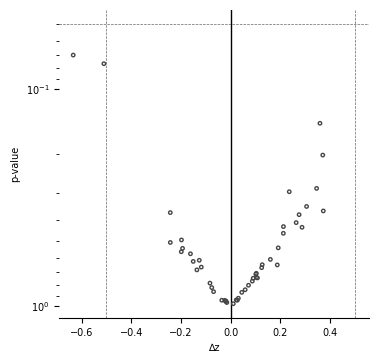

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITD-WT ============
Transcriptomics


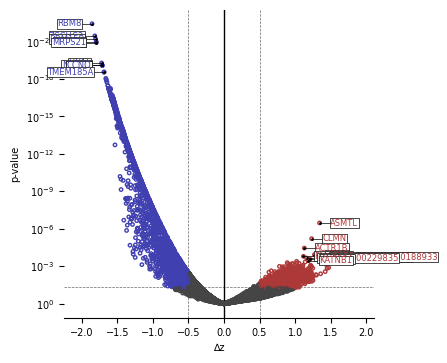

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""STPG1""",null,-1.186596,-0.304697,0.185548,-1.402124,null,-0.855365,-1.011305,null,0.418122,null,-0.753871,0.131383,-0.482262,-0.866472,0.018872,0.347515,-1.233495,-0.622943,-0.669572,-0.639983,-0.551929,1.219551,2.501845,null,1.371261,null,null,null,null,-0.908369,0.051238,-0.144578,-0.341363,-0.195725,null,…,null,null,null,null,null,null,null,null,null,0.356614,null,null,-0.329632,0.911708,-1.182955,0.734175,null,null,1.213515,3.187123,-0.552691,3.407373,-0.014149,null,0.860915,null,null,-0.264368,-1.215442,1.556505,1.099162,null,null,null,0.850534,0.034541,0.160992
"""NIPAL3""",null,-1.317984,0.192503,0.257334,0.163883,null,-1.137842,-0.213776,null,0.10389,null,-0.774729,-0.539199,0.196,-0.572179,-1.128389,3.663419,-1.132751,-0.372426,-0.61864,-1.122437,-0.022744,-0.865084,0.268867,null,-0.48073,null,null,null,null,-1.163887,1.331593,1.192748,0.010165,0.20452,null,…,null,null,null,null,null,null,null,null,null,0.580449,null,null,0.256074,0.766182,-0.723876,-0.471392,null,null,1.948928,2.714284,0.036823,1.684522,0.464917,null,0.920946,null,null,0.692191,-1.499665,1.16699,2.229529,null,null,null,0.937526,0.008313,0.061716
"""LAS1L""",null,-1.414132,2.056287,-0.547507,1.21268,null,1.063911,0.002073,null,0.137922,null,-0.25121,-0.370679,-0.069082,-1.018868,0.418379,1.123109,-0.311795,0.528039,-0.145491,-0.625874,-1.106429,-1.529911,0.851143,null,0.339082,null,null,null,null,1.171032,0.930201,0.813065,0.217684,-0.003241,null,…,null,null,null,null,null,null,null,null,null,0.385464,null,null,0.761727,-0.287433,-0.284628,1.445729,null,null,-0.051286,0.137079,1.296123,1.361295,-0.624964,null,1.713374,null,null,1.7433,-1.93283,1.726143,0.669924,null,null,null,0.701738,0.031658,0.152902
"""CCM1""",null,-1.251109,0.687218,-0.200046,-0.759251,null,-0.124991,0.166197,null,-0.981754,null,-0.722157,0.964736,0.148791,0.630803,-0.832943,3.06397,-0.374375,0.953614,-0.964312,-1.245865,-0.412542,-0.650491,3.509204,null,-0.678559,null,null,null,null,0.824249,0.963651,0.770823,-0.501411,-0.504759,null,…,null,null,null,null,null,null,null,null,null,1.776588,null,null,0.003376,0.123393,1.885182,0.031031,null,null,0.592741,0.664441,-0.267584,0.627202,0.075988,null,0.12313,null,null,0.23467,-0.930188,0.185372,0.624481,null,null,null,0.500665,0.043315,0.184861
"""MAD1L1""",null,-0.734548,-0.159506,-0.081696,-0.957102,null,-0.285437,-0.288532,null,-0.121089,null,0.315638,-0.805838,-0.629183,-0.728715,-0.799434,0.226276,0.256816,-0.968455,-0.973454,-1.325103,-0.555432,-1.456022,1.99256,null,-0.031937,null,null,null,null,0.540332,-0.623442,0.554507,-0.12144,-0.465291,null,…,null,null,null,null,null,null,null,null,null,1.73455,null,null,-0.514857,0.375006,-1.331071,0.729544,null,null,0.965101,1.768985,-0.127292,2.119309,1.219197,null,0.885092,null,null,0.353266,-1.55481,1.144735,1.959282,null,null,null,0.846893,0.015282,0.095447
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HS3ST1""",null,0.54008,0.843263,-0.413471,-0.52166,null,0.130951,0.351496,null,0.221897,null,0.124915,-0.268629,-0.407374,1.144119,-0.491363,6.475086,0.103748,-0.2148,-0.319881,-0.449351,3.050552,-0.52166,-0.464234,null,-0.486102,null,null,null,null,-0.452769,-0.491018,0.228842,-0.48735,0.165088,null,…,null,null,null,null,null,null,null,null,null,-0.476317,null,null,-0.511684,-0.495833,-0.41384,-0.425144,null,null,-0.49884,-0.470555,-0.435313,-0.496168,-0.303073,null,-0.397027,null,null,-0.343945,-0.420451,-0.483404,-0.281489,null,null,null,-0.561901,0.001042,0.011968
"""ST7""",null,0.095873,-0.23427,1.244426,-0.534544,null,-1.254372,1.398096,null,-1.251816,null,-0.995438,-0.440435,-1.188034,0.986908,1.319377,0.046826,1.002271,1.6591,1.537568,0.296701,-0.389627,0.005226,-1.085132,null,-0.037043,null,null,null,null,0.731067,4.32844,0.051993,-0.450925,0.488631,null,…,null,null,null,null,null,null,null,null,null,-1.313115,null,null,-1.209784,0.937399,-1.329152,-0.204158,null,null,-1.252448,-0.329169,-1.270743,0.165676,-0.229985,null,-0.494932,null,null,0.956672,-0.412515,-0.866469,-1.297364,null,null,null,-0.709667,0.007835,0.059218
"""MCUB""",null,1.128381,-0.368409,-0.195295,-0.616939,null,-1.206618,0.54442,null,0.669356,null,-0.603754,0.789856,0.275296,0.073523,-0.904397,2.731958,0.947673,0.216187,2.667612,0.105582,0.360845,-1.087937,-0.955069,null,-0.412485,null,null,null,null,-1.099611,-0.959437,-0.773373,1.954307,-0.024621,null,…,null,null,null,null,null,null,null,null,null,-0.969226,null,null,-1.37507,-1.17715,-1.396172,0.347721,null,null,-1.147618,0.688127,-0.870419,-0.08653,-0.468939,null,-0.826702,null,null,-0.268665,0.512709,0.969592,-0.429227,null,null,null,-0.565775,0.030204,0.148445
"""FBXL3""",null,0.317686,-0.234639,-0.767883,-0.36178,null,0.341588,0.552158,null,1.955463,null,2.043108,1.722742,0.807876,2.312178,0.598024,0.678413,-0.37825,1.162125,-0.303458,1.121888,0.480809,1.087201,0.094533,null,0.595039,null,null,null,null,-0.059929,0.792771,1.223819,0.645572,-0.706204,null,…,null,null,null,null,null,null,null,null,null,-0.25574,null,null,-0.090089,-0.974721,0.339901,-1.652731,null,null,-0.552926,-0.556577,0.459554,-0.041768,-0.700687,null,-1.19701,null,null,-0.464565,-1.040827,-0.566469,0.24588,null,null,null,-0.613771,0.007047,0.055068
"""CRLF1""",null,0.351989,0.113534,-0.897297,-1.087729,null,1.975522,0.007064,null,-0.538876,null,0.355708,-0.122735,0.814188,-0.441676,-0.394477,-0.377738,0.243516,0.188947,-0.574708,0.015338,-0.560367,0.637009,0.2263,null,-0.274081,null,null,null,null,-0.457177,-0.386565,0.673639,-0.040954,-0.471475,null,…,null,null,null,null,null,null,null,null,null,-1.087729,null,null,0.281901,-0.79224,-0.735274,-1.087729,null,null,0.21768,-0.386094,-1.087729,1.537199,-1.087729,null,-0.828466,null,null,-1.087729,-1.087729,-0.868882,-0.826029,null,null,null,-0.77728,0.002853,0.027662
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Proteomics


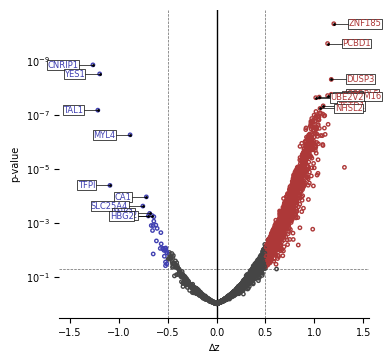

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAGAB""",-0.708106,1.132425,0.068844,0.034366,null,null,null,null,null,null,-2.7433,-2.700721,-0.763755,-1.084591,-0.357764,-0.927467,-2.110001,-1.207061,-1.49827,-0.514193,-1.087039,-0.478268,0.208059,0.043747,-0.301742,0.00357,-0.154494,-0.537628,-0.757403,0.222237,-0.329787,1.006199,-0.735982,-1.417525,0.049012,0.130241,…,-1.348256,1.54287,0.846087,-0.550761,-0.375286,-0.425321,-0.09187,1.61893,0.43149,-1.755894,1.753049,-0.101992,0.54881,-0.165869,-0.651486,2.233457,-0.916895,0.826024,-0.048814,0.403498,0.064374,0.375175,0.506786,1.160916,1.18819,0.087584,-0.657757,0.362311,0.520096,0.538105,-0.23942,0.617708,0.98318,1.298642,0.544867,0.006828,0.022431
"""AAK1""",-0.356262,0.897401,-0.135561,-0.179039,null,null,null,null,null,null,-1.865301,-2.221313,-2.252905,-0.971811,-0.566383,-2.555215,-1.566386,-1.472862,-1.428751,-0.251515,-1.122472,-0.55867,-0.946317,1.161749,-0.068856,-1.370841,0.001744,-0.318035,-0.901479,0.45259,-0.515486,-0.267868,-1.047371,-0.805852,-0.309174,-0.020273,…,-1.445279,2.026712,1.194158,0.349041,-0.168441,-1.460519,0.261064,1.032859,0.7665,-1.046001,1.839864,0.506933,0.841836,0.607959,-0.493419,1.595647,-0.194606,0.344134,-0.401931,0.636151,0.771694,0.444826,0.952661,1.095653,0.94028,-0.182845,0.142405,-0.748089,1.517975,1.215666,0.760923,0.143156,0.884867,1.071304,0.78804,0.000065,0.001105
"""AAMDC""",-0.39484,-0.88947,0.565278,-0.251074,null,null,null,null,null,null,-1.200834,-2.074872,-1.499752,-0.227641,-1.28955,-1.759313,-1.50599,-0.574365,-1.779866,0.13184,-1.85518,-0.248432,-0.569255,0.457462,0.360748,0.44429,-1.687616,-0.833849,-0.338583,-0.490142,0.183781,-0.166948,-0.918592,-2.544746,0.664687,-0.78754,…,-1.801003,1.962686,-0.196941,0.437956,-0.603779,-0.946227,-0.00615,1.99621,1.705934,-0.017515,2.250375,0.472292,0.478488,0.969966,0.325055,1.630127,-0.165613,0.181929,-0.058365,0.482228,1.153881,0.177902,0.113738,1.584204,1.733833,0.813116,-0.60634,0.226108,0.665857,1.521839,1.159663,1.095385,0.228144,0.229987,0.959257,0.000002,0.000115
"""AAMP""",-0.82759,-1.239233,0.931315,-0.866667,null,null,null,null,null,null,-2.519694,-2.405763,0.74778,-1.412918,-1.139313,-2.117626,-1.437857,-0.500788,-1.89303,0.657111,-0.933762,-0.637095,-0.354358,0.950844,-1.117727,-0.811788,-0.14939,-0.141595,-0.64869,0.476334,-0.123365,0.839284,-0.322767,-1.892692,0.205648,-0.626972,…,-1.584733,1.840514,0.167314,-0.457809,-0.858437,-0.718365,0.554243,1.484593,1.213781,-0.154158,1.356479,0.925216,-0.197664,-0.369361,-0.311801,2.01541,-0.417614,0.008081,0.243139,0.625921,0.779547,0.028932,1.006786,1.209981,1.449969,0.691289,-0.835727,0.020962,0.363907,0.885925,0.68529,0.440842,0.708539,1.314687,0.717315,0.000222,0.002298
"""AARS""",-1.949094,0.800338,0.052374,-0.603196,null,null,null,null,null,null,-2.117341,-2.575906,-1.249683,-0.633433,-0.929014,-1.499767,-1.31693,-0.013138,-1.358157,1.132679,-0.824551,-0.498734,-0.418898,0.501265,0.356257,-0.278847,-0.180314,-0.220745,-0.589924,1.142098,0.036809,0.085558,-0.876396

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCC4""",-1.937505,1.212597,-0.683516,-0.751112,null,null,null,null,null,null,-1.755185,-0.572663,-1.735648,0.196776,-0.621527,-0.312578,-1.144877,-1.508218,-1.53171,-0.307957,-0.240246,1.022133,0.114275,-0.353159,-0.034844,-0.034749,0.764047,1.305314,-0.664534,1.241547,0.747815,0.765801,-1.211192,0.829811,1.645992,0.45996,…,-0.264753,0.650435,-0.063899,-0.708534,-1.223115,-1.508812,-0.739839,0.388169,0.498375,-1.89422,1.412076,-0.457482,-0.754489,-0.168066,-0.975083,0.932213,-0.85401,-0.761866,0.583898,-0.373292,1.15119,-1.017509,0.054145,1.685394,0.543586,-2.078994,-0.651098,-0.314363,0.054773,-0.587123,-0.767091,-0.983045,-1.388953,-1.429683,-0.536661,0.010499,0.030089
"""ANK1""",-1.107386,0.394373,-1.839575,-0.738656,null,null,null,null,null,null,-2.298135,-0.70503,2.342767,-0.981966,1.203443,0.058104,-0.031558,-0.076133,-1.006634,-0.881716,0.70583,-0.23892,-0.175442,-0.517268,1.415769,-0.484312,-0.607642,1.135598,0.891546,0.114976,1.038178,1.568043,-0.918502,-0.677892,-0.25967,1.442172,…,-1.855806,-0.311059,-0.665425,-0.729698,-0.516145,-1.594089,-1.006531,0.066729,-0.283011,-2.062761,-0.189748,-1.127612,0.125571,-0.264368,-1.440251,0.242458,-0.90041,-1.435477,0.611575,-0.510116,0.915059,-0.151971,0.268069,0.33825,-0.099769,-1.099957,-0.951739,-1.331977,1.122616,-0.755065,-0.635056,0.865339,-1.441413,-0.013905,-0.683573,0.000444,0.003554
"""APOB""",-0.872665,2.577582,-1.26893,-0.327037,null,null,null,null,null,null,-1.210449,-1.031712,0.463138,0.766876,0.398585,-1.846713,-0.572898,-0.654212,-2.095685,0.260474,-0.372785,1.308109,-0.485179,-1.819749,0.445721,-0.315578,-0.312573,1.511855,-0.315467,0.305199,-0.763851,0.22783,1.221561,1.721052,0.820454,0.868732,…,-1.096169,1.508785,-0.396989,-0.617594,-1.877302,-1.81173,-1.520048,0.480285,-0.532956,-2.074547,0.937957,0.43665,-0.385694,0.360489,-1.95856,2.000587,-1.954147,-0.635086,-0.423057,0.117484,0.350203,-0.010018,-0.722926,-0.992042,-0.247224,-1.327795,0.073354,-0.730338,1.035733,0.290265,-1.191102,0.168633,-0.998533,0.055448,-0.57529,0.00886,0.027005
"""APOE""",-0.986942,1.626922,-0.398285,-0.933407,null,null,null,null,null,null,-2.749161,-0.62506,0.591387,-0.177007,2.925007,-1.539404,-0.276904,-0.760145,-2.024384,0.639702,-0.08167,-0.277383,-0.912333,-0.713057,0.305408,0.564464,-0.426185,1.401684,-0.165259,-0.195286,-0.592388,0.756503,2.075427,0.938928,0.549781,0.551824,…,-0.884287,0.458256,0.069137,-0.901316,-0.69091,-0.57204,-0.760156,0.247615,-0.804117,-2.275742,0.324464,-0.728025,-0.067361,0.014123,-0.31348,1.833408,-1.273485,-0.977585,0.300672,-1.031385,0.243465,-0.780947,-0.169498,1.10822,-0.33001,-1.428616,-0.664644,-0.81146,-0.218647,-0.236362,-1.251922,-0.446757,-0.658188,-0.498898,-0.607289,0.001602,0.008316
"""CA1""",-0.73497,-0.925513,-1.189426,1.437325,null,null,null,null,null,null,-1.839544,-1.339819,1.231625,-0.608929,0.323913,-0.410611,-0.705866,-0.949369,-1.709426,-0.913401,-0.107734,-0.154118,-0.150022,-0.613939,1.007883,-0.251274,-0.875932,0.489824,1.2

Phosphoproteomics


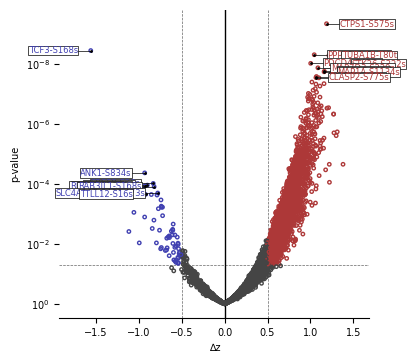

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S678s""",-0.547599,null,0.117055,null,null,null,null,null,null,null,-1.655658,-1.566279,null,null,0.043866,-2.192577,-1.913459,-0.603539,-0.493688,-0.443221,null,-0.523837,-1.113657,0.454175,null,null,0.625324,-0.906332,-0.704424,0.371951,null,-0.686068,-1.590654,-0.333305,-0.291732,0.549134,…,null,1.518629,0.055516,0.8955,0.612247,-0.707599,0.76163,null,null,-0.482434,1.941214,0.344694,0.677982,-0.758403,0.605697,2.35478,0.533262,0.616687,-0.688642,0.711716,0.426039,0.618178,null,0.741288,null,-0.332263,0.311784,-0.825338,1.807857,1.426594,null,0.049584,0.462209,null,0.769654,0.000546,0.0056
"""AAK1-T606t""",-0.451982,0.005806,0.751357,0.005246,null,null,null,null,null,null,-2.046462,-1.654594,-2.543631,-0.938434,-0.757365,-2.22511,-1.665265,-1.040115,-0.706727,0.015379,-1.002194,-0.546467,-0.969017,1.250797,-0.818927,-1.950525,0.228491,-1.473729,-1.326534,0.223733,-0.302877,-0.477618,-1.553739,0.179956,0.670519,0.356703,…,-1.077114,0.896067,0.442471,0.136556,-0.238171,-0.947114,0.311174,0.804673,0.603531,-0.905621,1.061389,0.716298,0.571606,0.421416,-0.300445,1.867873,-0.770588,-0.790334,-0.293237,0.995866,0.393501,0.601709,0.851291,1.580303,1.22953,0.215218,-0.085744,0.02268,0.96415,1.132188,0.439231,0.41146,1.410296,0.65006,0.657869,0.000445,0.004895
"""AAK1-T620t""",-0.142383,0.498486,0.912615,0.096232,null,null,null,null,null,null,-1.029246,-1.213962,-3.336647,0.084595,0.197453,-2.001897,-2.063483,-0.540985,-1.123733,0.296941,-0.966769,-0.219763,-1.125905,0.268322,-0.405536,-0.81945,0.285008,-0.676255,-0.815417,0.345246,-0.70867,-0.322552,-1.442015,-1.328703,-0.050049,-0.270495,…,-1.474461,1.726354,0.007149,-0.444229,0.3376,-1.364228,0.16974,0.897504,0.788611,0.325305,1.795286,-0.489332,1.078278,null,0.547549,2.598889,-0.17177,0.470367,-0.250768,0.141989,null,0.225983,1.713328,0.451143,0.895384,-0.135226,0.526563,0.135811,1.8409,1.219692,1.295796,0.5866,0.884922,1.531305,0.921243,0.000008,0.000441
"""AAK1-T620tS624s""",-2.649377,0.370519,0.609985,0.14999,null,null,null,null,null,null,-1.770215,-1.542671,-2.502181,-0.52627,-0.605966,-2.571249,0.443895,-0.843962,-0.227757,-0.364894,-1.206034,-0.070211,-0.762081,0.63326,-1.131723,-1.203179,-0.048159,-0.99375,-1.242639,0.129146,-0.224562,0.036032,-1.610516,-0.050093,0.523164,0.456839,…,-1.179573,1.689682,0.674526,-0.501284,-1.24816,-1.01898,0.231458,0.854247,0.734096,-0.458794,0.915564,0.819272,0.6754,0.305982,0.901862,1.899206,-0.888787,0.33785,-0.149477,0.580619,1.08394,-0.28448,null,1.007353,null,0.496233,-0.27592,0.500837,0.869024,1.20903,1.022646,0.097226,0.798247,0.460256,0.63549,0.001055,0.008463
"""ABCE1-S582s""",null,null,null,null,null,null,null,null,null,null,null,-2.075186,-2.410627,-1.687628,null,null,null,-0.967575,-0.736278,null,-0.917759,-0.78842,null,-0.875672,-1.377399,-0.667122,null,-0.491191,null,0.140125,-1.84602,-0.425657,-1.214035,-2.717017,-0.050594,-0.427875,…,1.704789,0.754557,null,null,-0.454733,-0.096053,0.170401,null,null,0.567531,null,null,0

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",null,-1.767842,-0.509142,-2.61343,null,null,null,null,null,null,-0.446184,-0.134901,-3.351645,0.699149,-0.144802,-1.340499,0.829288,0.169233,-0.165453,0.187036,-0.477607,0.229668,0.619828,0.491949,0.401212,1.047824,0.661543,0.810748,-0.185432,1.076655,1.725241,0.855646,0.897633,1.17413,0.361683,0.81599,…,0.630837,0.505563,null,-2.768347,-1.658109,-0.13476,-0.154124,0.07696,0.437787,-0.37359,null,0.543002,-0.483323,-1.864665,-0.199308,-0.238038,-0.3865,-0.754427,-2.058311,null,0.152482,-2.34878,null,-0.334861,-0.302586,0.130535,-2.768347,0.051786,-0.728608,0.200248,-0.328406,-1.993763,0.09785,-0.245218,-0.898325,0.000112,0.002038
"""ADD2-S701s""",null,-1.15901,-1.174693,-0.514025,null,null,null,null,null,null,-1.832424,-0.968959,1.318421,-0.712892,0.546086,0.176935,0.252533,-0.34633,-0.337508,-1.662048,1.026078,0.009777,-0.11593,0.96514,1.462283,-0.854795,-0.502695,0.876083,0.720775,0.00226,1.434043,2.132679,-0.548913,-0.823287,-0.698236,2.244263,…,-2.06918,-2.281407,-1.890302,-0.81798,-2.140869,-0.144894,1.17956,0.816339,0.199267,-1.35995,-0.084193,-0.119725,0.825229,-0.421819,-0.516816,-0.026082,-1.643203,-1.316622,0.553577,-0.850974,1.264576,-0.468942,0.119739,-0.200753,-0.208766,-0.617329,-1.15026,-0.606192,0.890621,0.011813,0.566859,0.317035,-1.008228,-0.661216,-0.541579,0.009621,0.036922
"""ANK1-S1686s""",-0.592963,0.055264,0.492025,-0.55301,null,null,null,null,null,null,-1.897376,-0.80818,1.508215,-1.467873,0.235744,0.055448,-0.443813,-1.106918,-0.569493,-1.204255,0.063698,0.04027,-0.666107,-0.871378,0.317287,-1.235414,-0.570423,-0.100393,0.06327,-0.209249,1.582329,2.530236,-0.462801,-1.301369,0.325483,1.818002,…,-0.649903,-1.070571,-0.288212,-0.782811,-1.198303,-1.839793,-0.982196,0.49329,0.324545,-1.753187,-0.376929,-1.426124,0.280895,-0.658817,-1.330961,-0.143632,-1.892219,null,0.137805,-0.332937,1.094167,0.107718,0.462643,0.021843,-0.314863,-0.466664,null,0.100877,1.072463,-0.907277,-0.122132,0.591985,-0.67424,0.326387,-0.550142,0.006048,0.026813
"""ANK1-S834s""",-1.464713,0.216231,-0.642096,-0.04711,null,null,null,null,null,null,-1.32981,-0.331451,2.695311,-0.482787,1.509283,0.150453,0.587562,0.275278,-0.597243,-0.484413,0.670543,0.464755,0.283373,-0.048807,0.337932,0.219619,-0.294994,1.198824,1.035729,0.602265,1.282692,1.288834,-1.100243,-0.309287,0.180913,1.824029,…,-1.277016,null,-1.58185,-0.928999,-0.60321,-1.103572,-0.518038,-0.058919,-0.698815,-1.652658,-2.858635,-1.906024,0.534731,0.667082,-1.109304,-1.124116,-0.916002,null,null,-1.496083,0.985093,-0.434987,-0.110917,0.184999,-1.678229,-0.877402,-0.764938,-0.166453,1.511131,null,-0.364455,0.583918,-1.166223,-0.983346,-0.929339,0.000044,0.001113
"""ANK1-S856s""",null,0.124941,null,null,null,null,null,null,null,null,-2.9853,-1.02737,-1.062993,-1.275634,-0.646486,-0.18736,-1.201995,-0.678994,-0.283685,-0.346856,-0.129151,-0.12958,-0.542414,-0.657698,0.065267,-0.301192,-0.746773,0.32551,-0.086269,0.199219,1.600649,2.414689,-0.773721,-0.204332,-0.1172

Acetylomics


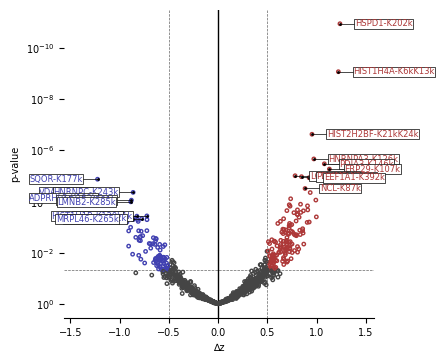

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAT1-K202k""",null,-1.059181,-0.349373,-1.68411,null,null,null,null,null,null,0.103883,0.037531,-0.174657,0.018005,-0.735274,-1.143261,-1.097764,-0.972858,-0.754941,-0.80157,1.167516,-2.007423,0.558454,-0.525941,0.555086,0.336238,-1.320509,-0.485872,-0.133734,-1.063094,0.451677,0.864245,-1.331917,-0.532232,0.287081,-1.150315,…,null,0.048903,null,-1.497564,-2.644823,1.655066,0.875303,1.090764,0.78203,1.291301,0.720469,1.841612,1.212951,0.938728,1.241866,0.063827,2.130758,1.692375,-1.143126,-0.61147,0.144975,0.106733,0.74099,0.222391,0.399237,-0.723398,1.040396,0.776433,-0.234647,0.203737,1.533811,-0.279418,-1.383076,-0.807217,0.541538,0.019786,0.100541
"""ACTA1-K193k""",0.754989,1.169658,-0.597992,-1.009768,null,null,null,null,null,null,-0.202488,-0.332802,-1.10558,-0.109276,-0.260933,-1.713633,-1.536562,-0.139914,-0.672293,0.316746,0.209743,0.60262,0.190358,-0.978365,0.621491,-0.082036,0.496151,-0.107724,-0.339699,1.510085,-0.245821,-1.20709,0.322888,-1.169701,-0.919442,0.106684,…,-1.643968,0.000868,0.777169,2.83798,null,2.162937,null,2.847624,-1.424438,null,1.53611,-0.50445,-0.480341,-1.086916,0.996076,-1.09656,null,0.225561,0.022089,1.169658,-0.851615,2.355806,-0.54206,-0.576776,0.408788,-0.113889,0.827315,null,-1.655882,-0.382942,2.153293,null,0.130821,0.913975,0.558301,0.044367,0.170714
"""AFF1-K582k""",0.253726,null,1.198071,1.125275,null,null,null,null,null,null,-1.294573,-0.709105,null,-0.373802,0.445979,-0.314874,-1.244157,0.462343,-0.499304,-0.004605,-0.869979,-0.363706,-0.510044,0.538071,-1.677271,-0.962346,0.410531,-0.351693,-0.478645,-0.063921,0.285678,-0.214002,0.349604,-0.088762,1.159126,-2.13617,…,1.665342,null,0.396425,2.304958,1.249925,-1.584106,-0.296726,0.156998,1.047494,1.344658,null,0.918856,-0.143158,null,0.430291,1.896108,0.008416,null,null,1.666753,null,null,0.597759,0.524365,0.712436,0.589781,-0.148144,0.040326,null,null,-1.065564,0.468622,1.158316,-0.117744,0.699513,0.00258,0.028719
"""AHNAK-K1191k""",null,null,null,null,null,null,null,null,null,null,-0.669276,-0.7148,null,-1.342356,-0.407452,-1.429902,null,0.42856,-0.754182,-1.719865,0.054017,0.047904,0.487919,-0.877335,-1.945741,-1.122845,0.019592,-0.834628,-0.588376,0.906606,-0.338974,-1.425777,-1.08647,-1.035577,0.184309,-0.251363,…,-0.49457,null,null,0.998966,null,null,-0.177668,2.713209,null,null,0.757536,-0.5268,null,0.558379,1.564397,-0.162411,1.450413,1.178468,0.530287,null,-0.085225,1.842625,null,-0.254854,null,null,null,0.689326,-1.325583,0.729713,null,0.511888,1.488976,0.293991,0.859051,0.001169,0.019517
"""AIF1-K154k""",null,1.11538,null,1.734565,null,null,null,null,null,null,null,null,null,-1.660229,0.715202,null,-1.551065,0.854775,null,-0.070828,-0.752395,0.136955,-2.651754,-1.424585,-0.672275,-0.448174,0.739432,-0.293855,-0.037132,0.838957,0.260745,-0.858036,-0.819853,-0.680359,0.200732,-1.958853,…,-0.576085,null,null,null,null,null,-0.116607,0.951328,0.019996,0.883664,-0.097457,0.798765,0.215965,1.402631,1.536681,0.73174,-0.091074,nul

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAD9-K202k""",null,-0.457732,-1.772648,-0.329286,null,null,null,null,null,null,null,0.670564,-0.759155,-0.888032,null,null,null,-1.413786,-1.566832,null,1.412815,-0.151937,null,1.147465,0.468273,1.332153,null,0.765439,null,0.909527,1.233685,-0.163419,0.674751,0.845686,0.804649,-0.015456,…,0.262518,-0.375632,null,-1.221786,-0.611337,null,-0.060079,0.462577,-0.146813,-0.796723,0.397692,-0.837773,0.575133,-1.350232,0.065321,0.049431,-0.812613,-1.028455,1.431881,null,-0.909279,-1.032428,-1.600503,0.898234,1.392155,0.246735,0.057376,null,-0.265725,-2.368531,0.016327,null,-0.867239,-0.640918,-0.55038,0.019048,0.098942
"""ADPRHL2-K109k""",null,-1.028506,-0.442246,-0.617631,null,null,null,null,null,null,null,null,0.161647,1.780536,null,null,0.494545,-1.012449,1.342971,0.423205,1.407889,null,0.909847,0.559743,1.237322,1.564768,null,0.038868,null,null,0.056582,0.251899,null,1.739545,0.363324,null,…,1.176828,null,-1.238377,-3.409018,null,null,0.079969,-0.731435,-0.005753,-0.950667,0.532227,-1.086639,null,-1.529044,-0.739613,-0.384113,null,null,null,null,-0.440275,-2.187232,-0.263905,-0.492497,0.453402,-1.167435,-0.405789,null,-1.822667,null,-0.040239,null,0.285464,0.314625,-1.072953,0.000073,0.00457
"""ANXA6-K299k""",-0.233602,null,-1.077827,1.628583,null,null,null,null,null,null,-0.471446,1.392349,1.647479,0.439651,2.023142,-0.493509,0.369209,0.595883,0.20671,0.66039,1.769932,2.03039,1.061322,-1.154732,2.495126,1.780669,1.374482,-0.448174,-0.479629,1.520058,-0.287666,-1.354646,-1.70166,-0.613795,2.301725,-0.466018,…,-0.389378,0.507824,-0.95342,-0.033458,null,1.137501,null,-1.721691,-1.6453,null,null,-0.025819,-1.765343,-1.590736,null,-0.81919,null,-0.230437,-1.17277,0.675883,null,-0.467794,-1.01235,null,-0.167142,0.088767,-0.859568,0.035293,null,-0.552915,-0.012724,null,-0.380457,-0.139995,-0.656391,0.002628,0.028912
"""ANXA6-K314k""",0.486539,-0.945937,null,0.51732,null,null,null,null,null,null,0.870379,0.136596,0.7656,0.649635,1.403037,1.372754,-0.231422,1.444124,-0.542118,-0.066329,1.560255,1.806516,0.51339,null,1.962899,0.508703,1.541965,0.590999,-0.471998,0.254083,0.693671,-1.89221,-0.380902,-0.337224,0.971272,1.296719,…,0.608753,0.291202,-0.283446,0.32435,null,-0.170506,-1.247822,0.98613,-2.849591,null,null,-1.205203,0.326718,-1.642049,-0.724554,-0.648787,1.542546,-0.762438,-1.831468,-0.021339,-0.53632,null,-0.088819,-0.427878,-0.839389,null,0.166896,null,-0.042648,-1.890661,-0.097106,null,-0.43302,0.056672,-0.660922,0.004499,0.039488
"""BCAP31-K243k""",null,null,null,null,null,null,null,null,null,null,-0.461632,1.060466,null,null,1.633354,1.350777,0.75308,0.438367,null,null,0.933939,null,-0.070495,-0.464935,null,null,-0.598713,1.116329,-0.208694,1.268104,-1.167992,null,0.277856,0.461139,0.336214,0.925655,…,-0.197605,-2.345139,null,0.371974,null,null,0.188145,2.220939,-1.086799,-0.528978,-0.450157,-2.321419,null,-0.395364,null,-0.86146,2.315819,null,null,-1.229118,-1.764002,0.587825,-1.446155,-0.31353,-1.977481,null,null,null,-0.8

Lipidomics


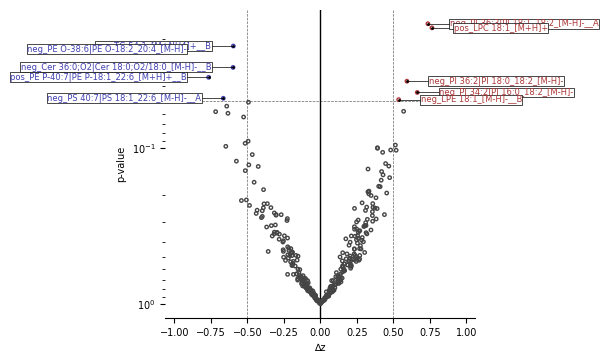

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 18:1_[M-H]-__B""",0.504523,null,-1.133172,null,0.026614,2.757028,-0.087476,0.090199,-0.553388,-0.904913,-1.353866,-0.655414,1.781227,-1.842453,-1.554884,1.120992,-1.594637,-0.325909,-0.011333,-0.776898,-0.256387,-0.876571,-1.559713,0.022791,-0.343208,0.318257,-1.079519,-0.766468,0.326327,-0.794016,-0.821279,1.970553,0.077874,-0.729678,-1.649533,-0.856838,…,null,null,0.082083,null,null,null,null,1.93833,1.030463,0.431143,-0.055152,0.549384,-0.050125,0.506733,null,-0.819264,0.834661,null,null,2.191715,null,null,-0.405269,null,null,null,null,null,null,null,0.204601,-0.214195,null,null,0.536196,0.048831,0.984076
"""neg_PI 34:2|PI 16:0_18:2_[M-H]…",0.049814,null,-0.054362,null,-2.536825,0.036434,-0.934539,-0.17039,-0.975754,-0.916451,0.877402,-0.478854,0.493516,-1.10913,0.117393,1.582106,-0.039247,-0.855705,-1.288639,0.065015,0.436955,0.682323,-0.465612,0.257396,1.354363,-0.754214,-1.464235,-1.030118,-0.11322,-1.280554,-0.387625,-0.985912,-1.699371,-0.621183,-1.232777,1.814852,…,null,null,-0.237788,null,null,null,null,2.398198,2.185888,-0.365962,0.968287,0.502178,-0.28491,-0.883284,null,-1.110182,0.819371,null,null,0.854012,null,null,1.548137,null,null,null,null,null,null,null,0.418863,0.889617,null,null,0.663444,0.043893,0.984076
"""neg_PI 36:3|PI 18:1_18:2_[M-H]…",-0.786174,null,-0.087175,null,-3.655397,-2.470057,-0.009804,-0.081887,-1.496073,-0.547523,1.150833,-0.393465,-1.443,-1.067175,0.189342,0.261003,0.478677,0.402994,-1.574322,-0.106109,-0.651809,0.079271,0.533632,0.580908,1.119916,0.084911,-0.626518,0.191287,-0.89338,0.063211,0.09602,-1.662547,-1.786809,-0.667038,-0.619004,2.697849,…,null,null,0.462395,null,null,null,null,2.129521,1.398129,-0.625971,0.440797,0.102511,-0.071957,-1.106616,null,0.157137,0.849488,null,null,1.616233,null,null,1.610788,null,null,null,null,null,null,null,1.508493,0.076827,null,null,0.736258,0.015888,0.984076
"""neg_PI 36:2|PI 18:0_18:2_[M-H]…",-0.928997,null,0.370919,null,-3.117114,-1.125579,-1.100391,0.007905,-1.419597,0.102693,0.361443,-0.692657,-0.080866,-1.377533,0.785608,0.961602,1.529237,0.200659,-0.747123,0.622004,-0.395013,0.683566,-0.845145,-0.150024,0.737555,-0.319888,-0.482849,-0.363542,-0.70079,-0.581859,-1.618919,-0.606352,-1.122593,0.445083,-0.74215,1.397538,…,null,null,-0.530491,null,null,null,null,1.929709,0.68272,1.440624,1.469265,0.565787,0.201959,-0.647044,null,-0.977114,0.016572,null,null,1.129425,null,null,1.313093,null,null,null,null,null,null,null,-0.042276,0.327867,null,null,0.592613,0.037181,0.984076
"""pos_LPC 18:1_[M+H]+""",-0.222232,null,-0.785251,null,1.40917,1.640263,0.039975,0.271184,-0.191767,-1.33227,0.666787,-0.508897,2.869688,-0.148947,-2.353153,1.943391,-1.698393,0.08564,0.90619,-0.607299,-0.049241,-1.494481,-0.585978,-0.897521,-1.182936,-0.447384,-1.345413,-1.224076,-0.30452,-0.915805,-1.33917,1.36658,-0.185315,-0.589286,-1.296151,-0.683663,…,null,null,0.421309,null,null,null,null,1.087742,0.903266,-0.499992,-0.538835,1.516584,0.793697,0.209149,null,0.8

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PS 40:7|PS 18:1_22:6_[M-H]…",-0.014332,null,-1.09039,null,2.859841,1.329301,0.031693,-1.293961,1.797777,0.457113,-0.507545,-0.771538,0.341583,-0.515301,0.187065,-0.093345,-0.87394,-0.151201,-1.322621,0.353049,-0.186361,-0.612666,-0.2063,-0.797014,0.243003,-0.122016,0.013409,-0.203967,-0.492098,0.494101,1.311994,0.031915,-0.612596,0.61732,0.067296,-0.816223,…,null,null,-0.499768,null,null,null,null,-0.83632,-1.84603,-0.399043,0.404521,1.212198,1.111882,-1.264845,null,-0.555489,-1.242636,null,null,-2.673767,null,null,-0.608181,null,null,null,null,null,null,null,0.471599,-0.995546,null,null,-0.665081,0.047852,0.984076
"""neg_PE O-38:6|PE O-18:2_20:4_[…",0.230584,null,-0.726485,null,0.801897,0.761403,-0.114026,-0.733174,0.014873,-0.367712,-0.881536,0.657606,-1.900785,0.368597,0.916786,0.159032,-0.099212,-0.603238,0.730485,-1.231318,-0.294753,-0.113002,0.842984,2.505671,-0.072133,0.155541,1.991292,1.212378,1.468148,-0.129575,-0.453252,-0.559775,1.519425,1.397008,1.296594,-1.522305,…,null,null,-0.780915,null,null,null,null,-2.467412,-1.968947,0.087773,0.608108,-0.917115,-0.060617,0.744363,null,0.494263,0.162118,null,null,-1.873521,null,null,-1.299358,null,null,null,null,null,null,null,-1.639328,0.01549,null,null,-0.766174,0.023226,0.984076
"""neg_Cer 36:0;O2|Cer 18:0;O2/18…",0.318988,null,0.588891,null,-1.510206,-1.372654,-0.170085,-1.068682,-0.2782,-1.615615,0.652849,-0.340918,-1.297315,-0.544643,-0.929382,0.329235,-0.92186,-1.467238,-0.900844,-0.157657,0.63767,0.236804,1.512549,1.218279,0.15238,-0.127382,-1.280594,0.545773,0.382268,-0.518637,0.37731,0.062115,0.876078,1.448917,-0.892946,-0.028384,…,null,null,-0.302875,null,null,null,null,-1.656509,-0.664614,0.951124,-0.758991,-0.620586,-0.468536,-0.175365,null,-0.822906,0.293997,null,null,-0.208849,null,null,-1.922561,null,null,null,null,null,null,null,-1.462743,0.875717,null,null,-0.598092,0.030316,0.984076
"""pos_PE P-40:7|PE P-18:1_22:6_[…",1.071952,null,-0.186631,null,1.678948,0.555071,-0.445196,-1.439025,0.387527,0.420292,0.177009,-0.443114,-2.038369,0.08807,0.583703,0.710475,-0.822492,0.106369,-0.091663,-0.359243,-0.215787,-0.678097,0.587396,1.178695,-0.598988,0.616735,0.784634,0.566166,0.858912,0.663369,0.563622,-2.130253,0.975294,0.941735,0.91948,-0.741601,…,null,null,-0.771461,null,null,null,null,-1.282626,-0.820669,-0.253816,1.096832,0.317137,0.886776,-2.564903,null,0.262083,-0.243607,null,null,-3.138698,null,null,-0.659436,null,null,null,null,null,null,null,-1.003311,-0.708257,null,null,-0.765215,0.035115,0.984076
"""pos_TG 54:1_[M+NH4]+__B""",0.314344,null,-0.66099,null,0.066129,0.56725,-0.275413,0.039752,-0.881167,0.132158,-0.304302,1.365515,-0.260791,-1.253268,1.370948,-1.06329,1.790671,-0.054596,0.26343,0.164033,1.240714,-0.134988,-0.548841,1.789687,2.050609,1.377715,-1.058172,1.105919,-0.334824,0.473948,0.073995,2.318216,1.403177,0.405447,0.133887,0.221188,…,null,null,0.00181,null,null,null,null,-1.238675,-0.710553,1.105577,-0.576308,0.053481,-1.222487,-0.357792,

Metabolomics


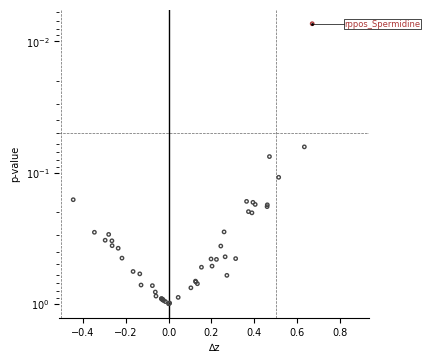

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Spermidine""",-0.835895,null,-1.689069,null,-0.537635,-1.723292,-1.073135,-1.648828,0.097871,-1.913888,-1.82593,-1.792605,-1.864783,0.19292,-1.997337,0.457413,-0.627966,-0.213792,-1.935452,-0.411242,0.307323,0.237404,-1.301468,1.151233,0.385513,0.457735,-1.731067,0.540703,-1.440764,0.451063,0.403354,-0.143741,-0.034689,-1.98302,-0.442385,-0.081902,…,null,null,0.703675,null,null,null,null,0.150816,-0.99858,1.308339,1.262906,0.544865,0.342272,1.838884,null,0.534587,0.327896,null,null,0.378818,null,null,1.113489,null,null,null,null,null,null,null,0.735812,-0.45696,null,null,0.670713,0.00732,0.358681


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,16-01109-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITDxNPM1-WT ============
Transcriptomics


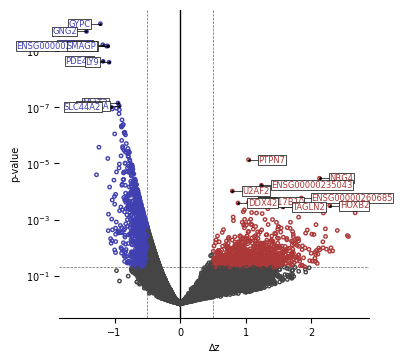

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CFH""",null,-0.32883,-0.503599,-0.407937,-0.526328,null,-0.501488,-0.449388,null,-0.481821,null,-0.452197,-0.317656,-0.503194,-0.48791,-0.402652,0.153041,-0.520931,-0.493545,-0.296135,-0.305689,-0.466458,-0.489032,-0.505017,null,-0.506534,null,null,null,null,0.066802,-0.221191,-0.485859,2.035743,-0.517999,null,…,-0.502221,0.458896,null,-0.476366,-0.49484,null,-0.513764,-0.466868,null,null,null,-0.526328,-0.207197,-0.371975,0.052549,-0.257074,-0.484877,-0.502142,null,-0.526328,-0.460673,3.690437,-0.327168,null,null,0.81461,0.693017,3.679044,null,-0.419752,2.677158,-0.222868,null,2.618249,1.606442,0.036459,0.333714
"""FUCA2""",null,0.213553,-0.764967,0.071093,-0.940642,null,-1.499777,-0.489264,null,-1.845033,null,-0.805703,-1.536435,-1.373133,-1.128104,-0.85072,-1.208112,1.476065,0.165446,0.782369,1.137211,-0.395128,-0.76456,-1.167495,null,0.188494,null,null,null,null,-0.039304,0.039208,-0.775646,0.289153,0.877803,null,…,0.303491,0.901387,null,0.268734,-1.737592,null,0.956691,-1.37243,null,null,null,0.806107,1.245769,-0.938732,-0.078582,2.192875,0.713013,1.132675,null,2.033421,0.688388,-1.077076,-0.624171,null,null,-0.311296,0.926975,0.855539,null,1.489764,1.198887,0.759375,null,0.667746,0.912162,0.003839,0.123221
"""ARF5""",null,0.407444,0.366249,0.651356,-2.47218,null,-0.121,0.8191,null,0.286408,null,-0.291772,0.191556,-0.708616,-0.169232,-0.618091,0.833014,-0.414794,0.902315,0.995721,0.406745,0.348899,-0.081831,-1.168449,null,-1.039314,null,null,null,null,-0.09391,-1.032456,0.405578,0.518932,-0.158368,null,…,-1.470737,-0.838618,null,-0.897188,-2.087765,null,-0.182625,-0.562848,null,null,null,2.767249,0.191541,0.188615,-0.439902,-0.179292,-0.316748,2.486394,null,0.148846,-0.888398,-0.065378,-0.815645,null,null,1.650985,-0.767284,0.901047,null,0.951391,1.186032,0.065243,null,1.574855,0.908125,0.033023,0.324437
"""AK2""",null,-1.257061,-0.434805,0.487746,-1.106296,null,-1.026549,-0.150258,null,0.01773,null,-1.155377,-0.532733,0.812343,-1.029908,-0.854017,0.39233,-0.442109,-0.282098,0.639685,-0.542877,-0.554365,-1.397995,0.120079,null,0.798084,null,null,null,null,-0.017912,-0.142685,-0.112546,-0.180791,-0.305939,null,…,-0.017312,-0.258693,null,-0.547245,-1.243523,null,1.812586,-0.655145,null,null,null,1.539547,-0.106996,-1.275947,-0.890638,0.984802,0.758394,-0.503744,null,-0.608458,-0.311559,1.599321,-0.653448,null,null,-0.065025,1.842737,0.493418,null,-0.298909,1.945049,1.368737,null,3.494262,1.433513,0.028647,0.309762
"""SLC25A13""",null,-0.132611,0.123971,-1.106632,-0.562309,null,-0.357439,-0.135693,null,-1.830763,null,-0.225919,-1.509431,0.150932,1.720358,-0.052729,-0.402309,0.627388,-0.40335,-1.445863,-1.052773,-0.289335,0.818106,3.241241,null,0.388483,null,null,null,null,1.197907,1.210674,0.354939,-1.068413,0.350465,null,…,-0.818387,1.269047,null,0.417244,-2.231642,null,0.520541,-0.072823,null,null,null,-0.423873,0.01435,0.230472,-1.055821,0.242789,0.447851,-0.203005,null,-0.135461,0.583598,1.23967,-0.085713,n

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SEMA3F""",null,-0.066749,-0.458714,-0.574205,-0.694194,null,-0.324255,-0.648206,null,-0.648084,null,3.186308,-0.673926,2.251813,-0.395676,-0.301065,-0.679282,0.382268,-0.66738,-0.640319,1.73841,-0.118234,0.066522,0.547737,null,0.912172,null,null,null,null,-0.654464,-0.650015,-0.694194,2.889418,-0.357672,null,…,-0.179077,-0.574043,null,0.772403,-0.682259,null,-0.193853,0.260634,null,null,null,-0.576227,-0.592034,-0.052681,-0.045306,-0.68043,-0.203403,-0.673313,null,0.355639,0.527086,-0.694194,3.615014,null,null,-0.601283,-0.226317,-0.59948,null,-0.180192,-0.678895,-0.66911,null,-0.637981,-0.586654,0.001275,0.070338
"""THSD7A""",null,-0.452308,1.789751,-0.513861,0.642176,null,-0.506503,-0.235128,null,-0.506478,null,3.012729,-0.512006,0.136647,-0.439377,5.437892,-0.505675,0.330276,0.653831,-0.511889,-0.185331,-0.510821,0.629499,-0.508811,null,0.860391,null,null,null,null,0.4215,-0.50443,-0.502015,1.425109,-0.408473,null,…,-0.49958,0.087576,null,-0.472424,-0.513315,null,-0.509395,0.838726,null,null,null,-0.508464,0.111495,-0.46155,0.298361,-0.204087,-0.509651,-0.510995,null,-0.510167,-0.509618,-0.426598,-0.252488,null,null,-0.3475,-0.50851,-0.513861,null,-0.487736,-0.512461,-0.505828,null,-0.510432,-0.55287,0.000721,0.050221
"""TMEM132A""",null,-0.795875,1.366782,-0.590171,-0.795875,null,-0.63043,-0.677616,null,-0.677301,null,-0.01628,-0.587399,-0.693153,0.181132,-0.646106,-0.642489,1.648725,-0.657969,-0.685042,-0.55757,-0.112292,-0.423265,-0.511994,null,-0.444316,null,null,null,null,-0.523428,-0.644396,-0.415351,-0.682803,0.136068,null,…,4.020981,-0.707597,null,0.757051,-0.673109,null,1.46359,-0.479053,null,null,null,1.630965,0.159424,0.35172,-0.644181,1.469392,-0.007073,2.533281,null,1.696131,2.225416,-0.53071,-0.306096,null,null,-0.522819,-0.64548,-0.51752,null,0.525895,-0.638506,-0.666864,null,-0.603137,-0.500968,0.035522,0.331475
"""KDM7A""",null,2.092836,0.270257,0.995006,0.20145,null,-0.51611,-0.718422,null,-0.528639,null,-0.358267,-0.733533,0.517854,2.19448,-0.803984,0.071544,0.027447,-0.863423,-0.700616,-0.470609,1.521788,0.115683,-0.095904,null,-0.91568,null,null,null,null,-0.995038,-0.121949,-0.545461,-1.036294,0.159557,null,…,0.519356,-0.765499,null,1.602565,-1.256248,null,-0.308048,-0.210241,null,null,null,-0.354692,-0.239002,-0.106944,0.836308,1.84434,1.766639,0.246741,null,0.360276,1.920717,-0.903917,3.217452,null,null,-0.753289,-1.219075,-0.946136,null,0.354576,-0.882716,-1.372256,null,-1.004119,-0.950696,0.002863,0.108233
"""MARK4""",null,0.357943,1.320816,-0.641248,1.113934,null,0.930581,-0.744002,null,-0.851834,null,1.462653,-0.630732,0.910257,-0.585272,-0.276069,-0.656915,0.165634,-0.781345,-1.092268,-0.197015,0.611577,3.934336,3.170083,null,-0.998382,null,null,null,null,-0.195228,-1.130397,0.18932,1.095406,-0.289596,null,…,-0.338645,-0.405051,null,0.337759,-1.664982,null,-0.520708,0.535387,null,null,null,0.716968,-0.167662,-0.27375,-0.522408,-0.697895,1.068921,-0.103842,null,-0.418859,0.072294,-0

Proteomics


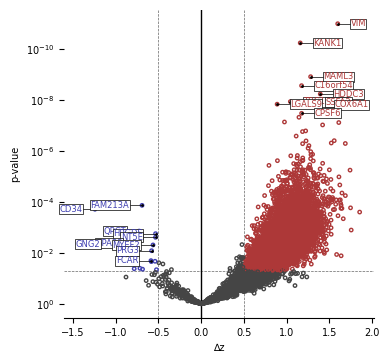

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS""",-1.542259,-1.395823,-0.447862,-0.980851,null,null,null,null,null,null,-1.947741,-1.136345,-1.120729,-0.939463,-1.616692,-1.874056,-0.217609,-0.456842,-1.511112,-0.832212,-0.748149,-0.401336,0.450722,-0.796796,-0.682444,0.138926,-0.347163,0.467166,-0.936152,0.857692,2.113329,0.791053,-0.308266,1.023863,0.542062,0.3426,…,-0.031399,1.46986,1.405213,0.285131,-0.128239,0.343336,-0.42078,-1.988544,-0.236326,-1.397439,-0.034244,1.58668,0.135788,-0.206442,1.022811,1.102638,-0.013074,0.928004,0.054984,0.159476,0.366877,0.970719,-1.267366,2.645251,-0.18844,-0.013034,null,0.70166,1.336155,0.708376,1.706465,1.578477,0.316274,-0.136293,0.870115,0.009994,0.017451
"""AACS""",0.016082,0.891129,0.014929,0.230692,null,null,null,null,null,null,-2.154921,-2.036157,0.586052,0.044943,-1.254978,-1.919572,-0.983412,-0.481312,-1.884537,-0.58567,-1.136294,0.515246,-0.747527,0.509453,0.612145,0.656307,-0.171533,-0.217533,-0.81261,0.097776,-0.319522,-0.960065,-1.13896,-2.883177,0.162554,-0.091256,…,0.368588,-1.067844,1.252179,-0.501623,-0.753393,-0.789782,-0.314534,-0.266404,1.436187,1.556085,0.029323,0.206673,1.82686,-0.603951,-0.186946,1.051341,0.529674,0.916148,1.730691,-0.131115,0.849734,-0.400351,-0.354508,1.41537,-2.019163,1.083997,null,0.887867,-0.319743,1.710934,2.057709,1.274579,0.507716,0.761482,1.118099,0.002742,0.007738
"""AAGAB""",-0.618605,1.092347,0.103645,0.071595,null,null,null,null,null,null,-2.510515,-2.470933,-0.670336,-0.968585,-0.292929,-0.822523,-1.921802,-1.082432,-1.353139,-0.438344,-0.97086,-0.404948,0.233059,0.080315,-0.240851,0.042966,-0.103969,-0.46013,-0.664431,0.246239,-0.266921,0.975007,-0.644519,-1.278079,0.085209,0.16072,…,0.040528,-0.830976,0.87779,-0.380387,-1.154639,-1.146293,-0.645516,-0.191312,1.884401,0.652709,0.748392,-0.131609,1.855103,-0.217422,-1.114269,1.671624,-0.052839,-0.266978,2.161232,-0.276165,0.936151,-0.834007,0.013851,1.742052,-1.213686,0.33313,null,1.381746,0.373073,1.750704,2.40928,0.452147,0.892648,0.916453,1.194558,0.001875,0.006304
"""AAK1""",-0.207097,1.02427,0.009679,-0.033026,null,null,null,null,null,null,-1.689299,-2.03898,-2.07001,-0.8117,-0.413482,-2.366944,-1.3957,-1.303839,-1.260513,-0.104213,-0.959681,-0.405905,-0.786658,1.283918,0.075197,-1.203633,0.144542,-0.16955,-0.742618,0.58737,-0.363489,-0.120275,-0.885915,-0.648691,-0.160846,0.122917,…,0.481692,-1.030489,-0.087672,0.111969,-0.151138,-0.596446,-0.380569,-1.146551,1.230414,0.089163,0.396183,1.171746,1.470221,0.621141,-0.204764,2.463535,0.590068,0.554144,2.023098,0.569228,0.775063,1.620893,-1.274666,-0.375303,-1.276747,0.101477,null,0.850621,0.237815,1.66316,1.993524,0.70526,1.411545,0.694378,1.075034,0.001991,0.00649
"""AAMDC""",-0.206425,-0.716536,0.783744,-0.058159,null,null,null,null,null,null,-1.037646,-1.939039,-1.345919,-0.033993,-1.129138,-1.613604,-1.352352,-0.391569,-1.6348,0.33674,-1.712471,-0.055434,-0.386299,0.672554,0.572812,0.658969,-1.539663,-0.659174,-0.148407,-0.30471,0.390307,0.0286,-0.746569

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AHSP""",-0.927681,-0.804271,-1.094587,0.667918,null,null,null,null,null,null,-0.350053,-1.259629,-0.550695,-1.264223,-1.109643,0.10557,0.290306,-0.96631,null,-1.084175,0.372638,0.027763,-0.409492,-0.73969,1.112539,-0.946855,-0.838155,-0.197818,1.776707,-0.397934,1.119548,2.016705,-0.747401,-1.580697,0.124796,1.971159,…,0.650593,1.371802,0.309726,null,0.389878,-0.713967,-1.071377,1.557006,-0.766302,0.28428,0.868452,-0.658408,0.996198,-0.718245,-1.538931,0.379879,0.04834,-1.18117,2.008374,-0.083024,0.734904,-0.81887,0.373411,0.345216,null,-0.152695,null,-1.37307,-0.132375,0.262137,-0.972053,-0.309784,-0.787189,-0.667555,-0.583228,0.022191,0.032334
"""APP""",-0.508249,1.435003,-0.713875,0.333159,null,null,null,null,null,null,-2.216796,-0.230126,-0.169105,0.113517,-0.440136,-0.366757,1.629585,0.763995,-0.572198,2.215416,-0.425326,0.97802,0.041514,0.084344,-0.308671,-0.086823,-0.054991,0.527503,-2.605791,0.95549,0.421679,-0.450899,0.660291,0.708331,1.136829,1.12354,…,-0.292029,-1.387204,1.202318,0.930668,-1.86927,0.880809,-0.315481,1.14343,0.413139,0.132786,-0.833366,0.608893,0.190356,-0.547569,1.282595,-1.046919,-2.452934,1.046084,-1.017768,0.081033,-0.652907,0.910869,-0.072257,-0.802389,-0.729685,-0.911552,null,0.616827,-0.709378,0.193389,-0.133616,-1.574339,-1.262393,-1.319051,-0.715978,0.040593,0.053806
"""CA4""",-0.505503,1.853652,-0.062877,0.788238,null,null,null,null,null,null,0.150503,0.284747,0.420607,-0.942779,0.87467,0.656352,-0.949527,-1.534105,-1.696643,0.487961,1.499225,0.561396,0.335748,-1.435309,0.648274,0.217959,0.368464,-0.342047,-1.474572,0.110213,-0.542245,-0.222716,-0.395078,-0.912452,0.622129,2.795059,…,-0.163547,0.786483,0.589671,-2.888126,0.066479,-0.442531,-1.235947,0.700633,1.33489,1.065416,1.043224,-0.58343,1.279759,0.474854,0.52019,-0.251903,-1.68437,-0.018495,0.120882,0.107217,0.187143,-0.834081,-0.786453,-0.814721,-0.718903,null,null,-0.561314,-0.319181,0.614044,-0.985499,-1.255667,-0.360418,-1.465767,-0.685789,0.043973,0.057653
"""CD34""",-1.33872,-0.980798,1.080388,-0.131088,null,null,null,null,null,null,-0.660135,0.297102,-0.850579,0.941584,-1.443437,-1.528937,0.518846,-0.072907,-0.629734,-0.02597,-0.018339,-0.166496,1.03868,-2.054367,-0.424055,0.094191,0.973697,0.987715,-0.44802,1.132376,1.150005,0.767481,1.480259,-0.149164,1.650466,0.193302,…,-0.913241,0.151168,-0.447166,0.862103,1.416539,1.066651,0.618699,0.106913,-1.849179,1.148626,-0.642678,0.794784,-0.990593,-0.608879,1.740851,-0.905314,-1.568392,0.253007,-0.313234,-0.459378,-0.165622,0.65807,-1.681517,1.681857,0.484016,-0.958597,null,-0.065967,-0.864971,-1.499578,-1.121057,-0.881617,-1.388331,-2.070577,-1.242501,0.000196,0.00258
"""FAM213A""",-0.657608,-0.488876,-1.063258,-0.249946,null,null,null,null,null,null,1.325273,1.082037,-1.188197,0.512927,-0.084716,0.342491,1.499779,-1.158423,-1.465799,-1.409161,-0.377131,-1.269111,1.180676,-0.677315,1.510378,1.119643,-1.477385,-0.206249,-1.686288,-1.001344,1.862104,-0.209077,1.295828,2

Phosphoproteomics


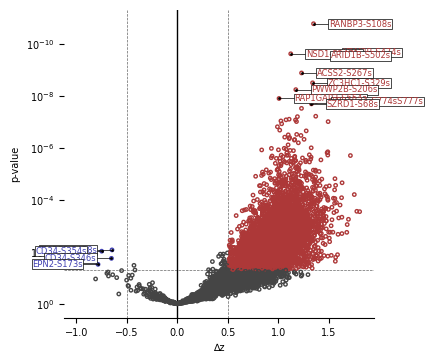

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",-0.232702,0.797706,-0.735363,null,null,null,null,null,null,null,-1.530117,null,-2.493254,-0.6046,-0.76177,-1.265441,-1.106084,null,-0.510382,-0.590834,-1.100266,-1.147387,-0.583367,null,-0.292071,-0.106818,-1.024001,null,-0.417458,null,-0.313824,0.018426,null,null,null,null,…,0.053347,null,0.235535,null,-0.651687,0.01545,null,-0.730482,1.019936,-0.220521,null,1.661606,null,1.047111,-0.54162,null,0.404963,1.057119,2.168077,0.231329,null,2.085892,-0.893581,null,-1.332266,0.479436,null,0.354492,null,1.92029,1.802266,0.59829,1.556108,1.191039,1.308435,0.000891,0.006309
"""AAK1-S637s""",0.209207,0.115947,0.35562,-2.246627,null,null,null,null,null,null,-1.994915,-1.04469,-2.21904,-0.008995,-1.190808,-0.222406,null,-0.580768,-0.771075,-1.137394,-1.708731,-0.272672,-0.711491,0.364697,-1.024219,-1.228444,0.602022,-0.524817,-0.70452,-0.248658,-0.117671,0.067946,-1.041467,0.529182,0.463319,-0.106077,…,1.033709,-0.133804,-0.775556,0.367483,null,0.016048,-0.128321,-0.729273,2.315736,-0.10871,0.734946,1.813779,1.123318,1.505859,-0.030029,2.082634,0.744922,0.132706,1.918748,0.594209,0.512056,-0.269078,-0.872749,-0.679597,-0.991204,0.314926,null,0.580794,0.857347,1.269899,1.498213,-1.273079,1.495296,0.772235,0.777003,0.048365,0.07253
"""AAK1-S670sT674tS678s""",null,null,0.455455,null,null,null,null,null,null,null,-1.329943,-0.843083,null,0.45729,-0.454744,-1.302413,-1.110538,-0.810255,-0.249454,-0.338462,-0.847554,0.090271,-0.573825,0.550462,-2.846388,-0.93214,0.023267,-0.734712,-0.796241,0.452822,0.01258,0.052558,-0.850748,0.82642,0.761471,0.012194,…,1.518777,-0.788581,-0.460917,-0.195487,-1.237785,-0.243975,-0.648986,-1.214978,0.999944,-0.095225,0.374329,1.433229,1.511664,1.262773,-0.237777,2.402747,0.875055,0.016575,1.413604,0.866005,-0.55373,1.60941,-1.704015,-2.134276,-0.983334,null,null,0.789232,0.80306,1.606202,1.584997,0.50505,0.892894,0.858839,1.121168,0.000056,0.001679
"""AAK1-T606t""",-0.322396,0.10375,0.797769,0.103229,null,null,null,null,null,null,-1.806668,-1.441886,-2.269473,-0.775226,-0.606671,-1.972968,-1.451819,-0.869878,-0.559534,0.112661,-0.834578,-0.410351,-0.803694,1.262689,-0.663979,-1.717362,0.311043,-1.273521,-1.136501,0.306615,-0.183597,-0.34626,-1.348001,0.265863,0.722519,0.430393,…,0.259503,-0.860097,0.07884,-0.073961,-0.500951,-0.410384,0.003157,-0.442278,0.693932,-0.456918,0.879153,1.262155,1.7895,1.254882,-0.215905,2.262415,1.042247,0.375981,2.247974,0.817115,0.935572,1.692447,-1.248356,-0.904164,-0.90432,0.234047,null,0.315854,0.345743,1.355507,1.921856,0.894243,1.619147,0.325176,0.984317,0.003636,0.013175
"""AAK1-T620t""",0.072488,0.740562,1.172272,0.321233,null,null,null,null,null,null,-0.852024,-1.044581,-3.257378,0.309102,0.42675,-1.865965,-1.930165,-0.343035,-0.950522,0.530462,-0.786894,-0.008177,-0.952786,0.500628,-0.201836,-0.633322,0.518022,-0.484048,-0.629117,0.580817,-0.517839,-0.11533,-1.282316,-1.164193,0.168741,-0.061063,…,-0.165353,-0.820662,0.542815,0.047126,-1.084356,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD34-S346s""",null,0.063058,1.120947,null,null,null,null,null,null,null,-1.317259,-0.160925,-2.700304,0.586749,-0.670761,-1.370247,0.852105,-0.136859,0.186199,-1.142135,-0.787312,-0.210035,0.953325,-1.577913,-0.075095,-0.047604,0.655045,0.309244,-1.332409,0.503259,0.830898,0.601078,2.238049,0.545286,2.520212,-0.297206,…,-0.908231,-0.58923,-0.470297,0.161699,0.598381,2.039444,1.213285,0.494197,-1.336076,0.732561,-0.458657,0.545028,-0.233918,-0.949577,1.669703,-0.411437,-1.595445,0.875193,-0.380193,-0.626359,-0.637682,0.70481,-1.772988,0.566256,0.292568,-1.406932,null,0.377439,-0.503779,-1.121407,-0.149171,-0.291896,-0.54515,-0.983003,-0.651383,0.017858,0.035276
"""CD34-S354s""",-1.618267,-1.11668,1.958265,-0.991315,null,null,null,null,null,null,0.114072,0.888858,-2.48028,0.883387,-0.850715,-0.284197,0.113928,0.855026,-0.223354,-1.321128,-0.403195,-0.155042,0.92805,-1.381269,-1.004414,-0.28729,0.351885,1.42487,-0.952712,1.419019,1.190473,0.378664,0.253574,-0.262158,2.545778,0.032186,…,-0.832147,0.35343,0.074428,1.150968,0.007571,0.488595,-0.471669,-0.356323,-1.009799,1.17663,-0.247456,1.344565,-0.914251,-0.831002,2.271337,-0.794689,-1.048564,0.041079,0.698611,-0.525723,0.582767,0.867925,-1.552121,-0.594256,0.991243,-1.374141,null,-0.228127,-1.576584,-0.30062,-0.640791,-0.262431,0.067213,-1.013964,-0.748172,0.009484,0.023245
"""EPN2-S173s""",-0.710011,null,0.694811,-0.040187,null,null,null,null,null,null,null,-1.133907,null,-0.50706,-1.602406,0.911018,-0.819221,-1.100723,null,-1.534418,0.522351,null,0.80767,-1.774378,null,-0.650272,null,-0.019721,null,0.384179,1.448661,null,-1.127879,0.47843,0.829367,0.530691,…,1.397282,0.099133,null,1.142407,-0.35651,-0.123517,-0.295357,null,0.421182,null,-0.451098,null,1.646831,null,null,0.58823,1.674747,null,2.254858,null,1.582419,-1.529612,null,0.428978,-1.5465,-0.504758,null,0.046698,-1.133595,-0.059498,null,-1.627187,-0.850992,null,-0.784253,0.030422,0.050978
"""TMCC2-S438s""",null,0.056561,0.614041,-0.909539,null,null,null,null,null,null,-1.113322,-0.843715,-0.598489,-0.925826,0.040148,-0.111869,-0.262181,0.645241,-0.686115,-1.835026,0.887963,1.45842,-0.836594,-0.555604,0.343363,-1.211728,-0.078738,0.701002,-0.03244,0.190329,1.940259,1.898093,-0.751159,0.809917,0.418399,1.944143,…,-0.900324,1.318238,-0.343879,-1.78458,1.688483,0.338387,-0.984157,0.023939,-1.653267,-0.105342,0.187101,0.289658,0.570334,-0.656196,-0.077084,0.839883,0.322645,-0.625749,2.116427,-0.529384,0.675161,-0.680976,-0.989041,-0.849691,-0.995419,-1.036113,null,-0.090553,-0.805664,0.22137,-0.483203,-0.32583,-0.888259,-1.186714,-0.646167,0.008448,0.021761


Acetylomics


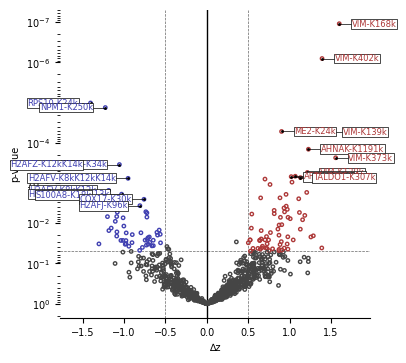

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AFF1-K582k""",0.335458,null,1.287542,1.21415,null,null,null,null,null,null,-1.225531,-0.635264,null,-0.297214,0.529286,-0.237802,-1.174702,0.545785,-0.423744,0.075009,-0.797457,-0.287035,-0.434572,0.622133,-1.611365,-0.890581,0.493548,-0.274924,-0.402916,0.015207,0.367671,-0.136104,0.432122,-0.009838,1.248278,-2.074025,…,0.823204,-0.718885,-0.477171,0.007344,-1.596027,0.922403,0.127411,0.036903,0.186696,0.51056,0.881271,0.79717,0.623821,0.65219,0.720542,0.875113,0.380134,0.269087,-1.381011,0.149421,-0.039505,1.010615,-0.873794,-2.955334,1.758643,1.408186,null,0.14344,0.36939,1.156336,1.661479,0.316377,1.129406,1.053988,1.019724,0.000694,0.044449
"""AHNAK-K1191k""",null,null,null,null,null,null,null,null,null,null,-0.609267,-0.655949,null,-1.299473,-0.340781,-1.389246,null,0.516503,-0.696333,-1.686588,0.13243,0.126161,0.577373,-0.82262,-1.918211,-1.074377,0.09713,-0.778826,-0.526309,1.006713,-0.270561,-1.385017,-1.037076,-0.984889,0.266037,-0.180721,…,1.164022,-0.683952,1.547828,0.991069,-0.896021,-1.564318,0.108448,0.267825,1.404507,-0.031958,-0.312094,1.866247,1.55968,0.176083,-0.156375,1.089091,1.043496,0.080302,1.556658,0.37515,0.782281,0.060146,null,-1.704012,-0.430115,1.846903,null,1.27368,0.134571,1.359318,1.299524,0.410037,1.379052,0.92938,1.227894,0.000144,0.0184
"""ANP32A-K110k""",null,null,-0.299153,null,null,null,null,null,null,null,-0.424204,-0.640791,-3.162024,-2.77064,-1.751482,-0.297133,-2.602714,0.216477,-2.610303,-1.567142,0.404115,-0.047912,0.348013,0.699144,-0.032561,0.446113,-0.118122,-0.155164,-0.034705,-0.474498,-0.832718,0.649112,0.647515,-0.4412,0.299297,0.238401,…,0.733028,-1.313967,0.179325,0.818416,-0.105586,-1.381779,-1.674326,0.475953,0.98781,0.407519,0.142201,-0.132464,0.47263,1.792753,1.334075,0.145899,-0.142764,0.630342,0.27825,1.395904,-0.7633,-0.561523,0.052611,0.584133,-0.424697,null,null,0.292691,-0.363625,0.712131,0.897741,0.495734,0.892535,0.362686,0.523047,0.025958,0.267009
"""ANP32B-K110k""",null,null,-0.299153,null,null,null,null,null,null,null,-0.424204,-0.640791,-3.162024,-2.77064,-1.751482,-0.297133,-2.602714,0.216477,-2.610303,-1.567142,0.404115,-0.047912,0.348013,0.699144,-0.032561,0.446113,-0.118122,-0.155164,-0.034705,-0.474498,-0.832718,0.649112,0.647515,-0.4412,0.299297,0.238401,…,0.733028,-1.313967,0.179325,0.818416,-0.105586,-1.381779,-1.674326,0.475953,0.98781,0.407519,0.142201,-0.132464,0.47263,1.792753,1.334075,0.145899,-0.142764,0.630342,0.27825,1.395904,-0.7633,-0.561523,0.052611,0.584133,-0.424697,null,null,0.292691,-0.363625,0.712131,0.897741,0.495734,0.892535,0.362686,0.523047,0.025958,0.267009
"""ANXA1-K161k""",null,0.601939,0.213971,1.168451,null,null,null,null,null,null,0.630197,0.56775,-2.569193,-1.413066,-0.747546,1.664407,-0.764254,-0.040134,-1.391334,-1.509763,0.988067,-0.248921,-0.710208,-1.682603,0.242013,-0.67463,-0.704741,-0.448194,-0.278839,-0.311216,-1.619149,-1.410279,-2.792868,-1.917988,0.404944,0.928753,…,-0.224636,-0.496119,1.272255,0.09

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH7A1-K93k""",null,-0.023,0.046363,-1.445426,null,null,null,null,null,null,0.99697,0.412987,-0.791612,0.572163,0.816999,0.148165,-1.167779,-1.263905,-0.464888,0.194758,1.427443,0.362771,0.705608,1.174836,-0.130333,0.422891,-0.080574,0.885855,-0.038327,1.040046,-0.348891,-0.113741,-0.873611,-0.229448,1.250021,0.653787,…,null,1.076394,-2.101419,0.150263,-1.624469,0.110838,-0.440811,0.184517,null,0.483843,-1.175185,-0.682865,-1.241621,1.208444,1.238659,-2.466396,-1.596094,0.471259,-0.308093,-0.619152,null,0.866273,-0.179978,0.757719,-0.332608,-0.508784,null,-1.126054,-0.031446,-1.392172,0.648307,-0.349666,-0.575795,-1.352595,-0.662881,0.036446,0.306696
"""ANXA11-K408k""",0.146405,0.346242,null,-0.251065,null,null,null,null,null,null,0.159036,-0.602776,null,0.903411,-0.206942,-0.048099,-1.767318,null,null,-0.762854,1.128591,null,-0.547511,null,null,0.05952,0.537314,null,-1.458926,-0.197048,0.072185,null,0.615733,null,null,2.259321,…,-0.199041,null,0.517308,-1.165957,0.866739,-1.019641,null,0.03608,0.276869,null,null,0.194825,-0.172353,null,1.476164,-1.057269,-0.93254,null,-0.244895,1.41707,0.010244,-1.245938,null,null,0.448117,-1.150471,null,-2.251144,0.254728,0.2963,-1.119536,-1.529426,-0.778163,-0.290683,-0.973803,0.017343,0.237997
"""BLVRA-K269k""",1.260637,-0.928464,1.503401,3.931043,null,null,null,null,null,null,1.19658,null,0.312833,0.315031,0.334481,0.945819,-0.614211,0.934911,-0.687314,0.347246,0.288146,-0.425172,1.261715,-1.396622,2.1192,-0.821028,0.2204,0.305033,-1.679482,0.299341,-1.066599,-0.125922,0.051604,0.300636,0.464094,0.809296,…,0.120087,-1.693425,-0.399217,-0.904221,-0.603211,-1.778745,0.168243,1.262627,1.548593,1.369252,-1.029451,-0.942655,-0.781477,-0.750149,-0.838381,0.139237,-0.587817,0.946265,1.02151,-0.703122,0.901107,-1.39154,0.100813,-0.175506,-1.394672,-0.555873,null,-0.481985,-0.72504,0.31214,-0.579229,-0.653753,-0.996775,-1.55906,-0.736815,0.005171,0.129374
"""CCAR2-K215k""",null,-1.595981,null,-0.129649,null,null,null,null,null,null,0.699275,0.236656,null,1.466169,0.409146,-0.799735,-0.076127,0.352773,-1.270218,-0.075911,1.486164,-1.297127,0.355011,2.105233,-1.921747,1.354083,1.720729,1.499855,2.112917,1.183332,0.606282,-0.923058,0.94724,1.933113,0.359049,0.974604,…,0.865334,-0.452478,-1.023465,-0.779599,-1.674159,-0.100809,0.06058,-0.555102,0.988198,-0.322279,0.588027,-0.558811,-0.91287,0.961246,-0.563671,-1.266921,0.795009,0.377242,-0.786351,-0.394513,-0.564693,-0.437988,-1.284753,-1.291377,0.653406,-0.319515,null,-0.539652,0.170099,0.172617,-0.314979,-0.968203,-1.469294,-1.31869,-0.647446,0.02641,0.267009
"""COTL1-K72k""",-0.328809,null,1.364761,null,null,null,null,null,null,null,null,-0.976327,null,0.151207,null,null,null,1.942342,null,null,1.043722,null,null,-0.093782,null,0.060671,0.204546,0.051813,0.378566,-0.150424,null,null,0.307782,-1.062395,1.108073,0.626383,…,null,-1.020952,1.539683,0.556143,null,null,0.366682,-0.207788,null,null,-0.764997,-0.684585,1.615304,null,-0.53128

Lipidomics


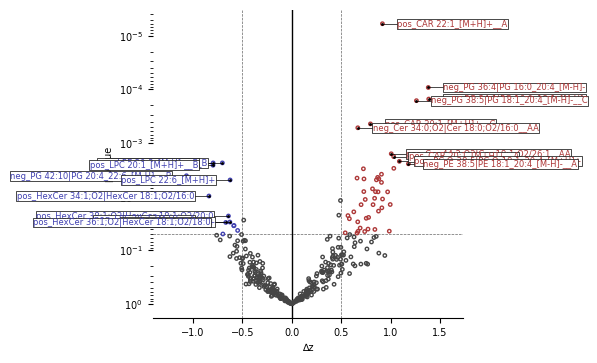

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPG 18:0_[M-H]-__A""",0.207264,null,0.009843,null,null,null,null,-0.671926,-3.084814,-0.626124,-0.559052,0.127463,-3.918838,-1.251469,-1.313047,-0.178312,0.155247,-1.49335,-0.233815,-0.010606,0.309195,0.5105,-1.01285,0.126134,0.710277,0.544393,-0.581155,0.952186,-0.098639,0.929812,-1.055715,0.071139,1.383071,-0.990469,-0.091,-0.411431,…,1.138978,-1.184113,-1.284489,-0.472194,-2.200263,0.5147,0.417679,0.384227,0.776708,1.260723,0.070628,0.839909,-0.420967,-0.790856,0.214582,0.89625,1.470955,0.873993,1.494056,0.105975,-0.227746,-0.512046,0.613668,-1.011364,null,null,0.094922,0.001746,1.314456,0.437056,1.028189,0.446243,0.831853,0.549278,0.660333,0.004533,0.073283
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.304298,null,0.205666,null,-1.877715,-2.336927,-0.671176,-0.559277,-0.89684,0.730015,-1.528752,0.924474,-0.121785,2.107107,0.158423,-1.873054,-0.017167,0.410613,-0.225106,0.735596,-1.569228,-0.574981,-0.465229,-0.156281,-1.043631,-0.057784,-0.333594,0.473044,-0.109398,0.364759,0.730195,0.993495,-1.085776,0.540492,0.794747,-1.860314,…,-0.021828,0.976691,0.444138,0.547362,-0.154064,1.175937,0.78952,-1.591981,-0.033355,-0.954576,-0.48851,0.489138,-1.474352,0.631859,0.883681,0.418319,0.686194,0.095807,-0.267403,-0.912236,-0.795319,0.313918,-0.62282,0.909535,null,null,1.017552,1.520874,1.923878,0.151462,1.420306,1.782571,1.387895,0.680967,1.381063,0.000093,0.013984
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.215346,null,0.795471,null,-2.441927,-1.966074,-0.915823,-0.483266,-0.888357,0.279216,-0.10746,0.794978,-0.830775,1.136461,-0.391025,-1.149383,-0.903751,-0.814991,-0.488269,-0.294001,-1.121868,-1.291125,0.036713,-0.093762,1.331255,0.399075,-0.539235,-0.968015,-0.854319,-0.551013,0.797477,0.237136,-0.41343,-0.34982,0.006833,0.022341,…,0.769201,0.748982,-0.021423,1.039508,0.074314,0.546116,-0.632635,-1.389862,-0.30681,1.144033,-1.361237,0.865305,-1.094948,2.380518,0.463456,0.148231,0.258864,0.203508,-1.024416,-0.035257,-1.473879,0.433882,-0.004088,2.162146,null,null,0.321056,0.892991,0.797209,2.014038,1.861902,1.040461,0.748887,1.351352,1.26125,0.000163,0.013984
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.835229,null,0.259231,null,-2.285279,-2.742033,-0.876752,0.193112,-0.667221,-0.100126,-0.716662,-0.466087,0.30455,1.103579,0.954836,0.534101,0.888643,-0.784361,1.079024,0.250012,0.140463,-0.019744,0.180968,1.492705,-0.734978,0.077395,-0.921876,-0.774893,-1.056783,-0.584441,0.71958,1.058284,-0.537509,-0.467674,-0.743222,-0.742827,…,0.759907,0.835589,-0.930589,0.429675,-0.215208,1.95968,0.527086,-1.328964,0.21815,-1.636504,-0.397901,-0.236251,-1.357112,0.191948,-0.150869,0.561372,2.098452,-0.32932,-0.325366,-0.183514,-0.074807,0.860002,0.117964,2.601947,null,null,1.316481,-0.178241,1.869377,1.441341,0.763475,0.719842,0.969252,-0.32875,0.918256,0.011128,0.117939
"""neg_PI 37:4|PI 17:0_20:4_[M-H]…",-0.030635,null,0.941094,null,-2.497806,-2.970579,0.055936,0.03974,-0.594966,1.095485,-0.881239,-0.572112,-1.539933,0.417872,0.703239,0.1

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__B""",0.849367,null,0.031787,null,1.708379,2.899714,1.185776,0.897843,1.486716,0.566569,0.142487,0.606828,-0.168329,0.657245,0.539455,2.111066,-0.193652,0.119072,-0.012136,0.227433,1.745584,1.547921,0.195106,0.396514,0.288138,1.652541,-0.467357,0.183066,-0.370741,0.979318,1.354223,-1.098798,-0.142795,-0.859321,-0.577494,0.133305,…,-0.91685,-0.167379,-1.907159,-1.339492,-0.523074,-1.592387,-0.837193,-0.280005,-0.215144,-0.069901,-1.017903,-0.713653,-0.659353,-1.336236,-1.281093,-0.577475,-1.933429,0.906945,-0.512646,0.474645,-0.965213,-0.033517,-0.798691,-0.832855,null,null,0.047762,-0.857765,-0.761787,-0.026857,-0.539149,-1.234506,-0.848415,-0.806571,-0.702342,0.002361,0.068809
"""neg_LPE 20:4_[M-H]-__C""",-0.486943,null,-0.550064,null,0.850925,2.97328,0.633296,1.316761,1.057219,0.448861,-0.372532,0.900762,0.408161,1.206719,0.597235,2.344475,0.192454,-0.1446,0.537863,0.502638,1.805623,1.714076,0.388701,0.801507,-0.032222,1.801542,-0.151948,0.088034,-0.170661,0.670652,1.211284,-0.201296,-0.016441,-0.524137,-0.719961,-0.443606,…,-1.127747,-0.011003,-0.596675,-1.265776,-0.511359,-0.904149,-1.02334,-0.689428,-0.730094,0.076844,-1.269168,-0.685736,-1.204941,-1.018033,-0.944807,-0.438171,-1.732455,0.731644,-0.560886,0.052475,-0.909417,-0.619417,-1.092435,-1.365755,null,null,0.67325,-0.873128,-0.797531,0.009647,-0.897497,-0.92119,-0.905023,-0.209733,-0.547815,0.042911,0.257114
"""neg_LPE 20:3_[M-H]-__A""",1.205097,null,-0.2184,null,0.617152,1.246762,0.055522,1.581159,1.324491,0.569077,0.146862,0.76101,0.788886,0.71653,0.367447,2.237402,0.409421,0.265589,0.379175,0.732943,2.085296,2.099378,-0.041772,0.945805,0.521256,0.697178,-0.04214,0.825283,-0.044636,1.259571,0.823761,0.869629,-0.271897,-0.913501,-0.200461,0.989606,…,-1.106745,0.824392,-0.527032,-2.051485,-0.287089,-0.138439,-1.849282,-1.122963,-1.654828,-0.371178,-0.829711,-0.876634,-1.207626,-0.520825,-0.704616,-1.009419,-1.390606,-0.269678,-1.296364,0.06553,-1.827329,0.133678,0.004088,-1.482949,null,null,0.673051,-1.769745,-1.472172,0.139295,-1.013001,-0.764734,-1.295248,-0.441094,-0.830362,0.026877,0.196145
"""neg_LPE 20:3_[M-H]-__B""",0.597151,null,-0.313505,null,1.602151,2.736388,0.908907,1.118107,1.363475,-0.057893,-0.182132,0.230342,0.90974,0.774876,-0.033594,2.286808,-0.195486,-0.159195,0.162951,0.23873,1.577189,1.565417,-0.130087,0.611049,0.681549,1.562332,-0.461451,0.414928,-0.418844,0.588027,0.197098,1.075647,-0.240234,-1.11893,-0.319892,0.42561,…,-1.322666,0.069516,-0.442533,-1.215641,-0.119509,-0.492087,-1.014909,-0.134439,-1.320452,-0.001982,-0.939821,-0.770132,-1.143195,-0.778107,-0.940616,-0.94276,-1.748157,0.165092,-0.606503,-0.057239,0.064995,0.225836,-0.806671,-1.141994,null,null,0.201773,-0.817486,-1.27183,-0.30403,-1.125837,-0.711576,-1.200804,-0.465928,-0.795725,0.002363,0.068809
"""neg_LPE 18:1_[M-H]-__A""",1.502238,null,-1.43667,null,0.968894,2.100821,0.555655,2.330463,0.930707,-0.338651,0.698958,1.886084,1.345159,-0.816675

Metabolomics


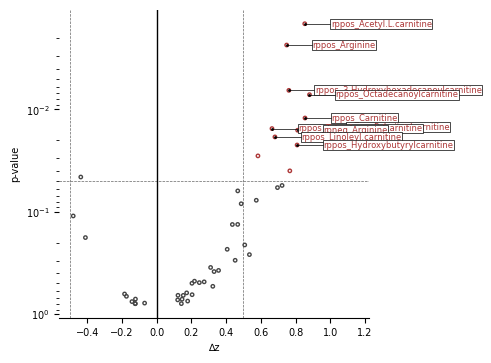

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.627262,null,-1.728641,null,-1.173779,-0.84158,-1.000139,-0.923439,-2.181236,-0.919689,-0.579179,0.082419,-1.473882,-0.512808,-2.129273,-1.217991,-1.588233,-1.032691,-1.963764,-0.376579,-0.819717,-1.310512,-0.515021,-0.38647,1.454946,-0.264087,-0.882361,-0.891168,-0.470562,1.005753,0.522939,-0.229449,-0.464548,-1.375386,0.093458,-0.459609,…,1.405613,0.100269,-0.274047,0.472574,1.113026,-0.421497,0.434716,0.135653,0.037356,0.708997,0.040625,0.606192,2.465368,0.483378,-0.694471,0.865921,1.481337,1.168988,1.92229,1.10073,1.513613,-0.335591,2.359188,0.44346,null,null,0.100071,0.421228,0.28873,0.087038,1.291219,1.484238,1.238767,0.540662,0.76167,0.006525,0.088097
"""rppos_Acetyl.L.carnitine""",1.665457,null,-1.215304,null,-2.789439,-0.690226,-1.338227,1.303796,-0.707346,0.230492,0.436804,0.456092,-0.43065,-0.293198,-1.367427,-0.22048,-1.620034,0.135837,0.378186,0.483009,0.070968,-2.194102,1.23043,-0.122903,1.815929,-1.668681,-0.674515,-0.464662,0.683773,-0.090329,-0.133137,0.100574,-2.635757,-0.690593,1.554094,-1.87758,…,0.045952,-1.004947,0.392409,0.780311,0.651253,1.300663,-0.609512,1.300113,0.450839,0.195933,0.57115,-0.186318,1.611606,0.48636,-1.22579,0.346405,-1.050748,-0.343177,0.473576,-1.067694,0.871053,0.275676,-1.548762,0.375803,null,null,0.132057,1.079936,1.188326,-0.034954,1.3909,1.049922,0.589209,0.712224,0.853271,0.001459,0.05772
"""rppos_Arginine""",0.84406,null,-0.748368,null,-0.358998,-0.761296,-0.227874,-2.979938,0.662461,1.52451,0.028864,1.28337,-0.000367,0.019274,1.056697,1.078023,0.482683,-1.884898,1.570979,1.261979,0.557614,-0.071675,2.156052,0.220687,-0.566167,-0.085609,0.274503,0.057158,-1.20592,1.319299,0.47461,0.759909,-2.02005,0.972984,0.403817,-1.814312,…,-1.016832,0.367677,-2.10274,-0.398923,1.737171,0.21304,-0.915441,-0.431769,-0.640186,-0.254855,-0.013253,0.074592,-0.328334,0.081285,-0.548406,0.44657,-0.356315,0.431033,0.462211,-1.169373,-0.607425,-0.182714,-0.57642,0.19517,null,null,0.709278,1.704419,0.352811,0.542514,0.904255,0.223661,0.32615,0.598016,0.748978,0.002356,0.05772
"""rppos_Carnitine""",-0.629036,null,-0.075422,null,-3.177657,-0.860112,-1.458331,0.426135,-0.916754,-0.291709,-1.229098,0.47321,-0.054967,-0.423866,-1.620205,-0.409276,-1.653238,-0.20421,0.183168,-0.355954,-0.270061,-2.449391,1.108858,-1.028242,1.111794,-1.840371,-0.077061,-0.273083,0.527298,-0.326387,-0.247441,0.395245,-2.339368,-0.01544,1.067889,-1.884087,…,0.453257,-0.621301,0.555392,0.427468,0.767449,0.822672,-0.0717,1.121326,1.064094,0.618091,0.59413,0.293402,1.97242,0.70535,-0.104651,0.937036,-0.922418,-0.104,0.360421,-0.222589,1.270876,1.074336,-1.481506,1.316374,null,null,-0.590249,0.944409,1.182983,0.029119,1.039198,1.389985,0.604637,1.518105,0.854747,0.012151,0.097959
"""rppos_Dodecanoylcarnitine""",1.887397,null,-2.031757,null,-2.605235,-2.07261,-2.543125,-0.550198,-2.003355,0.024818,0.127185,0.21801,-1.757611,0.23158,-1.667495,-1.181468,-0.918559,-0.508848,-0.805886,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITDxNPM1-WT ============
Transcriptomics


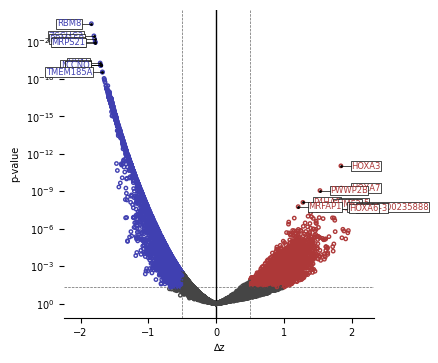

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SCYL3""",null,-1.359743,-0.554426,0.199335,-1.829527,null,-0.360312,-0.422111,null,0.05202,null,-0.853484,1.865576,0.170603,0.441116,-0.652144,3.133281,-1.253831,-0.18829,0.207512,-1.153024,0.193965,-0.486975,4.173273,null,-0.466862,null,null,null,null,-0.624768,0.177225,0.912605,1.051147,-0.831367,null,…,-0.937677,-1.071382,0.959515,-0.251971,null,null,null,null,null,null,null,null,-0.02787,1.040609,0.077638,-0.358467,null,null,0.843704,1.41917,null,1.15242,-0.158183,null,0.335043,0.550827,0.480906,1.104924,0.73256,null,0.979652,0.259311,0.281379,null,0.72243,0.000689,0.00486
"""CFH""",null,-0.384637,-0.568284,-0.467763,-0.592168,null,-0.566066,-0.511319,null,-0.545401,null,-0.514271,-0.372895,-0.567859,-0.551798,-0.46221,0.121713,-0.586497,-0.55772,-0.350281,-0.36032,-0.529257,-0.552978,-0.569775,null,-0.571369,null,null,null,null,0.031093,-0.27153,-0.549644,2.10006,-0.583417,null,…,-0.592168,-0.523177,3.838814,-0.382891,null,null,null,null,null,null,null,null,0.443649,-0.35316,0.050407,-0.410548,null,null,0.47101,2.555676,null,-0.108995,-0.370165,null,1.190686,3.101175,-0.062956,0.288908,0.061874,null,1.848849,3.504585,0.044322,null,1.016066,0.007628,0.029585
"""STPG1""",null,-1.270153,-0.348619,0.163659,-1.495367,null,-0.924035,-1.086984,null,0.406685,null,-0.81798,0.107059,-0.534164,-0.935641,-0.010508,0.332905,-1.319159,-0.681168,-0.729892,-0.698974,-0.606962,1.244132,2.584056,null,1.40266,null,null,null,null,-0.979421,0.023313,-0.181304,-0.386933,-0.23475,null,…,-0.616294,-0.467965,0.158789,2.187421,null,null,null,null,null,null,null,null,-0.962613,-0.970339,-1.158594,0.524779,null,null,1.041888,3.124999,null,2.49489,0.519101,null,0.643166,1.938982,1.035337,0.954185,0.61823,null,1.533336,-0.079464,0.430148,null,0.969033,0.006769,0.027206
"""NIPAL3""",null,-1.247204,0.066154,0.122524,0.041269,null,-1.090573,-0.287103,null,-0.010894,null,-0.774848,-0.570056,0.069195,-0.598732,-1.082353,3.084093,-1.086145,-0.425048,-0.639129,-1.077178,-0.121001,-0.853411,0.132552,null,-0.519218,null,null,null,null,-1.113218,1.056585,0.935861,-0.092387,0.076603,null,…,-1.163935,-0.537604,0.793218,-0.555987,null,null,null,null,null,null,null,null,-0.583745,-0.149409,-0.877124,-0.306277,null,null,0.171754,1.652909,null,3.878256,0.242015,null,1.456079,1.613305,0.610341,1.138563,1.203235,null,1.966257,0.752118,1.553543,null,1.187396,0.001263,0.007745
"""LAS1L""",null,-1.482988,2.129519,-0.580882,1.251372,null,1.096512,-0.008801,null,0.13261,null,-0.272453,-0.396814,-0.082868,-1.071542,0.424551,1.158134,-0.335519,0.5387,-0.162406,-0.662457,-1.162688,-1.603508,0.875033,null,0.342006,null,null,null,null,1.208019,0.957327,0.835396,0.215639,-0.014332,null,…,-1.65848,-1.18426,0.358849,-0.781841,null,null,null,null,null,null,null,null,-0.289355,-0.113219,-0.377558,-0.090579,null,null,0.882745,1.182005,null,0.792689,-0.21158,null,1.492586,3.09233,-0.548175,0.409673,0.767992,null,0.644435,0.573262,0.718677,null,0.740032,0.009558,0.034976
…,…,…,…,…,…,…,…,…,…

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HS3ST1""",null,0.554085,0.858222,-0.402468,-0.510997,null,0.143668,0.364907,null,0.234901,null,0.137613,-0.25717,-0.396352,1.160025,-0.480605,6.507775,0.11638,-0.203171,-0.308584,-0.438461,3.07246,-0.510997,-0.453391,null,-0.475327,null,null,null,null,-0.44189,-0.480259,0.241867,-0.47658,0.177912,null,…,-0.384576,-0.478729,0.053986,0.333794,null,null,null,null,null,null,null,null,-0.510997,-0.408526,-0.502477,-0.487925,null,null,-0.493083,-0.504659,null,-0.410698,-0.470481,null,-0.434613,-0.458863,-0.439575,-0.444596,-0.470182,null,-0.510997,-0.065613,-0.463042,null,-0.586685,0.000716,0.005003
"""ST7""",null,0.166456,-0.162371,1.310435,-0.46145,null,-1.17841,1.463493,null,-1.175864,null,-0.920507,-0.367715,-1.112336,1.053943,1.385087,0.117605,1.069244,1.723457,1.602409,0.366485,-0.31711,0.076171,-1.009844,null,0.03407,null,null,null,null,0.79912,4.382164,0.122752,-0.378163,0.55765,null,…,0.12403,-0.170485,0.659701,-0.367142,null,null,null,null,null,null,null,null,-1.233231,-1.225112,-1.225195,0.338893,null,null,-0.549607,-0.813718,null,-1.225598,0.177596,null,-1.244623,-1.054856,-0.141443,-1.220959,-0.111451,null,-0.482233,-0.466805,-1.116591,null,-0.961315,0.000016,0.000199
"""MCUB""",null,1.176292,-0.333839,-0.159182,-0.584584,null,-1.179519,0.587125,null,0.713175,null,-0.571282,0.83475,0.315604,0.112032,-0.874605,2.794161,0.993973,0.255967,2.729242,0.144376,0.401915,-1.059781,-0.925728,null,-0.378309,null,null,null,null,-1.071559,-0.930136,-0.742413,2.00958,0.013013,null,…,0.643172,1.120243,1.347476,-1.082547,null,null,null,null,null,null,null,null,-1.334316,-1.333866,-1.149585,-0.098682,null,null,-0.397652,-0.185392,null,-1.279832,-0.101713,null,-0.962399,0.178415,0.090714,-1.065955,-1.138746,null,0.192598,0.592576,-0.416464,null,-0.697282,0.002897,0.014687
"""THSD7A""",null,-0.401238,1.969789,-0.466331,0.756203,null,-0.45855,-0.171565,null,-0.458524,null,3.263115,-0.46437,0.221595,-0.387563,5.827779,-0.457675,0.426362,0.768529,-0.464246,-0.118904,-0.463116,0.742797,-0.460991,null,0.98697,null,null,null,null,0.522833,-0.456358,-0.453804,1.584172,-0.354881,null,…,-0.462425,-0.461844,-0.374049,-0.189924,null,null,null,null,null,null,null,null,-0.466331,-0.466331,-0.466331,-0.465797,null,null,-0.466331,-0.451055,null,-0.466331,-0.463112,null,-0.466331,-0.465641,-0.460312,-0.438631,-0.465701,null,-0.444019,-0.439832,-0.466331,null,-0.610073,0.000404,0.003168
"""CREBBP""",null,1.113061,0.139112,-0.105785,1.175561,null,-0.113104,-0.434122,null,-0.65629,null,0.71614,0.072204,-0.923019,1.612878,-0.376548,-0.485142,0.321462,-0.602382,-0.501119,0.08257,-0.238288,3.122649,5.19636,null,-0.030512,null,null,null,null,-0.329591,-0.104791,-0.211769,-0.911779,-0.484817,null,…,-0.430699,0.550164,-0.23964,0.092471,null,null,null,null,null,null,null,null,-0.147636,-0.184622,-0.26852,-0.800706,null,null,-1.344609,-0.745649,null,-0.377524,-0.033255,null,-0.57429,-0.40328,-0.25259,-0.659956,-0.843619,null,-0.28525,-0.58199,-0.340402,null,-0.650323,0

Proteomics


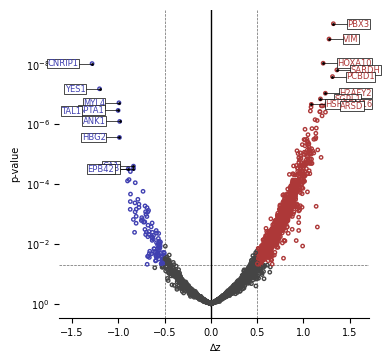

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AACS""",-0.107413,0.730946,-0.108518,0.098199,null,null,null,null,null,null,-2.187392,-2.073608,0.43866,-0.079762,-1.325181,-1.961911,-1.065001,-0.583953,-1.928345,-0.683935,-1.211473,0.370823,-0.839006,0.365272,0.463659,0.505969,-0.287162,-0.331233,-0.901361,-0.029144,-0.428946,-1.042633,-1.214028,-2.885115,0.032918,-0.21025,…,-0.248438,0.691287,-0.506386,-0.462466,1.233208,-2.057326,1.676627,0.712857,1.271996,0.11416,-0.955146,1.308907,0.835865,1.500713,1.340565,1.883544,0.358015,0.446442,-0.488119,-0.111077,-0.158444,0.819224,2.047186,-0.257696,-0.622016,1.478179,1.779024,-0.52664,1.290038,-1.269528,0.651574,-0.061368,-0.864623,1.413702,0.797856,0.000547,0.012455
"""AAK1""",-0.332696,0.781685,-0.136515,-0.175162,null,null,null,null,null,null,-1.674082,-1.990541,-2.018624,-0.879858,-0.519473,-2.287347,-1.408376,-1.325242,-1.286033,-0.239587,-1.013781,-0.512617,-0.857196,1.016665,-0.077221,-1.234556,-0.014465,-0.298716,-0.81734,0.386293,-0.47423,-0.254123,-0.947023,-0.732337,-0.290839,-0.034035,…,0.369875,0.556154,1.321626,-1.298841,-0.484922,-1.300724,1.864569,0.244394,1.443353,0.13413,-1.004998,1.248823,1.263273,0.017723,1.191873,1.818156,0.530937,0.779175,-0.032591,-0.066106,-1.04727,0.446646,2.327782,-1.131889,-0.584383,1.314387,2.454654,-0.184774,0.963997,0.028468,0.920841,-0.218785,-0.533206,2.1839,0.836646,0.000534,0.012321
"""AAMDC""",-0.385034,-0.837509,0.493258,-0.25352,null,null,null,null,null,null,-1.122337,-1.921885,-1.395779,-0.232084,-1.203492,-1.63322,-1.401486,-0.549259,-1.65202,0.09676,-1.720916,-0.251103,-0.544584,0.394631,0.306159,0.382581,-1.567633,-0.786628,-0.333571,-0.472214,0.144274,-0.176564,-0.864149,-2.351714,0.584195,-0.744265,…,-0.933327,0.371614,-0.118944,-0.966589,0.868436,-1.671357,2.150608,1.542161,0.624977,-1.767124,-0.845061,1.155173,2.351253,1.251389,1.574729,0.536111,1.150514,1.052548,-0.830154,0.220702,0.361221,1.397129,1.404438,-0.236203,0.356148,1.666564,0.823133,0.34951,1.395294,0.305307,0.807568,0.879788,-0.456184,1.534897,1.060631,0.000006,0.001039
"""AAMP""",-0.701393,-1.063696,0.84669,-0.735786,null,null,null,null,null,null,-2.190681,-2.090406,0.685153,-1.216563,-0.975753,-1.836804,-1.238513,-0.413762,-1.639129,0.605351,-0.794839,-0.53373,-0.284882,0.863878,-0.956754,-0.687484,-0.104482,-0.097622,-0.543936,0.446243,-0.081576,0.765689,-0.257078,-1.638831,0.208001,-0.524821,…,0.06141,0.368272,0.41309,-1.817129,-0.06138,-1.367784,1.538506,1.198096,0.287547,-1.370788,-1.017859,1.067413,1.425596,1.722362,0.65984,1.479259,0.475476,0.815221,-1.122063,-1.446001,-1.186239,1.141431,1.666419,-1.274499,0.622324,1.589905,1.709812,-0.342871,1.121484,-0.980093,0.212072,0.081658,0.169273,1.82014,0.616427,0.013,0.064148
"""ABCB8""",-1.386142,0.033738,-0.061242,-0.932381,null,null,null,null,null,null,-2.279978,-0.981529,-2.019096,-1.465933,-1.254978,-0.982277,-0.993211,-1.349175,-1.18787,-0.917418,-0.136464,-0.332618,0.15786,0.205558,-0.480415,-0.131156,-0.372219,0.597687,-0.522007,0.281652,0.629024,0.

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",-0.886228,0.02076,-0.410241,-0.937187,null,null,null,null,null,null,-1.756634,-0.259381,0.206942,0.964298,-0.337306,-1.964075,1.396311,-0.884372,1.609296,-0.314472,-0.384432,-0.109955,-0.823375,-0.254598,0.883562,-0.869965,-0.836376,0.797646,-1.052955,0.163821,0.059034,1.145253,2.075651,0.672312,0.399958,0.346064,…,-0.532878,-0.120693,0.729194,-1.590816,1.845735,0.306713,0.45683,-0.599281,-1.551169,null,-0.694857,0.137997,-0.176325,-0.460118,2.250746,null,-0.110098,-0.470254,-1.483994,-0.777031,-1.336906,-0.021864,0.246855,-1.886568,null,0.156595,null,null,null,-1.484408,0.263928,null,-1.450189,-0.760159,-0.614303,0.014497,0.068031
"""ADD2""",-1.068354,0.025603,-1.253329,-0.459002,null,null,null,null,null,null,-2.931369,-0.845818,2.443678,-1.128306,0.118627,-0.435855,-0.405848,-0.160018,-0.554487,-1.061262,0.579887,0.042925,-0.546687,0.626753,1.749628,-0.811933,-0.417729,0.536213,0.951903,-0.178858,1.269711,2.143884,-1.124774,-0.115217,-0.643293,1.712219,…,0.080837,1.247951,-0.554715,0.843017,0.140431,-1.975087,0.157626,-0.51335,-0.835444,-1.704402,-0.948076,0.584706,0.52383,-0.494786,-0.190623,0.451002,-1.514318,-0.075744,-0.97493,-1.027031,-1.203329,-0.476898,0.582588,-2.178091,-0.837423,0.168936,0.581932,-0.196117,0.421304,-0.642886,-0.828711,-0.132909,-1.230997,-0.636448,-0.673003,0.000762,0.014832
"""AHSP""",-0.799563,-0.675042,-0.96797,0.810387,null,null,null,null,null,null,-0.21674,-1.134496,-0.419186,-1.139131,-0.983161,0.242981,0.429378,-0.838539,null,-0.957464,0.512451,0.164474,-0.276714,-0.609881,1.259007,-0.818909,-0.709231,-0.063135,1.929148,-0.265051,1.266079,2.171304,-0.617662,-1.458451,0.26238,2.125349,…,0.052691,0.877975,-0.689773,0.513231,0.484783,null,0.08872,null,-0.856667,-0.715763,-1.375793,-0.229389,null,-0.417669,0.28502,0.061312,-1.520772,0.545057,-0.535336,-1.233649,-0.810104,-0.861923,-0.170801,-1.666084,-0.354253,0.28097,-0.18942,0.020696,1.09606,0.325795,-0.864148,-0.958961,-1.360462,-1.212808,-0.689499,0.000615,0.013069
"""ALOX12""",null,2.474051,null,null,null,null,null,null,null,null,0.473012,0.457255,0.342926,1.404899,0.280009,0.469848,0.074253,-1.425542,-0.550305,1.588509,0.157949,1.566083,1.457994,-0.88663,-0.835871,-0.744936,-0.707053,0.095492,-2.46279,-0.113583,0.262416,-0.874837,1.111249,0.151871,1.979857,0.21152,…,-0.341027,0.117975,-0.756927,-0.42085,0.259301,-0.876818,0.32705,-0.451853,-0.474052,null,null,null,null,null,null,0.555923,-0.289687,null,null,-1.290582,-1.183565,-0.835527,0.001786,-1.426134,null,null,null,null,null,-1.935371,-0.885631,null,-0.608419,-0.716738,-0.806651,0.0012,0.018281
"""ALOX15""",-0.481523,-0.657325,null,0.442763,null,null,null,null,null,null,-1.091178,0.391145,-0.70664,0.315841,-0.459841,0.159503,-0.735261,0.924086,-1.440737,-0.29848,1.314812,0.908617,0.222216,-0.962961,-0.915767,0.727202,0.298035,1.205846,-0.995989,0.925427,-0.161731,1.098902,-0.92873,-0.9191,0.261982,2.254458,…,0.6564,0.466455,0.063442,-0.593382,-0.285037,-0.818153,null,-0.57976,-1.4

Phosphoproteomics


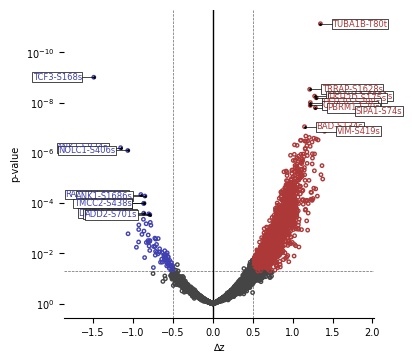

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S637s""",0.057783,-0.029216,0.194366,-2.233178,null,null,null,null,null,null,-1.998365,-1.111933,-2.207443,-0.145771,-1.248242,-0.344854,null,-0.679157,-0.856688,-1.198414,-1.731394,-0.391745,-0.801104,0.202834,-1.092838,-1.283352,0.424226,-0.626962,-0.794601,-0.369344,-0.24715,-0.073995,-1.108927,0.356276,0.294835,-0.236335,…,0.416937,0.3403,-0.388393,-0.951536,-0.771352,-1.062039,2.587249,0.764467,1.386735,0.132379,-0.349264,0.773963,1.371137,0.398149,-0.417062,1.111407,0.007474,-0.151678,1.017491,-0.340462,-0.527011,0.702743,2.123178,-1.702509,0.365806,1.480595,1.767039,-1.091934,-1.038118,0.604405,1.560596,0.457293,-0.327955,1.134126,0.711917,0.002731,0.021994
"""AAK1-S678s""",-0.536243,null,0.094542,null,null,null,null,null,null,null,-1.587837,-1.503012,null,null,0.025082,-2.097395,-1.832501,-0.589332,-0.485079,-0.437184,null,-0.513692,-1.073455,0.414482,null,null,0.576909,-0.876695,-0.685076,0.336448,null,-0.667655,-1.526145,-0.332869,-0.293414,0.504602,…,0.862768,0.266813,1.109725,-1.944122,-2.690322,null,1.110529,0.253737,null,0.677382,null,null,1.005565,-0.574949,0.939261,1.922173,0.633321,1.353143,0.238709,null,-0.15662,0.915234,2.009903,null,-1.736319,0.83902,1.691136,0.264639,0.886569,0.507572,0.066983,-0.571306,-0.117928,1.684154,0.868013,0.000407,0.007126
"""AAK1-T620t""",-0.059986,0.554879,0.952205,0.168947,null,null,null,null,null,null,-0.910864,-1.088085,-3.124641,0.157782,0.26606,-1.844049,-1.903136,-0.442414,-1.001517,0.361512,-0.850922,-0.134226,-1.003601,0.334054,-0.312461,-0.709581,0.350063,-0.572196,-0.705711,0.407857,-0.603296,-0.232845,-1.306885,-1.19817,0.028601,-0.1829,…,-0.331662,0.987607,0.242526,-1.117933,-0.375283,-1.338014,1.552704,0.763903,0.856237,-0.935613,-1.416261,null,0.753045,-0.69183,1.488386,2.066327,0.908633,0.813108,2.142913,-0.898333,-1.22495,null,1.97415,0.065751,0.070103,0.770151,0.7171,-0.177739,1.536282,-0.373522,null,1.120169,-0.095625,1.786547,0.75166,0.003406,0.024969
"""AAK1-T620tS624s""",-2.410728,0.326486,0.543537,0.1266,null,null,null,null,null,null,-1.613861,-1.407616,-2.27731,-0.486357,-0.558593,-2.339913,0.392994,-0.774311,-0.215788,-0.340087,-1.102491,-0.072988,-0.700095,0.564633,-1.035136,-1.099904,-0.053001,-0.910078,-1.13567,0.107707,-0.212891,0.02331,-1.469111,-0.054754,0.464843,0.404726,…,0.471591,0.739436,1.276053,-1.438929,-1.169695,-1.078507,1.409122,0.747445,null,-0.094095,-0.903774,0.732371,1.280336,-0.735551,0.743941,2.117085,0.336333,0.645852,0.618056,null,-1.082235,0.762354,2.046571,-1.277858,-0.1117,1.009286,1.53654,-0.650844,1.095322,-0.157945,1.34049,0.086353,-0.64738,1.851745,0.683729,0.004097,0.027941
"""ABCA2-S1358sS1362s""",-2.29594,-0.529222,-0.284533,-0.768052,null,null,null,null,null,null,-1.679921,-1.622112,-2.241613,-0.589678,-1.417306,-2.126317,-0.541472,-1.574311,0.568072,-0.160236,-1.443663,-0.71549,-0.909166,-0.52222,-0.584014,-0.7271,-0.800116,-0.492611,-0.365467,-0.234929,0.355793,0.528158,1.127105,1.39493,0.220915,-0.897395,…,-0.010534,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCC4-T646t""",null,0.688636,-0.223845,0.398382,null,null,null,null,null,null,-1.502572,-0.343718,-2.585398,-0.137855,-0.463444,-1.048494,-0.613609,-1.162158,-0.828381,-0.668409,-0.153595,-0.111323,0.378102,-0.471775,-0.146535,0.211912,0.467466,0.00944,-1.33499,0.819498,0.920103,1.132548,-0.929693,0.529445,0.969863,0.067459,…,1.307875,1.060577,0.537522,-1.075278,-0.558997,-0.193805,0.379613,0.168131,-0.048961,-2.302973,-1.703337,0.645574,null,-0.985406,0.359986,0.578567,0.02347,0.668131,-0.855454,-1.655188,-1.774521,-0.310527,1.004898,-2.719575,-0.18924,0.568257,1.334065,-1.381905,1.54662,-2.404039,-1.182746,0.531083,-1.172094,0.528249,-0.545016,0.039234,0.118652
"""ADD2-S592s""",null,null,-0.822194,0.475368,null,null,null,null,null,null,null,-0.303886,0.45327,-0.748986,-0.302399,-0.889913,-0.374234,null,0.422618,-0.615898,1.066026,0.751033,-0.224679,-0.732961,1.424765,-0.339735,-0.445051,-0.937431,0.940371,0.028815,1.999799,2.573625,-0.354159,-0.702068,-0.64933,2.224076,…,-0.685272,-0.337508,0.528872,-0.759955,1.241981,-1.732943,-0.212569,null,-1.066911,-1.426203,-1.19333,-0.765589,null,null,-0.459405,0.830097,-1.13049,-0.614798,null,-1.885317,-1.759794,null,null,null,-0.860525,0.544,-0.108983,-0.812039,0.028396,null,null,2.004225,-1.499756,0.002928,-0.716898,0.008215,0.043507
"""ADD2-S701s""",null,-1.076641,-1.091946,-0.447226,null,null,null,null,null,null,-1.733799,-0.891178,1.340985,-0.641293,0.587294,0.227055,0.300827,-0.28358,-0.27497,-1.567536,1.055699,0.063931,-0.058741,0.996232,1.481374,-0.77977,-0.43617,0.909325,0.757766,0.056596,1.453816,2.135587,-0.481272,-0.749023,-0.626991,2.244478,…,0.001608,1.032991,-0.89246,0.086841,-0.478771,-1.96484,-0.084246,-0.201699,-1.172122,-3.214507,-2.479764,null,-0.691306,-1.327868,-0.732697,-0.251526,-0.521819,-0.135623,-0.675462,-1.217919,0.132074,-0.437452,0.196279,-1.308828,-0.451128,0.210953,0.246766,0.021184,0.394804,-0.223773,0.007328,0.225618,-1.205182,-0.090324,-0.789311,0.000284,0.005765
"""ANK1-S1686s""",-0.46324,0.141924,0.549669,-0.425941,null,null,null,null,null,null,-1.680997,-0.664159,1.498352,-1.280027,0.310414,0.142096,-0.323998,-0.943051,-0.441329,-1.033922,0.149797,0.127926,-0.531524,-0.723159,0.38654,-1.063011,-0.442197,-0.003392,0.149398,-0.105017,1.567542,2.452476,-0.341724,-1.124584,0.394191,1.787558,…,-0.459197,1.501666,-0.656582,-0.838266,0.337688,-0.516397,-0.162866,-0.074096,-0.697196,-1.94131,-1.330298,0.052366,0.565731,-1.230135,0.310041,0.279852,-1.474455,-0.212913,-0.532954,-2.366663,-1.741374,-0.358293,-0.898956,-2.155324,-0.648054,0.463383,-0.018593,-0.201709,0.038631,-0.329824,-0.589441,0.198857,-1.268896,-0.327166,-0.850881,0.000052,0.002256
"""ANK1-S834s""",-1.421018,0.241652,-0.607344,-0.018826,null,null,null,null,null,null,-1.287582,-0.300076,2.693779,-0.449767,1.520645,0.176589,0.608946,0.300057,-0.562979,-0.451376,0.691024,0.487473,0.308063,-0.020505,0.362029,0.245003,-0.264015,1.213562,1.05224,0.623489,1.296518,1.302594,-1.06051,-0.278154,0.20671

Acetylomics


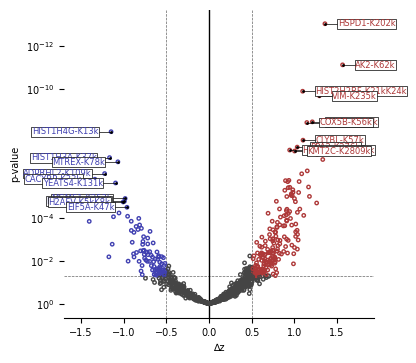

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADM-K304k""",null,-0.756377,-0.823619,-0.18177,null,null,null,null,null,null,null,0.550084,0.26972,0.090233,-0.542478,0.342554,-0.05779,-1.258832,-0.657214,-0.489785,1.543162,-1.138952,0.894571,1.2726,0.717477,0.601857,null,0.114841,null,-0.07626,0.179444,0.248184,0.183552,-0.879208,-0.12271,-0.533859,…,null,-1.554882,0.597203,-1.226182,0.138878,0.163076,0.093064,0.570111,0.549327,null,2.065314,0.260801,-1.137819,0.63613,1.8208,null,1.466254,1.037132,1.282869,null,null,-2.128101,0.557885,null,2.52989,0.121428,0.425848,-0.477631,1.222963,-0.674465,-0.366378,-0.019168,0.867195,0.091427,0.669248,0.011822,0.055267
"""ACADVL-K278k""",null,null,-0.710599,-1.588527,null,null,null,null,null,null,0.203138,0.083272,0.131454,1.247322,-0.23759,-2.052617,-1.034748,-1.193342,0.397733,-1.123075,0.01339,0.301426,0.540577,0.378273,0.156019,0.788575,-0.360567,-0.553319,0.232543,-0.166009,-0.067446,-0.85659,0.340465,1.081246,-0.669417,-1.60396,…,-1.074212,-0.246902,1.452416,-2.502125,1.232508,0.537549,1.207043,0.558709,1.944598,null,0.913211,1.623405,0.846593,-0.85811,0.062644,-0.684428,0.816853,null,0.902504,1.120202,0.712168,1.754261,0.67529,null,2.206311,0.250994,0.853731,0.040041,1.343848,0.040041,1.060722,-0.70703,0.095953,0.661879,0.974505,0.000009,0.000259
"""ACAT1-K202k""",null,-1.118936,-0.365658,-1.782138,null,null,null,null,null,null,0.115357,0.044941,-0.180242,0.024219,-0.775193,-1.208166,-1.159883,-1.027327,-0.796064,-0.845549,1.244129,-2.125251,0.597767,-0.55304,0.594193,0.361942,-1.396269,-0.510517,-0.136813,-1.123089,0.48445,0.922285,-1.408375,-0.559716,0.309774,-1.215652,…,0.979978,0.03679,1.432393,-1.87295,1.43793,null,1.309175,-0.990255,0.496604,-0.920966,0.19163,1.1409,1.494277,2.117885,1.484379,0.4648,0.19361,-0.225099,null,-1.316907,-0.050884,1.370546,0.142137,-0.574517,1.959509,-0.584415,1.394302,-0.901169,0.231224,1.416079,-0.163728,0.273788,0.425433,1.434669,0.628051,0.007093,0.038556
"""ACLY-K538k""",null,-0.507195,0.54113,null,null,null,null,null,null,null,-2.349713,null,1.718744,-2.152749,null,null,null,-0.33006,1.763454,null,-0.037321,0.564996,null,0.964732,-0.369031,0.302639,-0.593542,-0.404523,0.417904,-0.640174,-1.41437,0.089029,0.546944,-0.119491,-1.538116,0.068259,…,-0.920758,-0.1753,null,-2.060898,1.844405,-0.378435,1.799409,1.669986,-0.439608,0.000537,1.03869,0.0032,1.468661,1.799409,0.807166,null,-0.072047,-0.512947,-1.398775,0.650421,null,1.741887,0.608718,0.427526,0.567015,-0.330317,0.387261,null,0.295227,null,1.366561,-1.053648,null,0.297867,0.701656,0.004242,0.02793
"""AFF1-K582k""",0.35102,null,1.35622,1.278734,null,null,null,null,null,null,-1.297054,-0.673857,null,-0.316947,0.555662,-0.254221,-1.243389,0.573081,-0.450536,0.076041,-0.845099,-0.306201,-0.461968,0.653689,-1.704414,-0.943417,0.51793,-0.293414,-0.428546,0.012903,0.385031,-0.146849,0.453077,-0.013539,1.314766,-2.192885,…,0.154605,-0.044861,1.063843,-0.925694,-3.123361,1.853603,1.3127,-0.713621,0.496334,null,0.369065,0.629971,0.686441,-0.229597,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACTR2-K336k""",null,null,-0.019484,null,null,null,null,null,null,null,-2.25362,null,0.088769,1.142567,null,null,null,0.246171,-0.743779,null,0.972099,0.018548,null,-0.138255,1.967605,0.038548,0.622616,1.04312,0.727075,-2.128899,-0.455326,-0.166795,null,-1.175493,0.605465,0.132869,…,0.135966,1.581251,null,-0.004113,0.00217,-1.695801,-0.588939,-0.344482,null,1.689116,null,null,null,-1.055414,0.170413,null,-0.697586,0.52706,-1.452214,null,-0.885357,-0.322044,0.012165,null,-1.139262,null,-0.784977,-0.871186,0.156241,-2.585927,-1.138081,-0.690501,0.35346,1.508811,-0.573031,0.034811,0.117079
"""ADPRHL2-K109k""",null,-0.999534,-0.403112,-0.581537,null,null,null,null,null,null,null,null,0.211249,1.858198,null,null,0.549917,-0.983199,1.413049,0.477341,1.479093,null,0.972418,0.616245,1.305568,1.638691,null,0.086342,null,null,0.104363,0.303065,null,1.816497,0.416421,null,…,null,null,0.439263,0.521825,-0.571221,1.244026,null,-0.389078,-1.059677,-2.007938,-1.182971,-0.610606,-1.640061,-1.473664,0.42787,-1.595956,-1.28321,null,0.658419,-1.637054,null,-0.329937,null,-2.128225,0.528109,-0.254758,-0.451226,-0.678568,0.1051,null,-0.860202,-0.759471,null,-0.741868,-1.223441,8.8359e-7,0.000047
"""AFF4-K759k""",0.633827,1.138367,-0.001573,-0.475578,null,null,null,null,null,null,null,null,-0.486995,0.783659,0.30186,null,1.185808,1.901199,-0.511182,-0.094917,-0.048133,0.41179,-1.329949,null,-0.772292,0.919315,null,0.117552,null,null,1.592637,-0.143292,null,0.437951,0.324375,null,…,null,null,0.905518,null,null,0.82668,-1.163322,-1.452669,-0.791097,null,null,0.231068,0.507329,-1.448307,0.287774,0.940622,null,0.007151,0.446261,null,null,-2.647861,-0.561364,-0.987388,null,-1.286913,null,null,null,1.801393,-1.074628,null,-0.417127,0.048836,-0.609019,0.044481,0.131866
"""ALDH4A1-K402k""",null,0.297978,-1.475892,0.513119,null,null,null,null,null,null,0.819059,0.98603,-1.351276,-0.003802,-0.974632,1.24811,0.550543,-0.432976,0.399823,-0.795906,1.426717,-1.613974,1.431246,0.633501,1.532965,1.210059,-0.762615,0.200719,0.482378,-0.690754,-2.25906,0.748501,0.711012,0.576211,0.110136,-0.92873,…,-0.067706,-0.629208,-1.159107,1.738295,-1.068239,-0.69245,null,null,null,null,-0.041058,null,null,-1.166155,-0.211832,null,-0.881532,-0.779403,0.769279,null,null,-0.565936,null,-1.316838,null,-0.806191,null,null,null,null,-0.057801,null,null,0.025675,-0.536057,0.027598,0.103216
"""ANXA11-K408k""",0.272792,0.48053,null,-0.140393,null,null,null,null,null,null,0.285922,-0.50601,null,1.059728,-0.094525,0.070597,-1.716595,null,null,-0.672417,1.293812,null,-0.44856,null,null,0.182472,0.679156,null,-1.396011,-0.08424,0.195638,null,0.760676,null,null,2.469248,…,1.593697,0.131247,-1.1746,null,null,0.586433,-1.469346,null,-1.005158,null,-1.230088,null,0.35732,-0.113602,null,-1.780237,-1.083955,0.09514,-0.989398,0.457607,null,null,-0.689968,null,-0.871919,-1.295992,-0.289965,0.102303,-0.057871,-1.486538,null,-0.834669,0.172504,null,-0.911698,0.000146,0.002092
…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Lipidomics


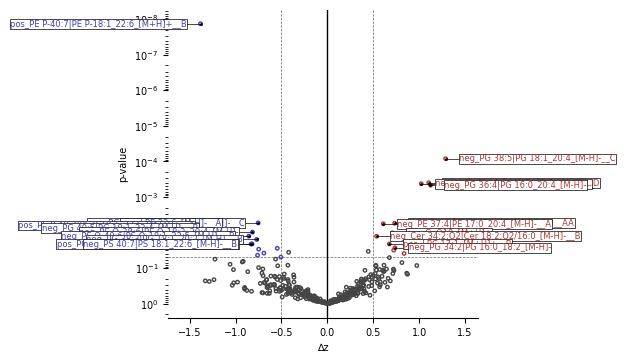

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-1.037572,null,-0.10641,null,-1.478111,-1.723787,-0.669397,-1.451667,-0.240233,-0.184965,-0.467517,0.992755,0.379675,1.571506,0.280969,-0.611682,-0.872715,-1.256183,-1.670102,-0.498008,-0.810446,-0.721304,0.443887,-0.002318,1.687509,0.463646,-0.726519,-0.401038,-0.499378,-0.872466,1.772737,-0.168452,-0.930991,-0.289725,-0.586031,0.307673,…,0.432897,0.164303,0.404734,-0.08459,2.20315,null,0.514814,null,null,null,null,0.969563,0.35411,1.023783,1.528552,null,null,null,null,null,1.518245,null,null,null,null,null,0.583884,null,null,null,null,null,null,null,1.023049,0.000422,0.031851
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.315454,null,0.261801,null,-1.914425,-2.394101,-0.654117,-0.537232,-0.889837,0.809516,-1.54991,1.012642,-0.080243,2.247978,0.212452,-1.909556,0.029038,0.475881,-0.188169,0.815347,-1.59219,-0.553636,-0.438992,-0.116277,-1.043171,-0.01339,-0.301491,0.541094,-0.067304,0.427984,0.809705,1.084738,-1.087194,0.611548,0.877134,-1.896248,…,-0.90592,-0.783793,0.374877,-0.603606,0.997037,null,0.403643,null,null,null,null,1.704115,0.90973,0.929457,1.767115,null,null,null,null,null,0.679593,null,null,null,null,null,0.738481,null,null,null,null,null,null,null,1.123761,0.000466,0.031851
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.203347,null,0.813564,null,-2.443351,-1.96463,-0.908046,-0.472882,-0.880416,0.294197,-0.09481,0.813068,-0.822486,1.156611,-0.380085,-1.143014,-0.895902,-0.806606,-0.477915,-0.282475,-1.115334,-1.285611,0.050232,-0.081029,1.352579,0.414778,-0.529188,-0.960553,-0.846172,-0.541037,0.815582,0.251863,-0.402625,-0.338631,0.020172,0.035773,…,-0.022172,-1.469467,0.449796,0.009185,2.18848,null,0.219323,null,null,null,null,1.16848,0.891457,1.273352,1.438848,null,null,null,null,null,1.675126,null,null,null,null,null,1.511489,null,null,null,null,null,null,null,1.288562,0.000084,0.014337
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.824139,null,0.295324,null,-2.307315,-2.774504,-0.86661,0.227695,-0.652292,-0.072242,-0.702863,-0.446564,0.341678,1.158962,1.006821,0.576475,0.939116,-0.772109,1.133846,0.285895,0.173843,0.009977,0.215273,1.556977,-0.721598,0.109335,-0.912765,-0.762424,-1.050754,-0.567621,0.766191,1.112632,-0.519617,-0.448186,-0.73003,-0.729626,…,-0.157535,-0.046345,0.90982,0.150831,2.691561,null,1.430602,null,null,null,null,1.073325,0.183753,-0.574366,0.916445,null,null,null,null,null,0.76594,null,null,null,null,null,0.875583,null,null,null,null,null,null,null,0.736021,0.026618,0.449852
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",0.658104,null,0.7099,null,-2.132977,null,-0.377471,-1.056997,-0.323619,0.267671,-0.437797,0.328767,2.785758,0.949968,-0.397879,-0.844291,0.27853,-1.03668,-0.325366,-0.569717,-1.104689,-0.907572,-0.171602,-0.345001,1.281689,0.493762,-0.73741,-0.616048,-0.24608,-0.603269,0.662472,1.295685,-0.270388,-0.465025,0.195324,0.110415,…,-0.185367,-0.712138,0.355281,0.409564,0.991265,null,0.592343,null,null,null,null,1.659319,0.567129,0.375172,1.500962,null,null,null,null,null,1.29847

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__A""",1.284615,null,-0.174817,null,1.241238,1.345768,0.731882,0.919384,1.684093,1.589175,0.862993,1.108171,-0.39864,0.31996,1.17913,1.867889,0.13982,0.487134,-0.31961,0.560198,2.059783,1.780957,0.514971,0.197202,-0.282692,0.604605,0.072514,0.189678,-0.081837,1.670242,1.826759,-1.811645,0.105113,-0.539731,-0.617866,-0.034561,…,0.464773,-1.152457,0.132914,-0.477811,-1.508632,null,-0.389114,null,null,null,null,-1.33914,0.343823,-1.447457,-1.079684,null,null,null,null,null,-1.396361,null,null,null,null,null,-1.068444,null,null,null,null,null,null,null,-1.004681,0.005393,0.215087
"""neg_LPE 22:6_[M-H]-__B""",0.827447,null,0.029833,null,1.665482,2.827724,1.155641,0.874739,1.449233,0.551556,0.13783,0.590832,-0.165396,0.640018,0.525104,2.058335,-0.1901,0.114987,-0.013016,0.220702,1.701778,1.508942,0.189164,0.385653,0.279924,1.611008,-0.457121,0.177418,-0.362864,0.954225,1.319974,-1.073142,-0.140485,-0.839512,-0.564568,0.128872,…,0.461877,-0.942819,-0.033875,-0.780364,-0.813693,null,-0.264832,null,null,null,null,-1.324654,0.824524,-1.50812,-0.762867,null,null,null,null,null,-0.941334,null,null,null,null,null,-0.847192,null,null,null,null,null,null,null,-0.760159,0.043374,0.511511
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.348208,null,-2.092059,null,-0.339439,0.309855,-0.676786,0.023688,-0.959151,-1.733722,-0.41867,1.310827,-2.60246,1.118717,0.853891,0.243363,-0.580149,-0.676283,0.263989,0.322203,-0.083092,0.157828,1.527101,-0.316726,1.351167,0.791221,-0.21387,0.117736,0.574157,-1.128994,-1.416792,-1.169271,0.220892,0.331317,0.46944,-0.648147,…,0.037697,0.188292,-2.248362,1.001302,-0.467073,null,0.468052,null,null,null,null,-0.171187,-1.519141,-1.123198,-1.271726,null,null,null,null,null,-0.624159,null,null,null,null,null,-0.505337,null,null,null,null,null,null,null,-0.747904,0.029302,0.455506
"""neg_PS 40:7|PS 18:1_22:6_[M-H]…",0.744833,null,-0.678601,null,2.828422,0.949528,-0.313268,-2.279033,1.001111,-0.042242,-1.046726,-0.600146,-0.970494,-0.474828,0.887875,-0.918299,-0.969339,-0.346763,-0.933169,-0.316434,-0.531046,-0.886907,0.320987,-0.023467,0.033829,-0.203491,1.039627,0.023213,-0.064974,0.152567,0.783231,-0.230518,0.319807,1.115141,0.877343,-1.487667,…,1.544152,1.224293,0.937272,-0.243787,-0.899826,null,0.546038,null,null,null,null,-0.521051,-1.449849,-1.196093,-0.267538,null,null,null,null,null,-1.169131,null,null,null,null,null,-1.220511,null,null,null,null,null,null,null,-0.831639,0.021054,0.378974
"""neg_PG 40:5|PG 18:1_22:4_[M-H]…",0.219156,null,-1.2074,null,-1.090948,-0.38037,-0.936361,0.228002,-2.371669,-1.486104,-0.087523,1.347286,-2.115188,0.59241,-0.544453,-0.045477,0.662503,-0.357817,1.001759,0.094593,0.064929,-0.659506,0.479321,-0.056871,0.249658,1.397253,0.426258,0.126618,0.44902,0.036908,-2.432377,-0.043085,0.372864,0.593977,0.837586,0.13682,…,0.942899,0.715233,-1.607965,0.686188,-1.110022,null,-1.672298,null,null,null,null,null,-1.493734,-0.188631,-2.126131,null,null,null,null,null,-1.029297,null,null,

Metabolomics


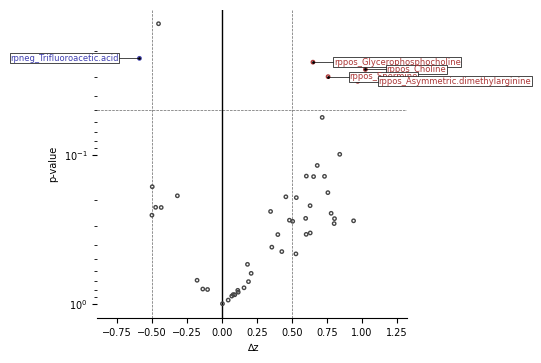

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Glycerophosphocholine""",0.84987,null,0.908219,null,-2.004115,0.034037,-1.795248,-1.175204,-0.42858,-0.327055,-0.465695,-0.468944,1.312,-1.126372,-0.902187,-0.540505,-1.006228,-0.537035,-0.019352,-0.967415,-0.79747,-2.181314,0.598842,-2.072995,-0.042774,-1.584109,1.679257,-0.960928,0.451583,-0.979408,-0.80545,0.701168,-1.723047,1.226405,-0.295427,-0.698456,…,-0.225895,1.382269,1.706642,-0.613303,0.847879,null,-0.273339,null,null,null,null,0.783383,0.709722,0.810099,0.008706,null,null,null,null,null,1.445044,null,null,null,null,null,0.648862,null,null,null,null,null,null,null,0.651126,0.02384,0.261688
"""rppos_Spermine""",-0.894872,null,-1.448238,null,-1.306641,-1.446576,-1.350582,-0.968279,-0.900496,-1.557281,-1.6048,-1.389567,-1.495236,-0.519648,-1.548402,0.010712,-0.403571,-0.455947,-1.41417,-0.228245,0.161565,0.47864,-1.391948,1.195745,0.126566,0.891256,-1.46897,0.784742,-0.614995,0.395945,0.294051,-1.503674,-0.372641,-1.700032,0.461033,0.356801,…,0.87422,0.537185,1.192316,1.259799,1.67552,null,0.746664,null,null,null,null,0.291114,-0.509449,0.913305,0.431046,null,null,null,null,null,1.605707,null,null,null,null,null,1.342106,null,null,null,null,null,null,null,0.759531,0.029816,0.261688
"""rppos_Choline""",0.32822,null,-0.521423,null,-2.642852,-1.144459,-1.710926,0.003845,-1.811898,-0.753279,-0.841906,0.015402,0.228518,-0.994282,-0.628629,-0.540821,-1.702691,-0.298212,0.10713,-0.364975,-0.872134,-1.932107,0.510994,-0.939647,0.359411,-1.761399,0.747906,-0.85322,0.447832,-0.228064,-0.991414,0.468921,-1.879192,-0.117545,-0.175688,-1.83818,…,0.271358,1.194782,1.414509,0.476218,2.057246,null,1.252565,null,null,null,null,0.321272,1.377698,0.073239,-0.177787,null,null,null,null,null,2.52997,null,null,null,null,null,1.13919,null,null,null,null,null,null,null,1.026704,0.026698,0.261688
"""rppos_Asymmetric.dimethylargin…",-0.851165,null,2.015834,null,-1.151811,0.254819,-1.540165,-0.571011,-0.576162,0.373574,0.420123,0.561525,1.090328,-0.581724,-0.694734,0.09431,-0.710501,1.226492,0.305564,0.388012,-0.154737,-1.384143,1.537605,-0.867974,-0.453339,-0.920181,1.430864,-0.233043,-0.202876,0.127329,-0.373354,1.228949,-2.109031,1.644567,0.237263,-1.780438,…,-1.177186,-0.364457,1.168075,-1.374552,0.142746,null,0.675417,null,null,null,null,-0.229999,1.032424,0.354443,0.229858,null,null,null,null,null,2.495316,null,null,null,null,null,1.606911,null,null,null,null,null,null,null,0.971277,0.032043,0.261688


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rpneg_Trifluoroacetic.acid""",0.250803,null,0.865171,null,0.604008,1.175613,0.995403,0.729134,0.376485,1.370605,0.496982,0.808585,2.621139,0.177403,0.620974,-0.072115,0.31735,0.85662,0.983464,-0.108575,-0.115013,-0.273954,0.495874,-0.716036,0.012137,-0.287761,1.92737,-0.6503,0.687427,-0.067185,-0.684687,0.459286,1.734646,2.037308,-0.151292,-0.693742,…,0.119942,-0.28546,0.581214,-1.772726,-1.859461,null,-0.065085,null,null,null,null,-0.734286,-0.526643,-1.492812,-0.064392,null,null,null,null,null,-0.240514,null,null,null,null,null,-0.627272,null,null,null,null,null,null,null,-0.59102,0.022467,0.261688


In [21]:
# key: (subset_id, block)
# value: {"up": top_n_up_df, "down": top_n_down_df}
top_up_and_down = {}

for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    print("============", subset_id, "============")
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Acetylomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        if (df := comps.get((subset_id, block))) is not None:
            print(block)
            top_up, top_down = plot_volcano_and_select_top_features(
                df,
                0.5,   # effect size
                0.05,  # adjusted ttest p value
                subset_id,
                block
            )
            display(top_up)
            display(top_down)
            top_up_and_down[(subset_id, block)] = {"up": top_up, "down": top_down}

### Compare counts of selected features between black and white patients

#### NPM1

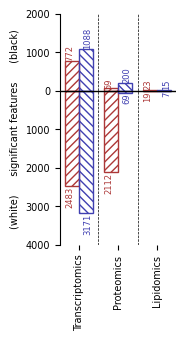

In [22]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITD

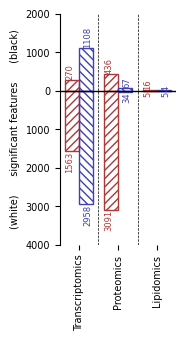

In [23]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITD-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITDxNPM1 vs. WT

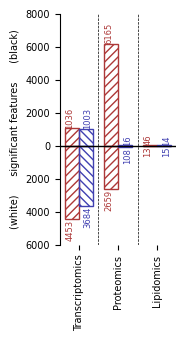

In [24]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITDxNPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


### Combine top up- and down- features into a big table

In [ ]:
# columns:
# population, mutation_comparison, omics_type, feature, delta_z, ttest_p, ttest_p_adj

In [30]:
x = (
    top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["up"]
    .select(
        "Feature",
        "delta_z",
        "ttest_p",
        "ttest_p_adj"
    )
    .with_columns(
        pl.lit("Black").alias("population"),
        pl.lit("FLT3-ITD-WT").alias("mutation_comparison"),
        pl.lit("Transcriptomics").alias("omics_type")
    )
)
x

Feature,delta_z,ttest_p,ttest_p_adj,population,mutation_comparison,omics_type
str,f64,f64,f64,str,str,str
"""WDR54""",1.026044,0.03817,0.446923,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""NFIX""",1.798017,0.010389,0.249084,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""UQCRC1""",0.649468,0.046316,0.479554,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""LRRC23""",0.66845,0.037936,0.44651,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""ERCC1""",0.997191,0.017724,0.316745,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
…,…,…,…,…,…,…
"""ENSG00000270983""",0.549456,0.010641,0.25142,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""ENSG00000271576""",0.807312,0.04196,0.46018,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""
"""ENSG00000272086""",0.799765,0.012993,0.276029,"""Black""","""FLT3-ITD-WT""","""Transcriptomics"""


In [32]:
top_features = pl.concat([
    (
        top_up_and_down[(subset_id, omics_type)][direction]
        .select(
            "Feature",
            "delta_z",
            "ttest_p",
            "ttest_p_adj"
        )
        .with_columns(
            pl.lit({"B": "Black", "W": "White"}[subset_id.split("_", maxsplit=1)[0]]).alias("population"),
            pl.lit(subset_id.split("_", maxsplit=1)[1]).alias("mutation_comparison"),
            pl.lit(omics_type).alias("omics_type")
        )
    )
    for (subset_id, omics_type) in top_up_and_down.keys()
    for direction in ["up", "down"]
])
top_features

Feature,delta_z,ttest_p,ttest_p_adj,population,mutation_comparison,omics_type
str,f64,f64,f64,str,str,str
"""NDUFAF7""",0.699753,0.013672,0.238555,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""CDC27""",1.013618,0.04501,0.402064,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""HCCS""",0.568775,0.039324,0.381109,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""LIG3""",1.470139,0.012205,0.225757,"""Black""","""NPM1-WT""","""Transcriptomics"""
"""CIAPIN1""",0.746133,0.007659,0.180432,"""Black""","""NPM1-WT""","""Transcriptomics"""
…,…,…,…,…,…,…
"""rppos_Glycerophosphocholine""",0.651126,0.02384,0.261688,"""White""","""FLT3-ITDxNPM1-WT""","""Metabolomics"""
"""rppos_Spermine""",0.759531,0.029816,0.261688,"""White""","""FLT3-ITDxNPM1-WT""","""Metabolomics"""
"""rppos_Choline""",1.026704,0.026698,0.261688,"""White""","""FLT3-ITDxNPM1-WT""","""Metabolomics"""


In [43]:
top_features.write_ipc(os.path.join(DIFFEX_DIR, "all_top_features.arrow"))
top_features.write_csv(os.path.join(DIFFEX_DIR, "all_top_features.csv"))

# TODO
Automate uploading/updating the all top features table (apache arrow + csv) to synapse (`syn74782709` and `syn74782710`, respectively). In the meantime, I manually uploaded them.